# Traffic Re:View — Final V5

14 กราฟ / 22 สไลด์ พร้อมคำอธิบายครบสามช่วง ใช้ไฟล์ Excel ชีต `traffic_data` เปลี่ยนไฟล์ได้โดยรันใหม่ ผลแต่ละรอบแยกโฟลเดอร์ ไม่ทับเดิม

ผลปัจจุบันใช้ไฟล์ (5).xlsx ซึ่งผู้ใช้อนุญาตให้วิเคราะห์แล้ว ก่อนนำผลจากไฟล์ใหม่ไปใช้ต้องทบทวน AUDIT และจำนวนคู่ใหม่ ไม่ใช้จำนวนแถวเป็นจำนวนรถ และไม่สรุปเชิงสาเหตุ

โค้ด Pandas/NumPy/Matplotlib อยู่ใน notebook นี้ครบ ไม่ต้องหา traffic_audit.py มาอัปโหลดเพิ่ม

In [1]:
import os, sys, subprocess
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
if "google.colab" in sys.modules:
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "pandas", "numpy", "matplotlib", "openpyxl"])
from pathlib import Path
from datetime import datetime, timezone
import json, base64
from IPython.display import display, Markdown, Image
WORK = Path.cwd() / ("traffic_v5_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ"))
(WORK / "src").mkdir(parents=True)
(WORK / "assets").mkdir()
print("ผลรอบนี้:", WORK)

ผลรอบนี้: C:\Users\AphatsaraKhangkhet(C\OneDrive - buzzebees.com\Documents\CAKE\DADS10\5001\dads5001-bangkok-traffic-mini-project\tmp\traffic_v5_build\notebook_test\traffic_v5_20260919T114629_220425Z


In [2]:
SOURCES = {'audit_core.py': '"""Reproducible feasibility audit. No traffic-volume EDA or charts."""\nfrom pathlib import Path\nimport argparse, datetime, hashlib, json, re, shutil, unicodedata\nimport numpy as np\nimport pandas as pd\n\nROOT = Path(__file__).resolve().parents[1]\nVEHICLES = [\'passenger_car\',\'pickup_van\',\'large_bus\',\'small_bus\',\'truck\',\'tuk_tuk\']\nPERIODS = [\'ก่อนโควิด\',\'โควิด\',\'หลังโควิด\']\nTHAI_MONTHS = [\'ม.ค.\',\'ก.พ.\',\'มี.ค.\',\'เม.ย.\',\'พ.ค.\',\'มิ.ย.\',\'ก.ค.\',\'ส.ค.\',\'ก.ย.\',\'ต.ค.\',\'พ.ย.\',\'ธ.ค.\']\n\ndef normalize(value):\n    if pd.isna(value): return \'\'\n    return re.sub(r\'\\s+\', \' \', unicodedata.normalize(\'NFC\',str(value))).strip()\n\ndef survey_date(value):\n    if pd.isna(value): return pd.NaT\n    if isinstance(value,(datetime.date,datetime.datetime,pd.Timestamp)):\n        return pd.Timestamp(value).normalize()\n    text=normalize(value).translate(str.maketrans(\'๐๑๒๓๔๕๖๗๘๙\',\'0123456789\'))\n    text=re.sub(r\'\\s*/\\s*\',\'/\',text)\n    match=re.search(r\'(\\d{1,2})\\s*([ก-๙.]+)\\s*(\\d{2,4})\',text)\n    if match:\n        day,month,year=match.groups(); year=int(year)\n        if year<100: year+=2500\n        if year>2400: year-=543\n        try: return pd.Timestamp(year=year,month=THAI_MONTHS.index(month)+1,day=int(day))\n        except ValueError: return pd.NaT\n    # This workbook uses explicit day/month/year text (e.g. 29/5/2026).\n    if re.fullmatch(r"\\d{1,2}/\\d{1,2}/\\d{4}",text):\n        return pd.to_datetime(text,format="%d/%m/%Y",errors="coerce")\n    # ISO dates remain supported.\n    if re.fullmatch(r\'\\d{4}-\\d{2}-\\d{2}(?:[ T].*)?\',text):\n        return pd.to_datetime(text,errors=\'coerce\')\n    return pd.NaT\n\ndef time_bounds(value):\n    found=re.findall(r\'(\\d{1,2})[.:](\\d{2})\',normalize(value))\n    if len(found)!=2: return None,None,None\n    values=[int(h)*60+int(m) for h,m in found]\n    if any(int(h)>23 or int(m)>59 for h,m in found) or values[1]<=values[0]:\n        return None,None,None\n    return f\'{values[0]//60:02d}:{values[0]%60:02d}\',f\'{values[1]//60:02d}:{values[1]%60:02d}\',(values[1]-values[0])/60\n\ndef save_csv(frame,path): frame.to_csv(path,index=False,encoding=\'utf-8-sig\')\n\ndef matching(frame,keys):\n    usable=frame.loc[frame.covid_period.isin(PERIODS)].dropna(subset=keys)\n    matrix=usable.groupby(keys+[\'covid_period\'],dropna=False).size().unstack(fill_value=0).reindex(columns=PERIODS,fill_value=0)\n    complete=matrix.loc[matrix.gt(0).all(axis=1)]\n    joined=usable.merge(complete.reset_index()[keys],on=keys,how=\'inner\',validate=\'many_to_one\')\n    return matrix,complete,joined\n\ndef run_audit(source,output=None):\n    source=Path(source).resolve()\n    output=Path(output or ROOT/\'outputs/current_audit\').resolve();output.mkdir(parents=True,exist_ok=True)\n    source_hash=hashlib.sha256(source.read_bytes()).hexdigest()\n    snapshots=ROOT/\'data/raw\';snapshots.mkdir(parents=True,exist_ok=True)\n    snapshot=snapshots/f\'traffic_{source_hash[:12]}.xlsx\'\n    if not snapshot.exists(): shutil.copyfile(source,snapshot)\n    assert hashlib.sha256(snapshot.read_bytes()).hexdigest()==source_hash\n    raw=pd.read_excel(snapshot,sheet_name=\'traffic_data\')\n    if raw.empty: raise ValueError(\'traffic_data is empty\')\n    if \'id\' not in raw: raw.insert(0,\'id\',np.arange(1,len(raw)+1))\n    required=[\'id\',\'survey_date\',\'Date\',\'month\',\'year\',\'covid_period\',\'intersection\',\'road\',\'time_period\']+VEHICLES\n    missing=set(required)-set(raw.columns)\n    if missing: raise ValueError(f\'Missing required columns: {sorted(missing)}\')\n    d=raw.copy();d.insert(0,\'source_excel_row\',np.arange(2,len(d)+2))\n    d[\'source_sha256\']=source_hash;d[\'source_sheet\']=\'traffic_data\'\n    d[\'intersection_key\']=d.intersection.map(normalize);d[\'road_key\']=d.road.map(normalize)\n    # Keep the supplied covid_period, including unexpected labels for the audit.\n    d[\'report_day\']=pd.to_numeric(d.Date,errors=\'coerce\')\n    d[\'report_month\']=pd.to_numeric(d.month,errors=\'coerce\')\n    d[\'report_year\']=pd.to_numeric(d.year,errors=\'coerce\')\n    d[\'report_date\']=pd.to_datetime(dict(year=d.report_year,month=d.report_month,day=d.report_day),errors=\'coerce\')\n    d[\'survey_date_parsed\']=d.survey_date.map(survey_date)\n    d[\'survey_month\']=d.survey_date_parsed.dt.month\n    d[\'survey_year\']=d.survey_date_parsed.dt.year\n    d[\'report_quarter\']=((d.report_month-1)//3+1).where(d.report_month.between(1,12))\n    bounds=d.time_period.map(time_bounds)\n    d[[\'start_time\',\'end_time\',\'period_hours\']]=pd.DataFrame(bounds.tolist(),index=d.index)\n    d[\'time_key\']=d.start_time.fillna(\'\')+\'-\'+d.end_time.fillna(\'\')\n    changes=[];numeric_profile=[]\n    for col in VEHICLES:\n        text=d[col].map(normalize)\n        zero=d[col].isna() | text.isin([\'\',\'-\'])\n        cleaned=pd.to_numeric(text.str.replace(\',\',\'\',regex=False).mask(zero,\'0\'),errors=\'coerce\')\n        d[col+\'_clean\']=cleaned;d[col+\'_zero_assumed\']=zero\n        for row in d.index[zero]: changes.append({\'source_excel_row\':int(d.at[row,\'source_excel_row\']),\'field\':col,\'original_value\':d.at[row,col],\'replacement\':0,\'reason\':\'user_rule_missing_or_dash_is_zero\'})\n        numeric_profile.append(dict(field=col,blank=int((d[col].isna()|text.eq(\'\')).sum()),dash=int(text.eq(\'-\').sum()),zero_assumed=int(zero.sum()),unresolved=int(cleaned.isna().sum()),negative=int(cleaned.lt(0).sum()),fractional=int((cleaned.notna()&cleaned.mod(1).ne(0)).sum())))\n    numeric=d[[c+\'_clean\' for c in VEHICLES]]\n    d[\'has_assumed_zero\']=d[[c+\'_zero_assumed\' for c in VEHICLES]].any(axis=1)\n    d[\'numeric_unresolved\']=numeric.isna().any(axis=1)\n    d[\'numeric_negative\']=numeric.lt(0).any(axis=1)\n    d[\'numeric_fractional\']=(numeric.notna()&numeric.mod(1).ne(0)).any(axis=1)\n    d[\'exact_repeat\']=raw.drop(columns=\'id\').duplicated(keep=\'first\')\n    # Repeated survey observations can appear in different reports: audit, do not silently delete.\n    survey_key=[\'survey_date_parsed\',\'intersection_key\',\'road_key\',\'time_key\']\n    d[\'repeated_survey_key\']=d.survey_date_parsed.notna() & d.duplicated(survey_key,keep=False)\n    report_key=[\'report_year\',\'report_month\',\'report_day\',\'intersection_key\',\'road_key\',\'time_key\']\n    d[\'repeated_report_key\']=d.duplicated(report_key,keep=False)\n    # Distinct report and survey dates are legitimate; neither equality nor a valid report day\n    # is needed to match by report month. Day validity is retained as a separate finding.\n    d[\'candidate_eligible\']=(d.covid_period.isin(PERIODS)&d.report_month.between(1,12)&d.report_year.ge(2017)&d.period_hours.notna()&d.intersection_key.ne(\'\')&d.road_key.ne(\'\')&~d.numeric_unresolved&~d.numeric_negative&~d.numeric_fractional&~d.exact_repeat&~d.repeated_survey_key)\n    candidate=d.loc[d.candidate_eligible].copy()\n    matrices={};matched={};rows={};stats=[]\n    definitions=[(\'raw_location\',d,[\'intersection_key\',\'road_key\']),(\'candidate_location\',candidate,[\'intersection_key\',\'road_key\']),(\'candidate_location_time\',candidate,[\'intersection_key\',\'road_key\',\'time_key\']),(\'candidate_report_month_time\',candidate,[\'intersection_key\',\'road_key\',\'report_month\',\'time_key\']),(\'candidate_report_quarter_time\',candidate,[\'intersection_key\',\'road_key\',\'report_quarter\',\'time_key\']),(\'candidate_survey_month_time\',candidate,[\'intersection_key\',\'road_key\',\'survey_month\',\'time_key\'])]\n    for name,frame,keys in definitions:\n        matrix,complete,selected=matching(frame,keys)\n        matrices[name]=matrix;matched[name]=complete;rows[name]=selected\n        save_csv(matrix.reset_index(),output/f\'{name}_coverage.csv\')\n        save_csv(complete.reset_index(),output/f\'{name}_matched.csv\')\n        save_csv(selected[[\'source_excel_row\',\'covid_period\',\'intersection\',\'road\',\'report_year\',\'report_month\',\'report_day\',\'survey_date_parsed\',\'time_key\',\'has_assumed_zero\']],output/f\'{name}_rows.csv\')\n        stats.append(dict(design=name,groups=len(complete),locations=selected[[\'intersection_key\',\'road_key\']].drop_duplicates().shape[0],intersections=selected.intersection_key.nunique(),rows=len(selected),before_rows=int(selected.covid_period.eq(PERIODS[0]).sum()),during_rows=int(selected.covid_period.eq(PERIODS[1]).sum()),after_rows=int(selected.covid_period.eq(PERIODS[2]).sum())))\n    year_rows=[]\n    for year,g in d.groupby(\'report_year\'):\n        observed=sorted(int(m) for m in g.report_month.dropna().unique())\n        first_y,last_y=d.report_year.min(),d.report_year.max()\n        first_m=int(d.loc[d.report_year.eq(first_y),\'report_month\'].min());last_m=int(d.loc[d.report_year.eq(last_y),\'report_month\'].max())\n        expected=list(range(first_m if year==first_y else 1,(last_m if year==last_y else 12)+1))\n        year_rows.append(dict(report_year=int(year),rows=len(g),months_present=\',\'.join(map(str,observed)),months_missing_within_scope=\',\'.join(map(str,sorted(set(expected)-set(observed)))),locations=len(g[[\'intersection_key\',\'road_key\']].drop_duplicates()),assumed_zero_rows=int(g.has_assumed_zero.sum())))\n    save_csv(pd.DataFrame(year_rows),output/\'year_coverage.csv\')\n    save_csv(pd.DataFrame(stats),output/\'matching_summary.csv\')\n    save_csv(pd.DataFrame(numeric_profile),output/\'numeric_profile.csv\')\n    save_csv(pd.DataFrame(changes),output/\'zero_assumption_log.csv\')\n    save_csv(d[[\'intersection\',\'road\',\'intersection_key\',\'road_key\']].drop_duplicates(),output/\'location_normalization.csv\')\n    save_csv(d.loc[d.report_date.isna(),[\'source_excel_row\',\'Date\',\'month\',\'year\',\'survey_date\']],output/\'report_date_review.csv\')\n    save_csv(d.loc[d.numeric_unresolved|d.numeric_fractional|d.numeric_negative,[\'source_excel_row\']+VEHICLES],output/\'numeric_review.csv\')\n    save_csv(d.loc[d.repeated_survey_key|d.repeated_report_key|d.exact_repeat],output/\'duplicate_review.csv\')\n    save_csv(d.groupby([\'report_year\',\'time_period\',\'start_time\',\'end_time\',\'period_hours\'],dropna=False).size().reset_index(name=\'rows\'),output/\'time_period_inventory.csv\')\n    save_csv(d,ROOT/\'data/interim/traffic_audited.csv\')\n    save_csv(candidate,ROOT/\'data/processed/traffic_candidates.csv\')\n    info=dict(source_filename=source.name,source_sha256=source_hash,snapshot=str(snapshot.relative_to(ROOT)),sheet=\'traffic_data\',audited_at=datetime.datetime.now(datetime.timezone.utc).isoformat(),rows=len(d),columns=len(raw.columns),period_counts=d.covid_period.value_counts(dropna=False).to_dict(),unknown_period_rows=int((~d.covid_period.isin(PERIODS)).sum()),zero_assumed_cells=len(changes),zero_assumed_rows=int(d.has_assumed_zero.sum()),numeric_unresolved_rows=int(d.numeric_unresolved.sum()),numeric_fractional_rows=int(d.numeric_fractional.sum()),numeric_negative_rows=int(d.numeric_negative.sum()),exact_repeat_excess=int(d.exact_repeat.sum()),repeated_survey_key_rows=int(d.repeated_survey_key.sum()),repeated_report_key_rows=int(d.repeated_report_key.sum()),report_date_unparseable_rows=int(d.report_date.isna().sum()),survey_date_missing=int(d.survey_date.isna().sum()),survey_date_unparsed_nonblank=int((d.survey_date.notna()&d.survey_date_parsed.isna()).sum()),survey_date_min=str(d.survey_date_parsed.min()),survey_date_max=str(d.survey_date_parsed.max()),candidate_rows=len(candidate),matching=stats,year_coverage=year_rows,numeric_profile=numeric_profile)\n    (output/\'summary.json\').write_text(json.dumps(info,ensure_ascii=False,indent=2),encoding=\'utf-8\')\n    assert d.covid_period.equals(raw.covid_period), \'Period labels changed\'\n    assert len(d)==len(raw), \'Rows dropped from audit staging\'\n    assert all(d.loc[d[c+\'_zero_assumed\'],c+\'_clean\'].eq(0).all() for c in VEHICLES)\n    assert not candidate.numeric_unresolved.any()\n    assert not candidate.repeated_survey_key.any()\n    assert hashlib.sha256(source.read_bytes()).hexdigest()==source_hash,\'Source changed during audit\'\n    return info\n\nif __name__==\'__main__\':\n    parser=argparse.ArgumentParser();parser.add_argument(\'--input\',required=True);parser.add_argument(\'--output\');args=parser.parse_args()\n    result=run_audit(args.input,args.output)\n    print(json.dumps({k:v for k,v in result.items() if k not in [\'year_coverage\',\'numeric_profile\']},ensure_ascii=False,indent=2))\n', 'final_project.py': '"""V5: ordered presentation, Matplotlib figures and auditable chart data.\n\nRun --input new.xlsx to audit and recompute. Existing runs are never overwritten.\n--audited-run reuses a validated run only when its source SHA256 matches --input.\n"""\nfrom pathlib import Path\nimport argparse, datetime, hashlib, html, json, shutil\nimport numpy as np\nimport pandas as pd\nimport matplotlib\nmatplotlib.use(\'Agg\')\nimport matplotlib.pyplot as plt\nfrom matplotlib import font_manager, colors\nimport pipeline as base\n\nP=base.PERIODS; K=base.KEY; V=base.V\nPE=[\'Before\',\'During\',\'After\']; COLORS=[\'#557C9B\',\'#D58A36\',\'#178778\']\nVE=[\'Car incl. taxi\',\'Pickup / van\',\'Large bus / coach\',\'Small bus\',\'Truck\',\'Tuk-tuk\']\nROOT=Path(__file__).resolve().parents[1]\nSOURCES=[\n (\'ผลสำรวจทางแยก สจส. กทม.\',\'https://traffic.bangkok.go.th/re_intersection/intersection/intersection.html\'),\n (\'คู่มือ สจส. หมวดรถและงานสำรวจ หน้า 133–137\',\'https://traffic.bangkok.go.th/TechnicalManuals/TTD.pdf#page=139\'),\n (\'ปิดสถานที่ 22 มี.ค.–12 เม.ย. 2020\',\'https://www.thaipost.net/main/detail/60470\'),\n (\'เริ่มมาตรการ 12 ก.ค. 2021; ไม่ยืนยันวันสิ้นสุด\',\'https://www.bbc.com/thai/thailand-57773493\'),\n (\'FHWA: บริบทความต่างตามวันและฤดูกาล\',\'https://www.fhwa.dot.gov/policyinformation/tmguide/tmg_2022/traffic-data-methodologies.cfm\')]\n\ndef safe(obj):\n if isinstance(obj,dict): return {str(k):safe(v) for k,v in obj.items()}\n if isinstance(obj,(list,tuple)):return [safe(v) for v in obj]\n if isinstance(obj,np.generic):return safe(obj.item())\n if isinstance(obj,float) and not np.isfinite(obj):return None\n return obj\n\ndef bar(categories,series,ylabel,horizontal=False):\n return dict(kind=\'bar\',categories=list(categories),series=series,ylabel=ylabel,horizontal=horizontal)\ndef series(name,values,color):return dict(name=name,values=list(values),color=color)\ndef heat(rows,cols,values,label,cmap=\'Blues\',vmin=None,vmax=None):\n return dict(kind=\'heatmap\',rows=list(rows),categories=list(cols),values=np.asarray(values).tolist(),ylabel=label,cmap=cmap,vmin=vmin,vmax=vmax)\ndef scatter(ss,xlabel,ylabel,equality=False):return dict(kind=\'scatter\',series=ss,xlabel=xlabel,ylabel=ylabel,equality=equality)\n\ndef render(spec,path):\n panels=spec.get(\'panels\',[spec]);fig,axes=plt.subplots(1,len(panels),figsize=(13,5.3),squeeze=False)\n for ax,s in zip(axes[0],panels):\n  if s[\'kind\']==\'heatmap\':\n   a=np.asarray(s[\'values\']);im=ax.imshow(a,aspect=\'auto\',cmap=s.get(\'cmap\',\'Blues\'),vmin=s.get(\'vmin\'),vmax=s.get(\'vmax\'))\n   ax.set_xticks(range(len(s[\'categories\'])),s[\'categories\']);ax.set_yticks(range(len(s[\'rows\'])),s[\'rows\'])\n   for i,row in enumerate(a):\n    for j,z in enumerate(row):ax.text(j,i,f\'{z:.0f}\' if s.get(\'integer\') else f\'{z:.1f}\',ha=\'center\',va=\'center\',fontsize=9,color=\'black\',bbox=dict(facecolor=\'white\',alpha=.65,edgecolor=\'none\',pad=.6))\n   fig.colorbar(im,ax=ax,label=s[\'ylabel\'])\n  elif s[\'kind\']==\'bar\':\n   x=np.arange(len(s[\'categories\']));width=.78/max(len(s[\'series\']),1)\n   for j,r in enumerate(s[\'series\']):\n    pos=x+(j-(len(s[\'series\'])-1)/2)*width\n    if s.get(\'horizontal\'):ax.barh(pos,r[\'values\'],height=width,color=r[\'color\'],label=r[\'name\'])\n    else:ax.bar(pos,r[\'values\'],width=width,color=r[\'color\'],label=r[\'name\'])\n   if s.get(\'horizontal\'):ax.set_yticks(x,s[\'categories\']);ax.invert_yaxis();ax.set_xlabel(s[\'ylabel\']);ax.axvline(0,color=\'#BCC7CC\',lw=.7)\n   else:ax.set_xticks(x,s[\'categories\']);ax.set_ylabel(s[\'ylabel\']);ax.axhline(0,color=\'#BCC7CC\',lw=.7)\n   if len(s[\'series\'])>1:ax.legend(frameon=False,ncol=min(3,len(s[\'series\'])))\n   if \'baseline\' in s:\n    (ax.axvline if s.get(\'horizontal\') else ax.axhline)(s[\'baseline\'],ls=\'--\',color=\'#53616A\',lw=1)\n  else:\n   for r in s[\'series\']:ax.scatter(r[\'x\'],r[\'values\'],s=20 if len(r[\'x\'])>50 else 65,color=r[\'color\'],alpha=.6 if len(r[\'x\'])>50 else .95,label=r[\'name\'])\n   if s.get(\'equality\'):\n    lim=max(max(r[\'x\']+r[\'values\']) for r in s[\'series\'])*1.05;ax.plot([0,lim],[0,lim],ls=\'--\',color=\'#7A858A\');ax.set_xlim(0,lim);ax.set_ylim(0,lim)\n   ax.set_xlabel(s[\'xlabel\']);ax.set_ylabel(s[\'ylabel\']);ax.legend(frameon=False)\n   if s.get(\'year_axis\'):ax.ticklabel_format(useOffset=False,style=\'plain\',axis=\'x\')\n  if s.get(\'subtitle\'):ax.set_title(s[\'subtitle\'],fontsize=12)\n  if s[\'kind\']!=\'heatmap\':ax.spines[[\'top\',\'right\']].set_visible(False)\n fig.suptitle(spec[\'chart_heading\'],fontsize=14,fontweight=\'bold\',y=.99)\n fig.tight_layout(rect=(0,0,1,.94));fig.savefig(path,dpi=180,facecolor=\'white\');plt.close(fig)\n\ndef build(source,audited_run=None,output_parent=None):\n source=Path(source).resolve();sha=hashlib.sha256(source.read_bytes()).hexdigest()\n run=Path(audited_run) if audited_run else base.run(source,ROOT/\'analysis_runs\')\n if not (run/\'manifest.json\').exists():raise ValueError(f\'Analysis gate did not pass. Review {run / "AUDIT.md"} before building slides.\')\n meta=json.loads((run/\'manifest.json\').read_text(encoding=\'utf-8\'))\n assert meta[\'source_sha256\']==sha,\'Cached analysis belongs to another raw file\'\n stamp=datetime.datetime.now(datetime.timezone.utc).strftime(\'%Y%m%dT%H%M%S_%fZ\')\n out=Path(output_parent or ROOT/\'runs\')/(stamp+\'_\'+sha[:10]);out.mkdir(parents=True,exist_ok=False)\n for name in [\'figures\',\'tables\',\'chart_data\']:(out/name).mkdir()\n shutil.copytree(run/\'tables\',out/\'tables\',dirs_exist_ok=True)\n shutil.copytree(run/\'outputs/current_audit\',out/\'audit_details\')\n shutil.copy2(run/\'AUDIT.md\',out/\'AUDIT.md\')\n raw=pd.read_csv(run/\'data/interim/traffic_audited.csv\',low_memory=False)\n d=pd.read_csv(run/\'data/processed/traffic_candidates.csv\',low_memory=False)\n d=d[d.survey_date_parsed.notna()&d.survey_year.ge(2017)].copy()\n d[\'total\']=d[[v+\'_clean\' for v in V]].sum(axis=1);d[\'vph\']=d.total/d.period_hours\n m,w,idx=base.pair(d,K);idx=idx.dropna();w=w.loc[idx.index]\n m=m.merge(idx.reset_index()[K],on=K,how=\'inner\')\n idx.reset_index().to_csv(out/\'tables/matched_indices.csv\',index=False,encoding=\'utf-8-sig\')\n w.reset_index().to_csv(out/\'tables/matched_levels.csv\',index=False,encoding=\'utf-8-sig\')\n m[[\'source_excel_row\',\'survey_date_parsed\',\'covid_period\',*K,\'period_hours\',\'total\',\'vph\']].to_csv(out/\'tables/matched_observations.csv\',index=False,encoding=\'utf-8-sig\')\n bundled_font=ROOT/\'assets/NotoSansThai.ttf\'\n if bundled_font.exists():font_manager.fontManager.addfont(str(bundled_font))\n fonts={f.name for f in font_manager.fontManager.ttflist}\n font=next((f for f in [\'Tahoma\',\'Noto Sans Thai\'] if f in fonts),\'DejaVu Sans\')\n plt.rcParams.update({\'font.family\':font,\'font.size\':11,\'axes.unicode_minus\':False})\n graphs=[]\n def add(key,title,spec,read,finding,limit,speech,action,table,appendix=False):\n  num=len(graphs)+1;spec[\'chart_heading\']=f\'{num:02d}. \'+title\n  item=dict(number=num,key=key,title=title,image=f\'{num:02d}_{key}.png\',read=read,finding=finding,limit=limit,speech=speech,action=action,table=table,spec=spec,appendix=appendix)\n  render(spec,out/\'figures\'/item[\'image\']);graphs.append(item)\n  (out/\'chart_data\'/f\'{num:02d}_{key}.json\').write_text(json.dumps(safe(spec),ensure_ascii=False,indent=2),encoding=\'utf-8\')\n def load(name):return pd.read_csv(out/\'tables\'/name)\n def csv(frame,name):frame.to_csv(out/\'tables\'/name,index=False,encoding=\'utf-8-sig\')\n\n cov=load(\'coverage.csv\');s=heat(cov.iloc[:,0].astype(int).astype(str),[str(x) for x in range(1,13)],cov.iloc[:,1:].values,\'Rows / report month\');s[\'integer\']=True\n add(\'coverage\',\'ข้อมูลครอบคลุมวันใดบ้าง\',s,\'สีและตัวเลขคือจำนวนแถวต่อเดือนรายงาน ไม่ใช่ปริมาณรถ\',f"วันสำรวจ {d.survey_date_parsed.min()} ถึง {d.survey_date_parsed.max()} | {len(raw):,} แถว → ผ่านเกณฑ์ {len(d):,} แถว",\'ข้อมูลเป็นวันสำรวจบางวัน และปีล่าสุดไม่ครบปี; ช่อง 0 คือไม่มีรายการในไฟล์\',\'เรามีข้อมูลหลายปี แต่ไม่ได้มีทุกแยกทุกวัน จึงรวมยอดรายปีมาเทียบตรง ๆ ไม่ได้\',\'เปรียบเทียบหน่วยเดิมและเวลาเดิมก่อนตีความ\',\'coverage.csv\')\n ov=load(\'overview.csv\');s=bar(PE,[series(\'Median index\',ov.median_index,COLORS[2])],\'Index: Before = 100\');s[\'baseline\']=100\n overview=f"Before 100 → During {ov.median_index.iloc[1]:.1f} → After {ov.median_index.iloc[2]:.1f} | n={len(idx)} หน่วย"\n ci=f"ช่วง 95%: During {ov.p025.iloc[1]:.1f}–{ov.p975.iloc[1]:.1f}; After {ov.p025.iloc[2]:.1f}–{ov.p975.iloc[2]:.1f}"\n add(\'overview\',\'ปริมาณรถในหน่วยที่จับคู่ครบสามช่วง\',s,\'ใช้มัธยฐานคัน/ชั่วโมงของแต่ละหน่วยในแต่ละช่วง หารฐาน Before ของหน่วยนั้น แล้วหามัธยฐานข้ามหน่วย\',overview,\'เป็นดัชนีของตัวอย่าง ไม่ใช่ยอดรถรวมทั้งเมือง; ไม่พิสูจน์ผลเชิงสาเหตุ\',f\'ตั้ง Before ของแต่ละหน่วยเป็น 100 ผลภาพรวมคือ {overview} จึงพบระดับต่ำกว่าฐานทั้งสองช่วง แต่ยังแยกสาเหตุไม่ได้ \'+ci,\'เริ่มดูการกระจายและสถานที่ เพราะค่ากลางอาจซ่อนความต่าง\',\'overview.csv\')\n panels=[]\n for j,p in enumerate(P[1:],1):\n  ss=scatter([dict(name=f\'{PE[j]} / n={len(w)}\',x=w[P[0]].tolist(),values=w[p].tolist(),color=COLORS[j])],\'Before: median vehicles/hour\',f\'{PE[j]}: median vehicles/hour\',True);ss[\'subtitle\']=f\'Before vs {PE[j]}\';panels.append(ss)\n lower=[(w[p]<w[P[0]]).mean()*100 for p in P[1:]]\n add(\'paired\',\'แต่ละหน่วยอยู่เหนือหรือต่ำกว่าฐาน\',dict(panels=panels),\'หนึ่งจุดคือทางแยก–ถนน–ช่วงเวลา; จุดใต้เส้นทแยงมีปริมาณต่ำกว่า Before\',f\'ต่ำกว่าฐาน: During {lower[0]:.1f}% | After {lower[1]:.1f}% ของ {len(w)} หน่วย\',\'จุดสำรวจไม่ได้เป็นตัวอย่างสุ่มทั้งกรุงเทพฯ; จุดบนแกนศูนย์ยังแสดงไว้\',\'เส้นทแยงคือระดับเท่าเดิม เรามีทั้งจุดที่สูงขึ้นและต่ำลง ไม่ใช่ทุกแห่งเปลี่ยนไปในทิศทางเดียวกัน\',\'ไม่ใช้ค่ากลางแทนการตัดสินทุกทางแยก\',\'matched_levels.csv\')\n edges=[0,50,80,100,120,150,200,np.inf];labels=[\'<50\',\'50–<80\',\'80–<100\',\'100–<120\',\'120–<150\',\'150–<200\',\'≥200\']\n hist=pd.DataFrame({\'index_bin\':labels})\n for p,e in zip(P[1:],PE[1:]):hist[e]=np.histogram(idx[p],bins=edges)[0]\n csv(hist,\'index_distribution.csv\')\n add(\'distribution\',\'ค่ากลางซ่อนการกระจายมากแค่ไหน\',bar(labels,[series(e,hist[e],COLORS[j]) for j,e in enumerate(PE) if j],\'Matched units\'),\'แกนนอนเป็นช่วงดัชนี โดย 100 เท่าฐาน; แกนตั้งคือจำนวนหน่วย ใช้ชุดเดิมครบทั้งสองช่วง\',f"After มี {int(idx[P[2]].ge(100).sum())}/{len(idx)} หน่วย ({idx[P[2]].ge(100).mean()*100:.1f}%) ที่ไม่น้อยกว่าฐาน",\'ช่วงท้ายรวมดัชนีตั้งแต่ 200 ขึ้นไป; ฐานน้อยทำให้เปอร์เซ็นต์เปลี่ยนสูงได้\',\'ค่า After ใกล้ 90 ไม่ได้แปลว่าทุกแยกลด 10 เปอร์เซ็นต์ กราฟนี้แสดงทั้งกลุ่มต่ำกว่าฐานและกลุ่มที่กลับมาไม่น้อยกว่าฐาน\',\'ใช้ข้อมูลคัน/ชั่วโมงประกอบดัชนีเมื่อเลือกจุดศึกษา\',\'index_distribution.csv\')\n a=idx[P[1]].ge(100);b=idx[P[2]].ge(100)\n groups=[(~a&~b),(~a&b),(a&~b),(a&b)];labs=[\'D<100 / A<100\',\'D<100 / A≥100\',\'D≥100 / A<100\',\'D≥100 / A≥100\']\n trans=pd.DataFrame({\'pattern\':labs,\'units\':[int(x.sum()) for x in groups]});trans[\'share_pct\']=trans.units/len(idx)*100;csv(trans,\'period_patterns.csv\')\n add(\'patterns\',\'การเปลี่ยนแปลงมีสี่รูปแบบ\',bar(labs,[series(\'Matched units\',trans.units,COLORS[2])],\'Matched units\'),\'D = During, A = After; แบ่งด้วยดัชนี 100 ของ Before โดยใช้หน่วยเดิมทั้งหมด\',f"ต่ำกว่าฐานทั้งสองช่วง {trans.units.iloc[0]} หน่วย; During ต่ำ แต่ After ≥ ฐาน {trans.units.iloc[1]} หน่วย",\'เป็นการจำแนกระดับ ไม่ใช่เส้นทางรายปีต่อเนื่อง และไม่ใช่การทดสอบนัยสำคัญ\',\'การบอกเพียงว่าฟื้นหรือไม่ฟื้นยังหยาบเกินไป เราแยกได้สี่แบบ บางแห่งต่ำกว่าฐานทั้งสองช่วง บางแห่งกลับมาไม่น้อยกว่าฐานใน After\',\'ใช้รูปแบบเป็นเกณฑ์เลือกกรณีศึกษาหรือสำรวจซ้ำ\',\'period_patterns.csv\')\n time=idx.groupby(level=\'time_key\').median();n=idx.groupby(level=\'time_key\').size();time[\'units\']=n;csv(time.reset_index(),\'time_window_indices.csv\')\n s=bar([f\'{t}\\nn={int(n[t])}\' for t in time.index],[series(PE[j],time[p],COLORS[j]) for j,p in enumerate(P)],\'Median index: Before = 100\');s[\'baseline\']=100\n add(\'time_windows\',\'ช่วงเวลาสำรวจให้ผลเหมือนกันหรือไม่\',s,\'แต่ละกลุ่มเปรียบเทียบสามช่วงภายในเวลาเดียวกัน; ทุกค่าหารด้วยชั่วโมงสำรวจแล้ว\',f\'มี {len(time)} ช่วงเวลาที่จับคู่ได้; จำนวนหน่วยต่อเวลา {int(n.min())}–{int(n.max())} หน่วย\',\'กลุ่มเวลาประกอบด้วยสถานที่ต่างกัน จึงไม่ใช้สรุปว่าคนย้ายเวลาเดินทาง\',\'เวลาเย็น 16–19 กับ 17–19 เป็นคนละหน่วย เราไม่รวมเพราะอาจทำให้ความหมายเปลี่ยน กลุ่มเล็กต้องอ่านด้วยความระมัดระวัง\',\'ถ้าจะตอบการย้ายเวลา ต้องจับคู่จุดและวันที่เดียวกันข้ามเวลาด้วย\',\'time_window_indices.csv\')\n loc=load(\'location_lookup.csv\');s=heat((loc.intersection_key+\' / \'+loc.road_key).tolist(),PE,loc[P].values,\'Index: Before = 100\',\'RdBu_r\',0,200)\n add(\'locations\',\'สถานที่ที่มีความต่างเด่น\',s,\'แสดงคู่เช้า 07–09 น. ที่มีอย่างน้อย 2 รายการทุกช่วง เลือก 12 คู่ที่ |After−100| มากที่สุด; สเกลสี 0–200\',f\'แสดง {len(loc)} คู่; สีแดงมากกว่า Before สีฟ้าต่ำกว่า Before และมีตัวเลขกำกับ\',\'คัดผลต่างสูงเพื่อศึกษา ไม่เป็นตัวแทนทั้งเมือง; สีตัดที่ 200 แต่ตัวเลขไม่ตัด\',\'หลังเห็นภาพรวม เราซูมไปยังจุดที่ต่างเด่น โดยเปิดเผยเกณฑ์เลือกตั้งแต่ต้น แล้วตรวจวันที่และประเภทรถต่อ\',\'ทวนรายงานต้นทางก่อนตั้งสมมติฐานเรื่องบริบทพื้นที่\',\'location_lookup.csv\')\n cases=load(\'case_dates.csv\');ca=load(\'case_audit.csv\');panels=[]\n common_case_months=\'; \'.join(f\'{r.intersection}: เดือนร่วม {r.common_months}\' for r in ca.itertuples())\n for (inter,road),g in cases.groupby([\'intersection_key\',\'road_key\'],sort=False):\n  ss=[]\n  for j,p in enumerate(P):\n   z=g[g.covid_period.eq(p)];dt=pd.to_datetime(z.survey_date_parsed);x=dt.dt.year+(dt.dt.dayofyear-1)/365.25\n   ss.append(dict(name=f\'{PE[j]} (n={len(z)})\',x=x.tolist(),values=z.vph.tolist(),color=COLORS[j]))\n  sp=scatter(ss,\'Survey year (point = actual survey date)\',\'Vehicles/hour\');sp[\'subtitle\']=inter+\' / \'+road;sp[\'year_axis\']=True;panels.append(sp)\n add(\'case_dates\',\'วันที่สำรวจของกรณีศึกษา\',dict(panels=panels),\'แต่ละจุดคือวันสำรวจจริง ไม่ลากเส้นเชื่อม; วันเต็มและแถว Excel อยู่ในตาราง\', \'; \'.join(f\'{r.intersection}: n={r.before_n}/{r.during_n}/{r.after_n}\' for r in ca.itertuples()),common_case_months+\'; [] = ไม่มีเดือนร่วมครบสามช่วง ยังไม่มีหลักฐานเทศกาลหรือปลายทาง\',\'จำนวนวันและเดือนของกรณีศึกษาอยู่ในตาราง แม้ค่าจะต่างชัด ก็ยังอธิบายไม่ได้ว่าเกิดจากโควิด เทศกาล งานก่อสร้าง หรือความผันผวนของวันสำรวจ\',\'ใช้วันนี้ไปตรวจ PDF และประวัติเหตุการณ์ แยกสิ่งยืนยันแล้วออกจากสมมติฐาน\',\'case_dates.csv\')\n cv=load(\'case_vehicle_three_periods.csv\');panels=[]\n for (inter,road),g in cv.groupby([\'intersection\',\'road\'],sort=False):\n  wide=g.pivot(index=\'vehicle\',columns=\'period\',values=\'mean_vph\').reindex(V)\n  sp=bar(VE,[series(PE[j],wide[p],COLORS[j]) for j,p in enumerate(P)],\'Mean vehicles/hour\',True);sp[\'subtitle\']=inter+\' / \'+road;panels.append(sp)\n add(\'case_vehicles\',\'ประเภทรถที่ประกอบเป็นความต่างของพื้นที่\',dict(panels=panels),\'ทุกหมวดมี Before / During / After; ใช้ค่าเฉลี่ยคัน/ชั่วโมงเพื่อแสดงระดับของหมวดรถ\', \'; \'.join(f\'{r.intersection}: ดัชนีรถรวม After เทียบ Before {r.change_pct:+.1f}%\' for r in ca.itertuples()),\'เปอร์เซ็นต์รถรวมในข้อความคำนวณจากมัธยฐาน แต่แท่งหมวดรถเป็นค่าเฉลี่ย; ห้ามบวกมัธยฐานรายหมวดแทนรถรวม\',\'ดูว่าหมวดใดมีระดับมากและหมวดใดเปลี่ยน โดยยังไม่ตีความว่าเป็นการเปลี่ยนพาหนะของคนกลุ่มเดิม\',\'ตรวจหมวดที่เปลี่ยนมากกับตารางนับรถต้นทาง\',\'case_vehicle_three_periods.csv\')\n mix=load(\'mix_change.csv\').set_index(\'vehicle\').reindex(V)\n mix_n=int(m[m.total.gt(0)].groupby(K).covid_period.nunique().eq(3).sum())\n add(\'mix\',\'องค์ประกอบรถครบสามช่วง\',bar(VE,[series(PE[j],mix[p],COLORS[j]) for j,p in enumerate(P)],\'Mean share (%)\',True),\'คำนวณสัดส่วนแต่ละรายการ → เฉลี่ยในหน่วย–ช่วง → เฉลี่ยข้ามหน่วยร่วมที่มีรถรวมบวกครบทุกช่วง\',f"รถยนต์รวมแท็กซี่: {mix.loc[V[0],P[0]]:.2f}% → {mix.loc[V[0],P[1]]:.2f}% → {mix.loc[V[0],P[2]]:.2f}% | n={mix_n}",f\'n={mix_n} หน่วย; สัดส่วนไม่ใช่จำนวน และชุดนี้ไม่มีจักรยานยนต์\',\'รถยนต์เป็นหมวดใหญ่ที่สุดในหกหมวดที่เราเก็บได้ แต่ไม่ใช่ส่วนแบ่งทุกยานพาหนะของกรุงเทพฯ และไม่ใช่รถส่วนตัวทั้งหมด\',\'ใช้ประกอบการวางแผนสำรวจหมวดรถเพิ่มเติม\',\'mix_change.csv\')\n delta=pd.DataFrame({\'vehicle\':V,\'During_minus_Before_pp\':mix[P[1]].values-mix[P[0]].values,\'After_minus_Before_pp\':mix[P[2]].values-mix[P[0]].values});csv(delta,\'mix_delta.csv\')\n add(\'mix_delta\',\'สัดส่วนหมวดเล็กเปลี่ยนอย่างไร\',bar(VE,[series(\'During − Before\',delta.iloc[:,1],COLORS[1]),series(\'After − Before\',delta.iloc[:,2],COLORS[2])],\'Change in percentage points\',True),\'ค่าบวกคือส่วนแบ่งเพิ่ม ค่าลบคือส่วนแบ่งลด หน่วยเป็นจุดเปอร์เซ็นต์ ไม่ใช่เปอร์เซ็นต์การเติบโต\',f"รถยนต์: During {delta.iloc[0,1]:+.2f} จุด; After {delta.iloc[0,2]:+.2f} จุด เทียบ Before",\'หมวดหนึ่งเพิ่ม ส่วนอื่นต้องลดรวมกันตามนิยามสัดส่วน; ไม่สรุปการย้ายจากรถเมล์ไปใช้รถส่วนตัว\',\'กราฟก่อนเห็นโครงสร้างใหญ่ ส่วนกราฟนี้ขยายการเปลี่ยนของแต่ละหมวดโดยใช้แกนศูนย์ร่วมกัน\',\'ถ้าจะศึกษาการเปลี่ยนวิธีเดินทาง ต้องมีข้อมูลผู้เดินทางหรือผู้โดยสารเพิ่ม\',\'mix_delta.csv\')\n ls=load(\'lockdown_summary.csv\');lu=load(\'Supplied_flags_lockdown_units.csv\')\n sp=scatter([dict(name=f\'Supplied flags / n={len(lu)}\',x=lu[\'0\'].tolist(),values=lu[\'1\'].tolist(),color=COLORS[1])],\'Not Lockdown: median vehicles/hour\',\'Lockdown: median vehicles/hour\',True)\n lb=bar([f\'Supplied\\nn={int(ls.units.iloc[0])}\',f\'Reference\\nn={int(ls.units.iloc[1])}\',f\'Same month\\nn={int(ls.units.iloc[2])}\'],[series(\'Lockdown index\',ls.median_index,COLORS[1])],\'Index: Not Lockdown = 100\');lb[\'baseline\']=100\n mismatch=len(load(\'lockdown_date_review.csv\'))\n add(\'lockdown\',\'Lockdown ภายในช่วง During\',dict(panels=[sp,lb]),\'จับคู่ทางแยก–ถนน–เวลา ภายใน During เท่านั้น; กราฟขวาเทียบนิยามและเงื่อนไขเดือน\',f"ตาม flag ในไฟล์ n={int(ls.units.iloc[0])}: ดัชนี {ls.median_index.iloc[0]:.1f} | เทียบกรอบวันที่ {ls.median_index.iloc[1]:.1f}",f\'flag ต่างจากกรอบวันที่อ้างอิง {mismatch} แถว; คุมเดือนเหลือ {int(ls.units.iloc[2])} หน่วย จึงไม่สรุปเชิงสาเหตุ\',\'ผลตาม flag พบระดับต่ำกว่า Not Lockdown แต่วันสำรวจและนิยามยังมีข้อจำกัด เราคง flag ของผู้ใช้และแสดงผลอีกนิยามประกอบ\',\'ยืนยันเกณฑ์วันสิ้นสุดและทวนแถว flag ก่อนอ้างเป็นผลของมาตรการ\',\'lockdown_summary.csv\')\n sens=load(\'sensitivity.csv\');s=bar([f\'{r.design}\\nn={r.units}\' for r in sens.itertuples()],[series(\'During\',sens.During,COLORS[1]),series(\'After\',sens.After,COLORS[2])],\'Median index: Before = 100\');s[\'baseline\']=100\n add(\'sensitivity\',\'ข้อสรุปเปลี่ยนเมื่อจับคู่ละเอียดขึ้นหรือไม่\',s,\'เพิ่มเงื่อนไขไตรมาสรายงานหรือเดือนสำรวจ โดยสร้างกลุ่มจับคู่ใหม่ในแต่ละวิธี\', \'; \'.join(f\'n={r.units}: During {r.During:.1f}, After {r.After:.1f}\' for r in sens.itertuples()),\'ขนาดและสมาชิกเปลี่ยน จึงแยกผลของการคุมปฏิทินออกจากการเปลี่ยนตัวอย่างไม่ได้\',\'ทุกวิธีในรอบนี้ต่ำกว่าฐาน Before แต่ After เทียบ During ไม่ได้เรียงเหมือนกันทุกวิธี จึงไม่ควรสรุปเส้นทางการฟื้นจากค่ากลางวิธีเดียว\',\'รายงานผลหลักพร้อมความไว และวางแผนเก็บจุดเดิมเดือนเดิม\',\'sensitivity.csv\')\n wd=m.copy();wd[\'weekday\']=pd.to_datetime(wd.survey_date_parsed).dt.dayofweek\n wc=pd.crosstab(wd.weekday,wd.covid_period).reindex(index=range(7),columns=P,fill_value=0).fillna(0);pct=wc.div(wc.sum(),axis=1)*100\n csv(wc.reset_index(),\'weekday_counts.csv\');csv(pct.reset_index(),\'weekday_share.csv\')\n add(\'weekday\',\'วันสำรวจของกลุ่มจับคู่เหมือนกันหรือไม่\',bar([\'Mon\',\'Tue\',\'Wed\',\'Thu\',\'Fri\',\'Sat\',\'Sun\'],[series(f\'{PE[j]} (rows={int(wc[p].sum())})\',pct[p],COLORS[j]) for j,p in enumerate(P)],\'Share of matched survey rows (%)\'),\'สัดส่วนแถวสำรวจตามวันในสัปดาห์ ไม่ใช่สัดส่วนจำนวนรถ; ชุดหลักเดียวกับกราฟภาพรวม\',f\'ใช้ {len(m):,} แถวที่อยู่ใน {len(idx)} หน่วยจับคู่\',\'หลายแถวอาจเป็นวันเดียวกันหรือแยกเดียวกัน; ไม่ได้ตรวจวันหยุดและเทศกาล\',\'แม้จะจับคู่สถานที่และเวลาแล้ว วันที่เก็บยังต่างกันได้ กราฟนี้ไว้ตอบคำถามเรื่องปฏิทิน ไม่ใช้สรุปว่าวันใดรถมาก\',\'หากเพิ่มข้อมูลวันหยุด ให้จับคู่ประเภทวันเพิ่มและตรวจจำนวนหน่วยที่เหลือ\',\'weekday_counts.csv\',True)\n\n stats=dict(source_filename=source.name,source_sha256=sha,raw_rows=len(raw),eligible_rows=len(d),matched_rows=len(m),units=len(idx),intersections=idx.index.get_level_values(0).nunique(),date_min=d.survey_date_parsed.min(),date_max=d.survey_date_parsed.max(),overview=overview,ci=ci,lockdown_index=ls.median_index.iloc[0],flag_mismatch=mismatch)\n slides=[]\n def text_slide(title,body,notes,kind=\'text\',appendix=False):slides.append(dict(title=title,body=body,notes=notes,kind=kind,appendix=appendix))\n text_slide(\'Traffic Re:View\',\'ปริมาณรถที่ทางแยกกรุงเทพมหานคร\\nBefore · During · After COVID\\nDADS5001 | Final presentation V5\',f\'งาน EDA จากไฟล์ {source.name} ชีต traffic_data ข้อมูลยังเป็นฉบับร่างที่ผู้ใช้กำลังตรวจต้นทาง ไม่ใช่สำมะโนการจราจรทั้งเมือง\',\'cover\')\n text_slide(\'ที่มาและคำถามของโครงการ\',\'ข้อมูลผลสำรวจทางแยกของ สจส. กรุงเทพมหานคร\\n1. หน่วยเดิมเปลี่ยนไปอย่างไรในสามช่วง?\\n2. สถานที่และประเภทรถเปลี่ยนเหมือนกันหรือไม่?\\n3. ผลไวต่อวันสำรวจและนิยาม Lockdown แค่ไหน?\', \'เว็บไซต์เผยแพร่รายงานผลสำรวจ คู่มืออธิบายงานเก็บข้อมูลเพื่อสนับสนุนงานจราจร เช่น การจัดการสัญญาณและงานวางแผน แต่ไม่ระบุเหตุผลของทุกจุดในไฟล์ เราจึงใช้ข้อมูลตอบเรื่องปริมาณรถ ไม่ตอบเรื่องความเร็วหรือปลายทางการเดินทาง\\n\'+str(SOURCES[:2]))\n text_slide(\'ฐานการเปรียบเทียบที่ใช้ร่วมกัน\',f\'แบ่งช่วงด้วย covid_period ตามไฟล์\\nBefore 2017–2019 | During 2020–2021 | After 2022–{d.survey_date_parsed.max()}\\nคัน/ชั่วโมง = รถ 6 หมวด ÷ ชั่วโมงสำรวจ\\nจับคู่ ทางแยก + ถนน + เวลา ครบสามช่วง\\n{len(raw):,} แถว → {len(d):,} ผ่านเกณฑ์ → {len(m):,} แถว / {len(idx)} หน่วย\',f\'ไม่รวมปี 2016 ตามคำสั่งผู้ใช้ ไม่เติมวันสำรวจที่ไม่มีเป็นศูนย์ ค่าว่างเฉพาะหมวดรถแทนศูนย์ตามข้อตกลง แถวที่ไม่ผ่านเกณฑ์ {len(raw)-len(d)} แถว; แถวที่มีการแทนศูนย์ในชุดผ่านเกณฑ์ {int(d.has_assumed_zero.sum())} ดูสาเหตุและรายการตัดออกใน AUDIT.md; ปีล่าสุดไม่ใช้เทียบยอดเต็มปี\')\n for g in graphs:\n  if g[\'appendix\']:continue\n  slides.append(dict(kind=\'chart\',title=f"{g[\'number\']:02d}  {g[\'title\']}",graph=g[\'key\'],body=g[\'finding\'],notes=\'อ่านกราฟ: \'+g[\'read\']+\'\\nแนวพูด: \'+g[\'speech\']+\'\\nข้อจำกัด: \'+g[\'limit\']+\'\\nการนำไปใช้: \'+g[\'action\']+\'\\nตาราง: tables/\'+g[\'table\'],appendix=False))\n text_slide(\'สิ่งที่ข้อมูลตอบได้\',f\'1. {overview}\\n2. แต่ละจุดเปลี่ยนต่างกัน จึงใช้ค่ากลางแทนทุกพื้นที่ไม่ได้\\n3. Lockdown ตาม flag มีดัชนี {ls.median_index.iloc[0]:.1f} แต่ยังมีข้อจำกัดปฏิทิน\\nพบความสัมพันธ์กับช่วงเวลา ยังยืนยันไม่ได้ว่าโควิดเป็นสาเหตุทั้งหมด\',\'คำตอบต่อคำถามว่าโควิดส่งผลหรือไม่คือ ข้อมูลนี้พบปริมาณต่างกันระหว่างช่วงที่นิยามไว้และสอดคล้องกับสมมติฐานว่าการเดินทางเปลี่ยน แต่ EDA นี้ไม่มีสถานการณ์เปรียบเทียบที่ตัดปัจจัยอื่นออก จึงระบุผลเชิงสาเหตุไม่ได้ การลงทุนหรือมาตรการเฉพาะทางแยกยังต้องตรวจข้อมูลเพิ่ม\')\n text_slide(\'ข้อเสนอแนะจากผลวิเคราะห์\',\'สำรวจซ้ำ: จุดเดิม เวลาเดิม เดือนและประเภทวันใกล้เคียงกัน\\nตรวจต้นทาง: จุดที่เปลี่ยนมากและวันที่กรณีศึกษา\\nยืนยัน Lockdown: แยกปิดสถานที่ เคอร์ฟิว และภาวะฉุกเฉิน\\nถ้าศึกษารถติด: เพิ่มความเร็ว เวลาเดินทาง หรือแถวคอย\',\'ผลนี้ช่วยจัดลำดับประเด็นตรวจเพิ่มได้ แต่ยังไม่ใช้สั่งปรับสัญญาณไฟหรือเพิ่มรถเมล์จากจำนวนรถอย่างเดียว งานยังอยู่ในขอบเขต Pandas/NumPy/Matplotlib และการอธิบาย EDA ไม่จำเป็นต้องเพิ่ม ML\')\n text_slide(\'แหล่งข้อมูลและบทบาท AI\',\'สจส. กทม.: รายงานทางแยกและคู่มือปฏิบัติงาน\\nไทยโพสต์ / BBC: บริบทวันเริ่มมาตรการตามแหล่งที่ให้\\nFHWA: บริบทการควบคุมเวลาและฤดูกาล\\nAI: ช่วยโค้ด ตรวจสูตร และร่างคำอธิบาย\\nผู้จัดทำต้องตรวจข้อมูลต้นทางและรับผิดชอบข้อสรุป\', \'\\n\'.join(f\'{a}: {b}\' for a,b in SOURCES)+\'\\nแหล่งราชกิจจาฯ ที่ผู้ใช้ให้ยังไม่ได้ตรวจ PDF สำเร็จ ไม่ใช้ยืนยันว่าเป็นมาตรการเดียวกัน บทความ BBC ยังไม่ยืนยัน 30 ก.ย. 2021 เป็นวันสิ้นสุด\')\n for g in graphs:\n  if g[\'appendix\']:slides.append(dict(kind=\'chart\',title=f"ภาคผนวก {g[\'number\']:02d}  {g[\'title\']}",graph=g[\'key\'],body=g[\'finding\'],notes=g[\'read\']+\'\\n\'+g[\'speech\']+\'\\n\'+g[\'limit\'],appendix=True))\n text_slide(\'ภาคผนวก: นิยามและข้อจำกัดสำคัญ\',f\'รถยนต์รวมแท็กซี่/แวน; เมล์ใหญ่รวมรถทัวร์/สวัสดิการ\\nไม่มีจักรยานยนต์ และไม่มีจำนวนผู้โดยสาร\\nNot Lockdown = flag 0 ไม่ใช่ไม่มีมาตรการทุกชนิด\\nflag ต่างจากกรอบวันที่อ้างอิง {mismatch} แถว\\nวันสิ้นสุด 30 ก.ย. 2021 ยังต้องยืนยันประกาศ\',\'กรอบความไวใช้ 22 มี.ค.–12 เม.ย. 2020 และ 12 ก.ค.–30 ก.ย. 2021 รวมวันต้น/ปลาย ตามนิยามผู้ใช้ ไม่เปลี่ยน flag ในไฟล์; ภาวะฉุกเฉิน 26 มี.ค.–30 เม.ย. เป็นคนละนิยาม ไม่รวมโดยอัตโนมัติ; นิยามรถดูคู่มือ สจส. หน้า 133–137\',appendix=True)\n text_slide(\'ภาคผนวก: คำถามที่คาดว่าจะได้รับ\',\'ทำไมไม่เทียบยอดรวมรายปี? → จุดและจำนวนวันสำรวจไม่เท่ากัน\\nทำไมใช้คัน/ชั่วโมง? → ความยาวช่วงสำรวจต่างกัน\\nรู้หรือไม่ว่ารถไปไหน? → ไม่มีข้อมูลต้นทาง–ปลายทาง\\nเทศกาลอธิบายได้ไหม? → ต้องตรวจวันและหลักฐานเหตุการณ์เพิ่ม\\nสรุปว่าโควิดทำให้ลดได้ไหม? → ยังไม่ใช่ผลเชิงสาเหตุ\',\'สำหรับคำถามสถิติ: ช่วงความไม่แน่นอนใช้ cluster bootstrap ตามทางแยก 1,000 รอบ seed 5001 เป็นผลประกอบ ไม่ได้แก้ selection bias และไม่ได้ทดสอบ After เทียบ During โดยตรง สำหรับข้อมูลใหม่ให้รัน audit ก่อนอ่านกราฟ เพราะจำนวนคู่และกรณีศึกษาอาจเปลี่ยน\',appendix=True)\n for i,s in enumerate(slides,1):s[\'number\']=i\n package=dict(version=\'5.0\',stats=stats,graphs=graphs,slides=slides,sources=SOURCES)\n (out/\'presentation_data.json\').write_text(json.dumps(safe(package),ensure_ascii=False,indent=2),encoding=\'utf-8\')\n intro=f\'# Traffic Re:View — Final V5\\n\\n{len(slides)} สไลด์ / {len(graphs)} กราฟ เรียงตามลำดับนำเสนอ ผลจากไฟล์ `{source.name}` ชีต `traffic_data` เท่านั้น\\n\\nSHA256 `{sha}`\\n\\nข้อมูลฉบับร่าง: Final หมายถึงรูปแบบนำเสนอ ไม่ใช่การรับรองว่าทุกค่าตรงกับ PDF ต้นทาง\\n\\n## วิธีใช้\\n\\nเปิด Presentation.html เพื่อไล่สไลด์ ใช้ลูกศร ← → หรือคลิกปุ่ม; กด P เพื่อพิมพ์ทุกหน้า สไลด์ 1–19 เป็นเรื่องหลัก 20–22 เป็นภาคผนวก ถ้าเวลาน้อยใช้ 1,2,3,5,7,10,11,12,13,15,16,17,18,19 และเปิดที่เหลือตอนถามตอบ เวลาจริงต้องอิงประกาศรายวิชา\\n\\n## วิธีและผลหลัก\\n\\n{overview}\\n\\n{ci} จาก cluster bootstrap 1,000 รอบตามทางแยก ไม่รวมความเอนเอียงจากการเลือกตัวอย่าง ไม่ใช่ผลเชิงสาเหตุ\\n\\nทุกหน่วยคือ ทางแยก–ถนน–เวลาสำรวจ ไม่เท่ากับจำนวนทางแยก; ใช้ covid_period ตามไฟล์; ข้อมูลล่าสุดถึง {d.survey_date_parsed.max()}\\n\\n\'\n md=intro;notes=\'# บทพูดเรียงตามสไลด์ Final V5\\n\\n\';sections=[]\n lookup={g[\'key\']:g for g in graphs}\n for s in slides:\n  notes+=f"## สไลด์ {s[\'number\']:02d} — {s[\'title\']}\\n\\n{s[\'notes\']}\\n\\n"\n  if s[\'kind\']==\'chart\':\n   g=lookup[s[\'graph\']];md+=f"## กราฟ {g[\'number\']:02d} — {g[\'title\']}\\n\\n![{g[\'title\']}](figures/{g[\'image\']})\\n\\n**คำถามและวิธีอ่าน:** {g[\'read\']}\\n\\n**หลักฐาน:** {g[\'finding\']}\\n\\n**แนวพูด:** {g[\'speech\']}\\n\\n**ข้อจำกัด:** {g[\'limit\']}\\n\\n**นำไปใช้:** {g[\'action\']}\\n\\n[ตารางคำนวณ](tables/{g[\'table\']})\\n\\n"\n   content=f\'<img src="figures/{g["image"]}" alt="{html.escape(g["title"])}"><p class="finding">{html.escape(g["finding"])}</p><p class="limit">{html.escape(g["limit"])}</p>\'\n  else:content=\'<div class="body">\'+html.escape(s[\'body\']).replace(\'\\n\',\'<br>\')+\'</div>\'\n  sections.append(f\'<section class="{s["kind"]}"><header><span>{s["number"]:02d} / {len(slides)}</span><h1>{html.escape(s["title"])}</h1></header>{content}<details><summary>บทพูด / แหล่งอ้างอิง</summary><p>{html.escape(s["notes"]).replace(chr(10),"<br>")}</p></details></section>\')\n md+=\'## แหล่งอ้างอิง\\n\\n\'+\'\\n\'.join(f\'- [{a}]({b})\' for a,b in SOURCES)+\'\\n\\n## สิ่งที่ไม่ใช้สรุป\\n\\nไม่สร้างแผนที่ความหนาแน่นทั้งกรุงเทพฯ เมื่อยังไม่มีพิกัดและความครอบคลุมที่ตรวจแล้ว ไม่ใช้กราฟรายปีคนละจุดสรุปการฟื้น ไม่เดาว่ารถไปที่ใดหรือเป็นเทศกาลใด\\n\\n## เปลี่ยน Raw Data\\n\\nรัน `python src/final_project.py --input "new.xlsx"` จากโฟลเดอร์ V5 โปรแกรมจะสร้าง run ใหม่ ตรวจ audit และคำนวณใหม่ ไม่ทับผลก่อนหน้า ข้อมูลต้องมีชีต traffic_data และ schema เดิม; ถ้าไม่มี flag / กรณีศึกษาครบเกณฑ์ รุ่น Final นี้จะหยุดแทนการเติมผลเก่า ควรตรวจ audit ใหม่ก่อนใช้ผล\\n\\nAI ช่วยจัดโค้ด กราฟ และคำอธิบาย ผู้จัดทำต้องตรวจต้นทาง แก้ไขข้อสรุป และเติมสมาชิก/การแบ่งหน้าที่ตามจริงก่อนส่งตามข้อกำหนดอาจารย์\\n\'\n (out/\'Read.md\').write_text(md,encoding=\'utf-8\');(out/\'Speaker_Notes.md\').write_text(notes,encoding=\'utf-8\')\n style=\'body{margin:0;background:#e8eef1;color:#17323b;font:20px Tahoma,sans-serif}section{background:white;box-sizing:border-box;width:min(1280px,98vw);min-height:720px;margin:20px auto;padding:30px 48px;display:none}section.active{display:block}header{display:flex;gap:22px;align-items:baseline}header span{font-size:15px;color:#607d87}h1{font-size:30px;margin:4px 0 12px}.body{font-size:27px;line-height:1.8;margin-top:60px}.cover{background:#17323b;color:white}.cover h1{font-size:62px;margin-top:80px}.cover .body{font-size:30px}img{width:100%;height:465px;object-fit:contain}.finding{font-size:21px;margin:8px 0}.limit{font-size:16px;color:#586b75}details{font-size:17px;line-height:1.6}nav{position:fixed;bottom:8px;right:15px}button{font-size:18px;padding:8px 18px;margin:4px}@media print{@page{size:landscape;margin:8mm}section,section.active{display:block;break-after:page;width:100%;margin:0;min-height:0;height:180mm;padding:8mm}img{height:115mm}details,nav{display:none}.body{font-size:24px}.cover{print-color-adjust:exact}}\'\n script=\'let i=0;const ss=[...document.querySelectorAll("section")];function show(n){i=Math.max(0,Math.min(ss.length-1,n));ss.forEach((s,j)=>s.classList.toggle("active",i===j));location.hash=i+1;}document.onkeydown=e=>{if(e.key==="ArrowRight")show(i+1);if(e.key==="ArrowLeft")show(i-1);if(e.key.toLowerCase()==="p")print();};show(Number(location.hash.slice(1)||1)-1);\'\n (out/\'Presentation.html\').write_text(\'<!doctype html><html lang="th"><meta charset="utf-8"><meta name="viewport" content="width=device-width"><title>Traffic Re:View Final V5</title><style>\'+style+\'</style>\'+\'\'.join(sections)+\'<nav><button onclick="show(i-1)">←</button><button onclick="show(i+1)">→</button><button onclick="print()">PDF / Print</button></nav><script>\'+script+\'</script></html>\',encoding=\'utf-8\')\n assert sum(trans.units)==len(idx)\n assert all(hist[e].sum()==len(idx) for e in PE[1:])\n assert np.allclose(mix[P].sum(),100)\n assert all(np.allclose(w[p]/w[P[0]]*100,idx[p]) for p in P)\n assert hashlib.sha256(source.read_bytes()).hexdigest()==sha\n (out/\'manifest.json\').write_text(json.dumps(safe(dict(version=\'5.0\',status=\'complete\',stats=stats,graphs=len(graphs),slides=len(slides),source_analysis_run=run.name)),ensure_ascii=False,indent=2),encoding=\'utf-8\')\n return out\n\nif __name__==\'__main__\':\n parser=argparse.ArgumentParser();parser.add_argument(\'--input\',required=True);parser.add_argument(\'--audited-run\');parser.add_argument(\'--output-parent\');args=parser.parse_args()\n print(build(args.input,args.audited_run,args.output_parent))\n', 'pipeline.py': '"""V4: isolated, timestamped runs from a user-selected workbook. No old output reads."""\nfrom pathlib import Path\nimport argparse,datetime,hashlib,json,html,shutil\nimport pandas as pd,numpy as np\nimport matplotlib\nmatplotlib.use(\'Agg\')\nimport matplotlib.pyplot as plt\nfrom matplotlib import font_manager\nimport audit_core as audit\nPERIODS=audit.PERIODS;V=audit.VEHICLES;KEY=[\'intersection_key\',\'road_key\',\'time_key\']\nNAMES=[\'รถยนต์*\',\'ตู้–ปิกอัพ\',\'เมล์ใหญ่*\',\'เมล์เล็ก\',\'บรรทุก\',\'สามล้อ\']\nEN=[\'Cars incl. taxis\',\'Pickup/van\',\'Large bus/coach\',\'Small bus\',\'Truck\',\'Tuk-tuk\']\nPACKAGE=Path(__file__).resolve().parents[1]\n\ndef tab(d):\n d=d.round(3).fillna(\'—\');return \'\\n\'.join([\'| \'+\' | \'.join(map(str,d.columns))+\' |\',\'| \'+\' | \'.join([\'---\']*len(d.columns))+\' |\']+[\'| \'+\' | \'.join(str(x).replace(\'|\',\'/\') for x in r)+\' |\' for r in d.values])\ndef pair(d,keys):\n _,_,m=audit.matching(d,keys)\n w=m.groupby(keys+[\'covid_period\']).vph.median().unstack().reindex(columns=PERIODS)\n return m,w,w.div(w[PERIODS[0]].where(w[PERIODS[0]]>0),axis=0)*100\n\ndef run(source,output_parent=None):\n source=Path(source).resolve();sha=hashlib.sha256(source.read_bytes()).hexdigest()\n stamp=datetime.datetime.now(datetime.timezone.utc).strftime(\'%Y%m%dT%H%M%S_%fZ\')\n out=Path(output_parent or PACKAGE/\'runs\')/(stamp+\'_\'+sha[:10]);out.mkdir(parents=True,exist_ok=False)\n for p in [\'data/interim\',\'data/processed\',\'figures\',\'tables\']:(out/p).mkdir(parents=True,exist_ok=True)\n audit.ROOT=out;info=audit.run_audit(source)\n d=pd.read_csv(out/\'data/processed/traffic_candidates.csv\',low_memory=False)\n # Actual survey dates are required for V4\'s comparisons. Keep all rejected rows in the audit.\n rejected=d[d.survey_date_parsed.isna()|d.survey_year.lt(2017)].copy();rejected.to_csv(out/\'tables/survey_date_exclusions.csv\',index=False,encoding=\'utf-8-sig\')\n d=d[d.survey_date_parsed.notna()&d.survey_year.ge(2017)].copy()\n d[\'total\']=d[[v+\'_clean\' for v in V]].sum(axis=1);d[\'vph\']=d.total/d.period_hours\n m,w,idx=pair(d,KEY)\n gate=f"# Data Feasibility / Matching Audit\\n\\nSource SHA256: {sha}\\n\\nRaw rows: {info[\'rows\']}; usable rows: {len(d)}; matched rows: {len(m)}; units: {len(w)}.\\n\\nUnknown covid_period rows: {info[\'unknown_period_rows\']}. Extra V4 survey-date exclusions: {len(rejected)}.\\n\\n"+tab(pd.read_csv(out/\'outputs/current_audit/matching_summary.csv\'))\n (out/\'AUDIT.md\').write_text(gate,encoding=\'utf-8\')\n if info[\'unknown_period_rows\'] or w.empty or not w[PERIODS[0]].gt(0).any():\n  (out/\'STATUS.json\').write_text(json.dumps({\'status\':\'audit_only\',\'reason\':\'Unknown period labels or no positive-baseline complete matched units\',\'source_sha256\':sha}),encoding=\'utf-8\');return out\n fontnames={f.name for f in font_manager.fontManager.ttflist};thai=\'Tahoma\' in fontnames\n plt.rcParams.update({\'font.family\':\'Tahoma\' if thai else \'DejaVu Sans\',\'axes.unicode_minus\':False,\'font.size\':10})\n notes=[];charts=[]\n def csv(frame,name):frame.to_csv(out/\'tables\'/name,index=False,encoding=\'utf-8-sig\')\n def finish(fig,name,title,read,interpret,limit,speech):\n  fig.tight_layout(rect=(0,.04,1,.93));fig.savefig(out/\'figures\'/name,dpi=150);plt.close(fig)\n  charts.append({\'image\':name,\'title\':title,\'read\':read,\'finding\':interpret,\'limit\':limit,\'speech\':speech})\n # 1: report coverage, not traffic volume.\n raw=pd.read_csv(out/\'data/interim/traffic_audited.csv\',low_memory=False)\n cov=raw.groupby([\'report_year\',\'report_month\']).size().unstack().reindex(columns=range(1,13)).fillna(0);csv(cov.reset_index(),\'coverage.csv\')\n fig,ax=plt.subplots(figsize=(10,5));im=ax.imshow(cov,aspect=\'auto\',cmap=\'Blues\');ax.set_yticks(range(len(cov)),cov.index.astype(int));ax.set_xticks(range(12),range(1,13));ax.set_xlabel(\'Report month\');ax.set_ylabel(\'Report year\');fig.colorbar(im,ax=ax,label=\'Rows in workbook\');ax.set_title(\'1. Coverage is uneven: rows are observations, not vehicles\')\n finish(fig,\'01_coverage.png\',\'1. ขอบเขตข้อมูลก่อนตีความ\',\'สีคือจำนวนแถวในเดือนรายงาน ไม่ใช่จำนวนรถ\',f"ไฟล์มี {len(raw):,} แถว; ผ่านเกณฑ์ V4 {len(d):,} แถว; จับคู่หลัก {len(m):,} แถว / {len(w):,} หน่วย",\'ช่องศูนย์หมายถึงไม่มีรายการในไฟล์ ไม่ใช่ไม่มีรถ; ขอบเขตที่ตรวจไม่รับรองว่าเป็นทุกเดือนที่หน่วยงานมี\',\'เริ่มจากตรวจว่าเรามีข้อมูลจุดไหนและเมื่อไร แล้วเปรียบเทียบเฉพาะหน่วยเดียวกัน\')\n # 2: overview distribution; explicitly conditional cluster bootstrap.\n positive=idx.dropna();clusters=positive.index.get_level_values(\'intersection_key\').unique();rng=np.random.default_rng(5001);arrays=[positive.xs(c,level=\'intersection_key\').values for c in clusters]\n reps=np.array([np.median(np.concatenate([arrays[i] for i in rng.integers(0,len(arrays),len(arrays))]),axis=0) for _ in range(1000)])\n med=positive.median();lo,hi=np.percentile(reps,[2.5,97.5],axis=0);summary=pd.DataFrame({\'period\':PERIODS,\'median_index\':med.values,\'p025\':lo,\'p975\':hi,\'units\':len(positive)});csv(summary,\'overview.csv\')\n fig,ax=plt.subplots(figsize=(9,4));ax.errorbar(med.values,[2,1,0],xerr=[med.values-lo,hi-med.values],fmt=\'o\',capsize=6);ax.set_yticks([2,1,0],[\'Before\',\'During\',\'After\']);ax.set_ylim(-.5,2.5);ax.axvline(100,color=\'gray\',ls=\'--\');ax.set_xlabel(\'Index; Before = 100\');ax.set_title(f\'2. Matched-unit indices (n={len(positive)}; clusters={len(clusters)})\')\n for j,x in enumerate(med.values):ax.annotate(f\'{x:.1f}\',(x,2-j),xytext=(0,12),textcoords=\'offset points\',ha=\'center\')\n statement=f\'During={med.iloc[1]:.1f}; After={med.iloc[2]:.1f}; Before=100\'\n finish(fig,\'02_overview.png\',\'2. ภาพรวมของชุดที่จับคู่ได้\',\'จุดคือมัธยฐานดัชนี เส้นคือ percentile 95% จาก cluster bootstrap 1,000 รอบ seed 5001; Before=100 ตามนิยาม ไม่ใช่ไม่มีความผิดการวัด\',statement,\'ไม่ใช่ผลเชิงสาเหตุ; bootstrap ไม่รวม selection bias และความผิดต้นทาง ไม่ได้ทดสอบ After–During โดยตรง\',statement+\' เป็นภาพรวมของตัวอย่าง ไม่ใช่รถทั้งหมดในกรุงเทพฯ\')\n # 3: eligible morning locations; rank by absolute change, not cherry-picked narrative.\n am=d[d.time_key.eq(\'07:00-09:00\')];am_m,aw,ai=pair(am,KEY[:2]);counts=am_m.groupby(KEY[:2]+[\'covid_period\']).size().unstack().reindex(columns=PERIODS)\n eligible=aw[(counts>=2).all(axis=1)&aw[PERIODS[0]].gt(0)].copy();ei=eligible.div(eligible[PERIODS[0]],axis=0)*100\n top=ei.reindex((ei[PERIODS[2]]-100).abs().sort_values(ascending=False).index).head(12);lookup=top.reset_index();lookup.insert(0,\'code\',[f\'L{x+1:02}\' for x in range(len(top))]);csv(lookup,\'location_lookup.csv\')\n if len(top):\n  fig,ax=plt.subplots(figsize=(10,max(4,len(top)*.35)));im=ax.imshow(top.values,aspect=\'auto\',cmap=\'RdBu_r\',vmin=0,vmax=200);ax.set_yticks(range(len(top)),[\' / \'.join(k) if thai else lookup.code.iloc[i] for i,k in enumerate(top.index)]);ax.set_xticks(range(3),[\'Before\',\'During\',\'After\']);fig.colorbar(im,ax=ax,label=\'Index (colors clipped at 200)\');ax.set_title(f\'3. Largest absolute changes: {len(top)} of {len(ei)} eligible morning locations\')\n  for i,row in enumerate(top.values):\n   for j,x in enumerate(row):ax.text(j,i,f\'{x:.1f}\',ha=\'center\',va=\'center\',fontsize=8)\n  finish(fig,\'03_locations.png\',\'3. แต่ละสถานที่เปลี่ยนเหมือนกันหรือไม่\',\'แต่ละแถวคือทางแยก–ถนน Before ของแต่ละแห่ง=100\',f\'มี {len(ei)} คู่เช้าที่สำรวจอย่างน้อยสองรายการทุกช่วง แสดง {len(top)} คู่ที่ผล After ต่างจาก 100 มากที่สุด\',\'ตั้งใจเลือกผลต่างสูง จึงไม่ใช้ภาพนี้เป็นตัวแทนการกระจายทั้งเมือง; ปฏิทินไม่จำเป็นต้องตรงกัน\',\'ดัชนีเปรียบเทียบกับฐานของแต่ละสถานที่ ไม่ใช่อันดับจำนวนรถ\')\n else:notes.append(\'ไม่สร้างกราฟ 3: ไม่มีคู่เช้าที่มีอย่างน้อยสองรายการครบสามช่วง\')\n # 4: preferred case identities retained only if eligible; no automatic replacement with different story.\n selected=[k for k in [(\'บางขุนนนท์\',\'จรัญสนิทวงศ์\'),(\'หลักสี่\',\'แจ้งวัฒนะ\'),(\'หลักสี่\',\'กำแพงเพชร 6\')] if k in eligible.index]\n notes.append(\'กรณีศึกษาผ่านการจับคู่ชื่อเดิมแบบตรงตัว \'+str(len(selected))+\' คู่; หากชื่อเปลี่ยนจะไม่รวมแบบ fuzzy โดยอัตโนมัติ ดู location_lookup.csv\')\n case_records=[];parts=[];date_rows=[]\n for k in selected:\n  g=am_m[(am_m.intersection_key==k[0])&(am_m.road_key==k[1])].copy();dt=pd.to_datetime(g.survey_date_parsed);g[\'survey_month_actual\']=dt.dt.month\n  sets=[set(g[g.covid_period.eq(p)].survey_month_actual) for p in PERIODS];common=sorted(set.intersection(*sets));n=g.groupby(\'covid_period\').size();v=eligible.loc[k];no_latest=g[~(g.covid_period.eq(PERIODS[2])&dt.dt.year.eq(pd.to_datetime(d.survey_date_parsed).dt.year.max()))]\n  minus=no_latest[no_latest.covid_period.eq(PERIODS[2])].vph.median()\n  case_records.append({\'intersection\':k[0],\'road\':k[1],\'before_n\':n.iloc[0] if False else n[PERIODS[0]],\'during_n\':n[PERIODS[1]],\'after_n\':n[PERIODS[2]],\'change_pct\':(v[PERIODS[2]]/v[PERIODS[0]]-1)*100,\'common_months\':str(common),\'zero_assumed_rows\':int(g.has_assumed_zero.sum()),\'after_excluding_latest_survey_year_change_pct\':(minus/v[PERIODS[0]]-1)*100})\n  for vehicle in V:\n   b=(g[g.covid_period.eq(PERIODS[0])][vehicle+\'_clean\']/g[g.covid_period.eq(PERIODS[0])].period_hours).mean();a=(g[g.covid_period.eq(PERIODS[2])][vehicle+\'_clean\']/g[g.covid_period.eq(PERIODS[2])].period_hours).mean();parts.append({\'intersection\':k[0],\'road\':k[1],\'vehicle\':vehicle,\'difference\':a-b})\n  date_rows.append(g)\n case=pd.DataFrame(case_records);csv(case,\'case_audit.csv\');parts=pd.DataFrame(parts);csv(parts,\'case_components.csv\')\n if selected:\n  allcase=pd.concat(date_rows);csv(allcase[[\'intersection_key\',\'road_key\',\'covid_period\',\'survey_date_parsed\',\'report_date\',\'vph\',\'has_assumed_zero\',\'source_excel_row\']],\'case_dates.csv\')\n  caselevels=[];fig,axs=plt.subplots(1,len(selected),figsize=(5*len(selected),6),sharex=True,squeeze=False)\n  for i,k in enumerate(selected):\n   ax=axs[0,i];g=allcase[(allcase.intersection_key==k[0])&(allcase.road_key==k[1])];yy=np.arange(len(V))\n   for j,period in enumerate(PERIODS):\n    q=g[g.covid_period.eq(period)];vals=[(q[v+\'_clean\']/q.period_hours).mean() for v in V]\n    ax.barh(yy+(j-1)*.24,vals,height=.22,label=[\'Before\',\'During\',\'After\'][j])\n    for v,x in zip(V,vals):caselevels.append({\'intersection\':k[0],\'road\':k[1],\'period\':period,\'vehicle\':v,\'mean_vph\':x,\'n\':len(q)})\n   ax.set_yticks(yy,NAMES if thai else EN);ax.invert_yaxis();ax.set_xlabel(\'Mean vehicles/hour\');ax.set_title(\' / \'.join(k) if thai else f\'Case {i+1}\');ax.legend(fontsize=8)\n  csv(pd.DataFrame(caselevels),\'case_vehicle_three_periods.csv\')\n  finish(fig,\'04_components.png\',\'4. ประเภทรถในกรณีศึกษาที่ผ่านเกณฑ์ ครบสามช่วง\',\'แต่ละประเภทรถมีสามแท่ง Before / During / After ใช้ค่าเฉลี่ยคันต่อชั่วโมง\', \'; \'.join(f"{r[\'intersection\']}/{r[\'road\']} รถรวมเปลี่ยนมัธยฐาน After เทียบ Before {r[\'change_pct\']:+.1f}%" for r in case_records),\'กราฟใช้ค่าเฉลี่ย ส่วนเปอร์เซ็นต์ในข้อความใช้มัธยฐาน; รถยนต์รวมแท็กซี่ ไม่ใช่หลักฐานสาเหตุ\',\'เปรียบเทียบทั้งสามแท่งในหมวดเดียวกันก่อนดูว่าประเภทใดเปลี่ยนสวนทางกัน\')\n else:notes.append(\'ไม่สร้างกราฟ 4: กรณีศึกษาที่กำหนดไม่ผ่านเกณฑ์ ไม่ใช้ผลเก่าแทน\')\n # 5: shares, equal unit weights only when positive totals exist in every period.\n sh=m[m.total.gt(0)].copy()\n for v in V:sh[v]=sh[v+\'_clean\']/sh.total*100\n u=sh.groupby(KEY+[\'covid_period\'])[V].mean();wide=u.unstack(\'covid_period\');complete=wide.dropna();mix=pd.DataFrame({p:complete.xs(p,axis=1,level=1).mean() for p in PERIODS});mix[\'change_pp\']=mix[PERIODS[2]]-mix[PERIODS[0]];csv(mix.reset_index(names=\'vehicle\'),\'mix_change.csv\')\n if len(complete):\n  fig,ax=plt.subplots(figsize=(10,5));yy=np.arange(len(V))\n  for j,pdname in enumerate(PERIODS):ax.barh(yy+(j-1)*.24,mix[pdname],height=.22,label=[\'Before\',\'During\',\'After\'][j])\n  ax.set_yticks(yy,NAMES if thai else EN);ax.invert_yaxis();ax.legend();ax.set_xlabel(\'Mean vehicle share (%)\');ax.set_title(f\'5. Vehicle composition across all three periods (n={len(complete)})\')\n  finish(fig,\'05_mix.png\',\'5. องค์ประกอบรถ Before–During–After\',\'สัดส่วนรายรายการ → เฉลี่ยในหน่วย–ช่วง → เฉลี่ยข้ามหน่วยร่วม; แสดงสามช่วงในทุกหมวด\',f"หมวดรถยนต์ Before={mix.loc[\'passenger_car\',PERIODS[0]]:.2f}%, During={mix.loc[\'passenger_car\',PERIODS[1]]:.2f}%, After={mix.loc[\'passenger_car\',PERIODS[2]]:.2f}% จาก {len(complete)} หน่วย",\'สัดส่วนเพิ่มไม่เท่ากับจำนวนเพิ่ม; หกหมวดไม่ใช่ทุกยานพาหนะและไม่ใช่ผู้โดยสาร\',\'ดูว่าช่วง During และ After ต่างจาก Before อย่างไร ไม่ตีความเป็นการเปลี่ยนไปใช้รถส่วนตัว\')\n # 6: sensitivity automatically recomputed; zero removal shown in table on same retained keys.\n sensitivity=[]\n for label,keys in [(\'Same location/time\',KEY),(\'Same report quarter\',KEY+[\'report_quarter\']),(\'Same survey month\',KEY+[\'survey_month\'])]:\n  mm,ww,ii=pair(d,keys);vals=ii.median();sensitivity.append({\'design\':label,\'units\':len(ww),\'During\':vals.get(PERIODS[1],np.nan),\'After\':vals.get(PERIODS[2],np.nan)})\n ss=pd.DataFrame(sensitivity);csv(ss,\'sensitivity.csv\');fig,ax=plt.subplots(figsize=(10,4.8));yy=np.arange(len(ss))\n for delta,p in [(-.1,\'During\'),(.1,\'After\')]:ax.scatter(ss[p],yy+delta,label=p,s=55)\n ax.set_yticks(yy,[f\'{r.design} (n={r.units})\' for r in ss.itertuples()]);ax.invert_yaxis();ax.axvline(100,color=\'gray\',ls=\'--\');ax.legend();ax.set_xlabel(\'Median paired index; Before = 100\');ax.set_title(\'6. Matching conditions change both sample and estimates\')\n finish(fig,\'06_sensitivity.png\',\'6. ข้อสรุปไวต่อเงื่อนไขหรือไม่\',\'แต่ละแถวเป็นวิธีจับคู่ต่างกัน จำนวนหน่วยแสดงข้างชื่อ\', \'; \'.join(f\'{r.design}: n={r.units}, During={r.During:.1f}, After={r.After:.1f}\' for r in ss.itertuples()),\'สมาชิกเปลี่ยนเมื่อเพิ่มเงื่อนไข จึงไม่ใช่การทดลองเปลี่ยนเงื่อนไขบนกลุ่มเดิมทั้งหมด\',\'ไม่เลือกเฉพาะวิธีที่ให้เรื่องราวสวย ต้องรายงานว่าทิศทางเทียบฐานและ After เทียบ During สอดคล้องหรือเปลี่ยนไปอย่างไร\')\n cm,cw,ci=pair(d[~d.has_assumed_zero],KEY)\n restricted=d.merge(cw.reset_index()[KEY],on=KEY,how=\'inner\');rm,rw,ri=pair(restricted,KEY)\n zero=pd.DataFrame([{\'design\':\'original rows on complete-case units\',\'units\':len(rw),\'During\':ri[PERIODS[1]].median(),\'After\':ri[PERIODS[2]].median()},{\'design\':\'complete numeric rows only\',\'units\':len(cw),\'During\':ci[PERIODS[1]].median(),\'After\':ci[PERIODS[2]].median()}]);csv(zero,\'zero_sensitivity.csv\')\n # 7: supplied Lockdown flags, during only. Reference windows are a separate sensitivity definition.\n flag_notes=[];lock_summary=[]\n raw_flags_present=all(x in raw.columns for x in [\'Lockdown\',\'Not Lockdown\'])\n if raw_flags_present:\n  flags=raw[[\'Lockdown\',\'Not Lockdown\']].apply(pd.to_numeric,errors=\'coerce\');valid=flags.isin([0,1]).all(axis=1)&flags.sum(axis=1).eq(1)\n  csv(raw.loc[~valid],\'invalid_lockdown_flags.csv\')\n  raw_dt=pd.to_datetime(raw.survey_date_parsed,errors=\'coerce\');reference=(raw_dt.between(\'2020-03-22\',\'2020-04-12\')|raw_dt.between(\'2021-07-12\',\'2021-09-30\'))\n  mismatch=valid&raw_dt.notna()&flags.Lockdown.ne(reference.astype(int));review=raw.loc[mismatch,[\'source_excel_row\',\'survey_date_parsed\',\'report_date\',\'Lockdown\',\'Not Lockdown\',\'intersection\',\'road\']].copy();review[\'reference_flag\']=reference[mismatch].astype(int);csv(review,\'lockdown_date_review.csv\')\n  flag_notes.append(f\'Flag ในไฟล์ต่างจากกรอบวันที่อ้างอิง {int(mismatch.sum())} แถว; invalid binary/complement {int((~valid).sum())} แถว\')\n  if valid.all():\n   ld=d[d.covid_period.eq(PERIODS[1])].copy();t=pd.to_datetime(ld.survey_date_parsed);ld[\'reference_flag\']=(t.between(\'2020-03-22\',\'2020-04-12\')|t.between(\'2021-07-12\',\'2021-09-30\')).astype(int)\n   main=None\n   for label,field,keys in [(\'Supplied flags\',\'Lockdown\',KEY),(\'Reference windows\',\'reference_flag\',KEY),(\'Supplied + same month\',\'Lockdown\',KEY+[\'survey_month\'])]:\n    counts=ld.groupby(keys+[field]).size().unstack(fill_value=0).reindex(columns=[0,1],fill_value=0);keys_ok=counts[counts.gt(0).all(axis=1)].reset_index()[keys];matched=ld.merge(keys_ok,on=keys,how=\'inner\');wide_ld=matched.groupby(keys+[field]).vph.median().unstack().reindex(columns=[0,1]);good=wide_ld[0].gt(0);indices=wide_ld.loc[good,1]/wide_ld.loc[good,0]*100\n    lock_summary.append({\'design\':label,\'units\':len(wide_ld),\'positive_baseline_units\':int(good.sum()),\'rows\':len(matched),\'median_index\':indices.median(),\'lockdown_rows\':int(matched[field].eq(1).sum()),\'not_lockdown_rows\':int(matched[field].eq(0).sum())})\n    csv(wide_ld.reset_index(),label.replace(\' \',\'_\').replace(\'+\',\'and\')+\'_lockdown_units.csv\')\n    if field==\'Lockdown\' and keys==KEY:main=wide_ld;csv(matched[[\'source_excel_row\',\'survey_date_parsed\',\'intersection_key\',\'road_key\',\'time_key\',\'Lockdown\',\'vph\']],\'lockdown_matched_rows.csv\')\n   ls=pd.DataFrame(lock_summary);csv(ls,\'lockdown_summary.csv\')\n   if main is not None and len(main):\n    fig,axs=plt.subplots(1,2,figsize=(12,5));ax=axs[0];ax.scatter(main[0],main[1],s=24,alpha=.6);limit=max(main.max().max()*1.05,1);ax.plot([0,limit],[0,limit],ls=\'--\',color=\'gray\');ax.set_xlim(0,limit);ax.set_ylim(0,limit);ax.set_xlabel(\'Not Lockdown: median vehicles/hour\');ax.set_ylabel(\'Lockdown: median vehicles/hour\');ax.set_title(f\'During only; matched units={len(main)}\');ax=axs[1];ax.scatter(ls.median_index,np.arange(len(ls)),s=65);ax.set_yticks(range(len(ls)),[f\'{r.design} (n={r.units})\' for r in ls.itertuples()]);ax.axvline(100,color=\'gray\',ls=\'--\');ax.set_xlabel(\'Index: Not Lockdown = 100\');ax.set_title(\'Definition / month sensitivity\');ax.set_ylim(-.45,len(ls)-.35)\n    for i,x in enumerate(ls.median_index):\n     if np.isfinite(x):ax.annotate(f\'{x:.1f}\',(x,i),xytext=(0,10),textcoords=\'offset points\',ha=\'center\')\n    finish(fig,\'07_lockdown.png\',\'7. Lockdown เทียบ Not Lockdown ภายใน During\',\'ซ้าย: หน่วยเดิมเวลาเดิม จุดใต้เส้นมีค่า Lockdown ต่ำกว่า; ขวา: ดัชนีมัธยฐานเทียบ Not Lockdown=100\',f"ตาม flag ผู้ใช้ จับคู่ {len(main)} หน่วย {lock_summary[0][\'rows\']} แถว ดัชนี={lock_summary[0][\'median_index\']:.1f}; "+flag_notes[0],\'flag ยังมีแถวต่างจากกรอบวันที่; reference windows เป็นการทดสอบนิยาม ไม่ใช่การแก้ต้นฉบับหรือรับรองทุกช่วงมาตรการ จำนวนคู่ลดมากเมื่อคุมเดือน\',\'นี่เป็นความสัมพันธ์ในชุดสำรวจปีโควิด ไม่ใช่ผลเชิงสาเหตุของ Lockdown; ไม่รวม Before/After เป็นกลุ่ม Not Lockdown\')\n   else:flag_notes.append(\'จับคู่ Lockdown ไม่ได้: ไม่สร้างกราฟ ไม่ใช้คนละสถานที่แทน\')\n  else:flag_notes.append(\'ไม่สร้างกราฟ Lockdown เพราะพบ flag ไม่ใช่ 0/1 หรือไม่เป็นค่าตรงข้าม\')\n else:flag_notes.append(\'ไม่มีสองคอลัมน์ Lockdown: วิเคราะห์สามช่วงได้ แต่ไม่สร้างกราฟ Lockdown\')\n notes.extend(flag_notes)\n source_note=\'ข้อมูลรุ่นนี้ยังเป็นฉบับร่าง: เคยพบแถว Excel 704 (มิตรไมตรี) หมวดบรรทุก/สามล้อไม่ตรง PDF ต้นทาง ยังไม่ได้แก้ในผลภาพรวมและ heatmap จึงต้องทวนก่อนส่งจริง\' if sha==\'6e1b556f353c66fec5c8a664f3e1e5b5e52e5a756f75c2ae28562c5c0fa6118b\' else \'ข้อมูลไฟล์รุ่นใหม่: audit นี้ไม่ใช่การรับรองความตรงกับ PDF ต้องตรวจต้นทางแยก\'\n header=f"# Bangkok Traffic V4 — ปริมาณรถและความต่างรายสถานที่\\n\\n{source_note}\\n\\nข้อมูลจาก `{source.name}` ชีต traffic_data | SHA256 `{sha}`\\n\\nวันสำรวจที่ผ่านเกณฑ์ {d.survey_date_parsed.min()} ถึง {d.survey_date_parsed.max()} | ชื่อช่วงใช้ covid_period จากไฟล์ ไม่จัดใหม่จากปี\\n\\n## ผลสำคัญ\\n\\n{statement}; กลุ่มหลัก {len(w)} หน่วย กรณีศึกษาที่ผ่านเกณฑ์ {len(selected)} คู่ ทุกผลคำนวณใหม่จากไฟล์นี้ ไม่อ่านผล V1/V2\\n\\n## ที่มาและวิธี\\n\\n[สำนักการจราจรและขนส่ง](https://traffic.bangkok.go.th/re_intersection/intersection/intersection.html) เผยแพร่ผลสำรวจจุดทางแยก ไม่ใช่ข้อมูลต่อเนื่องทุกวัน เป้าหมายคือเปรียบเทียบหน่วยเดียวกัน ดูความต่างพื้นที่ และองค์ประกอบรถ\\n\\nคัน/ชั่วโมง = ผลรวมรถหกหมวด / ชั่วโมงสำรวจ; ใช้มัธยฐานภายในหน่วย–ช่วง ก่อนหารฐาน Before ของหน่วยเดียวกัน; Before=0 ไม่สร้างดัชนี ไม่ลบปีล่าสุดจากผลหลัก ไม่อ้างเป็นยอดเต็มปี ค่าว่าง/ขีดแทนศูนย์ตามข้อตกลง ไม่เติมวันหรือจุดสำรวจที่ไม่มี\\n\\nV4 เพิ่มเงื่อนไขวันที่สำรวจต้องแปลได้และปีสำรวจ>=2017 จึงอาจต่างจากรุ่นเก่า ดู [audit](AUDIT.md) และ [รายการตัดออก](tables/survey_date_exclusions.csv)\\n"\n text=header\n for c in charts:text+=f"\\n## {c[\'title\']}\\n\\n![{c[\'title\']}](figures/{c[\'image\']})\\n\\n**อ่านอย่างไร:** {c[\'read\']}\\n\\n**ผลรอบนี้:** {c[\'finding\']}\\n\\n**ข้อจำกัด:** {c[\'limit\']}\\n\\n**แนวพูด:** {c[\'speech\']}\\n"\n text+=\'\\n## ตัวเลขส่วนประกอบกรณีศึกษา (คัน/ชั่วโมง)\\n\\n\'+tab(parts)+\'\\n\\nค่าบวกคือเพิ่ม ค่าลบคือลด ไม่ใช่สาเหตุ และไม่ใช่จำนวนผู้โดยสาร\\n\'\n text+=\'\\n## ตารางความน่าเชื่อถือกรณีศึกษา\\n\\n\'+tab(case)+\'\\n\\ncommon_months เป็นเดือนที่พบร่วม ไม่ได้หมายถึงผลหลักจับคู่เดือนแล้ว คอลัมน์ตัดปีล่าสุดเป็นผลประกอบ ไม่เสนอให้ลบปีนั้น; วันที่จริงและแถว Excel อยู่ใน tables/case_dates.csv หากมีกรณีผ่านเกณฑ์\\n\\n## สมมติฐานศูนย์บนหน่วยร่วม\\n\\n\'+tab(zero)+\'\\n\\nการลบแถวยังเปลี่ยนวันสำรวจ ไม่พิสูจน์ว่าศูนย์ถูกต้องทุกช่อง\\n\'\n text+=\'\'\'\\n## นิยามและข้อเสนอแนะ\n\n[คู่มือ สจส. หน้าเลขพิมพ์ 133–137](https://traffic.bangkok.go.th/TechnicalManuals/TTD.pdf#page=139) ระบุหมวดรถยนต์รวมแท็กซี่/รถแวน และเมล์ใหญ่รวมรถทัวร์/สวัสดิการ ไม่ใช้คำว่ารถส่วนตัวหรือผู้ใช้ขนส่งสาธารณะทั้งหมด ไม่มีหมวดจักรยานยนต์ในหกหมวดนี้\n\nเสนอให้สำรวจซ้ำจุดเดิม เวลาเดิม เดือนและประเภทวันใกล้เคียงกัน ทวนศูนย์กับต้นทาง และเพิ่มความเร็ว/เวลาเดินทาง/แถวคอยหากจะตอบเรื่องรถติด ไม่สรุปปลายทางหรือผลเชิงสาเหตุจากโควิด ใช้ [FHWA](https://www.fhwa.dot.gov/policyinformation/tmguide/tmg_2022/traffic-data-methodologies.cfm) เป็นบริบทการควบคุมวันและฤดูกาล ไม่ใช่อ้างว่า สจส. ใช้ทุกข้อ\n\n## สิ่งที่ตัดจากชุดนำเสนอ\n\nไม่ใส่แผนที่พิกัดบางส่วน กราฟปีล่าสุดกลุ่มเล็ก Bubble ที่ซ้ำกับรายสถานที่ รูปแบบภายในวันที่มีวันเดียว และส่วนแบ่งถนนที่ยังไม่ยืนยันครบแขนแยก ข้อมูลและกราฟเก่าคงอยู่ในเวอร์ชันเดิม\n\n## ขอบเขตงานและบทบาท AI\n\nเป็น EDA ด้วย Pandas/NumPy/Matplotlib ไม่เพิ่ม ML; AI ช่วยร่างโค้ด คัดกราฟ เรียบเรียง และตรวจสูตร สมาชิกต้องทวนข้อมูลและเติมการแบ่งหน้าที่ตามจริง ก่อนส่งยังต้องตรวจข้อกำหนดอาจารย์และจัด PDF/ลิงก์ GitHub ที่ใช้จริง\n\'\'\'\n if len(m)<100:text+=\'\\n**ข้อจำกัดการส่งงาน:** จับคู่ได้น้อยกว่า 100 แถว ต้องทบทวนขอบเขตกับข้อกำหนดรายวิชา ไม่สร้างแถวเพิ่มเทียม\\n\'\n text+=\'\\n## นิยาม Lockdown และสถานะการอ้างอิง\\n\\nใช้สอง flag ตามไฟล์โดยผู้ใช้อนุญาต ไม่แก้ 168 แถวโดยอัตโนมัติสำหรับ snapshot (5); จำนวนจริงรอบนี้อยู่ในผลตรวจด้านล่าง ช่วงอ้างอิงรวมวันเริ่มและวันสิ้นสุด 22 มี.ค.–12 เม.ย. 2020 และ 12 ก.ค.–30 ก.ย. 2021; ไม่รวมประกาศสถานการณ์ฉุกเฉินเป็นมาตรการเดียวกันโดยอัตโนมัติ Not Lockdown หมายถึงค่า 0 ตามนิยามนี้ ไม่ใช่ไม่มีมาตรการทุกชนิด\\n\\n[ไทยโพสต์](https://www.thaipost.net/main/detail/60470) รองรับช่วงปิดสถานที่ปี 2020; [BBC](https://www.bbc.com/thai/thailand-57773493) รองรับวันเริ่มปี 2021 แต่ยังไม่ยืนยันวันสิ้นสุด 30 ก.ย. จากบทความนั้น; [ราชกิจจาฯ ที่ผู้ใช้ให้](https://www.ratchakitcha.soc.go.th/DATA/PDF/2563/E/069/T_0001.PDF) เปิดตรวจไม่ได้ในการตรวจรอบก่อน ช่วง 26 มี.ค.–30 เม.ย. บันทึกเป็นข้อมูลผู้ใช้ ไม่ใช่ข้อเท็จจริงที่ยืนยันจาก PDF แล้ว\\n\\n\'+tab(pd.DataFrame(lock_summary))+\'\\n\\n\'+\'\\n\'.join(notes);(out/\'README.md\').write_text(text,encoding=\'utf-8\')\n (out/\'Speaker_Notes.md\').write_text(\'# แนวพูดหน้าชั้นเรียน\\n\\nเปิดเรื่อง: เราศึกษาปริมาณรถ ณ จุดสำรวจ ไม่ใช่ระดับรถติดทั้งเมือง\\n\\n\'+\'\\n\\n\'.join(f"## {c[\'title\']}\\n\\n{c[\'speech\']}\\n\\nตัวเลขที่พูด: {c[\'finding\']}\\n\\nถ้าถูกถาม: {c[\'limit\']}" for c in charts)+\'\\n\\nปิดเรื่อง: ผลช่วยระบุจุดที่ควรตรวจหรือสำรวจซ้ำ ยังไม่แยกสาเหตุของโควิดออกจากปัจจัยอื่น\',encoding=\'utf-8\')\n slides=[\'<section><h1>Bangkok Traffic V4</h1><p>ปริมาณรถและความต่างรายสถานที่</p><p>\'+html.escape(statement)+\'</p></section>\']\n for c in charts:slides.append(\'<section><h2>\'+html.escape(c[\'title\'])+\'</h2><img src="figures/\'+c[\'image\']+\'"><p>\'+html.escape(c[\'finding\'])+\'</p><small>\'+html.escape(c[\'limit\'])+\'</small></section>\')\n slides.append(\'<section><h2>ข้อเสนอแนะและข้อจำกัด</h2><p>สำรวจซ้ำสถานที่ เวลา เดือน และประเภทวันให้เทียบเคียงกัน</p><p>ทวนข้อมูลต้นทางและค่าว่าง; เพิ่มความเร็วหรือเวลาเดินทางหากจะตอบเรื่องรถติด</p><p>ยังไม่สรุปผลเชิงสาเหตุจาก COVID</p></section>\')\n (out/\'Presentation.html\').write_text(\'<!doctype html><html lang="th"><meta charset="utf-8"><title>Bangkok Traffic V4</title><style>body{font:20px Tahoma,sans-serif;background:#eef2f5;color:#163344}section{box-sizing:border-box;background:white;max-width:1200px;margin:24px auto;padding:36px;min-height:650px}img{display:block;max-width:100%;max-height:440px;margin:auto}small{font-size:15px}@media print{@page{size:A4 landscape;margin:12mm}body{background:white}section{break-after:page;margin:0;padding:0;min-height:0}img{max-height:135mm}}</style>\'+\'\'.join(slides)+\'</html>\',encoding=\'utf-8\')\n assert hashlib.sha256(source.read_bytes()).hexdigest()==sha\n assert np.allclose(d.vph*d.period_hours,d.total)\n manifest={\'status\':\'complete\',\'source_sha256\':sha,\'source_filename\':source.name,\'raw_rows\':len(raw),\'eligible_rows\':len(d),\'matched_rows\':len(m),\'units\':len(w),\'charts\':charts,\'notes\':notes,\'lockdown_summary\':lock_summary,\'flag_notes\':flag_notes,\'bootstrap_replicates\':1000,\'version\':\'4.0\',\'run_id\':out.name}\n (out/\'manifest.json\').write_text(json.dumps(manifest,ensure_ascii=False,indent=2),encoding=\'utf-8\');return out\nif __name__==\'__main__\':\n p=argparse.ArgumentParser();p.add_argument(\'--input\',required=True);p.add_argument(\'--output-parent\');a=p.parse_args();print(run(a.input,a.output_parent))\n'}
ASSETS = {'NotoSansThai.ttf': '...', 'OFL.txt': 'Q29weXJpZ2h0IDIwMjIgVGhlIE5vdG8gUHJvamVjdCBBdXRob3JzIChodHRwczovL2dpdGh1Yi5jb20vbm90b2ZvbnRzL3RoYWkpCgpUaGlzIEZvbnQgU29mdHdhcmUgaXMgbGljZW5zZWQgdW5kZXIgdGhlIFNJTCBPcGVuIEZvbnQgTGljZW5zZSwgVmVyc2lvbiAxLjEuClRoaXMgbGljZW5zZSBpcyBjb3BpZWQgYmVsb3csIGFuZCBpcyBhbHNvIGF2YWlsYWJsZSB3aXRoIGEgRkFRIGF0OgpodHRwczovL3NjcmlwdHMuc2lsLm9yZy9PRkwKCgotLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLQpTSUwgT1BFTiBGT05UIExJQ0VOU0UgVmVyc2lvbiAxLjEgLSAyNiBGZWJydWFyeSAyMDA3Ci0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tCgpQUkVBTUJMRQpUaGUgZ29hbHMgb2YgdGhlIE9wZW4gRm9udCBMaWNlbnNlIChPRkwpIGFyZSB0byBzdGltdWxhdGUgd29ybGR3aWRlCmRldmVsb3BtZW50IG9mIGNvbGxhYm9yYXRpdmUgZm9udCBwcm9qZWN0cywgdG8gc3VwcG9ydCB0aGUgZm9udCBjcmVhdGlvbgplZmZvcnRzIG9mIGFjYWRlbWljIGFuZCBsaW5ndWlzdGljIGNvbW11bml0aWVzLCBhbmQgdG8gcHJvdmlkZSBhIGZyZWUgYW5kCm9wZW4gZnJhbWV3b3JrIGluIHdoaWNoIGZvbnRzIG1heSBiZSBzaGFyZWQgYW5kIGltcHJvdmVkIGluIHBhcnRuZXJzaGlwCndpdGggb3RoZXJzLgoKVGhlIE9GTCBhbGxvd3MgdGhlIGxpY2Vuc2VkIGZvbnRzIHRvIGJlIHVzZWQsIHN0dWRpZWQsIG1vZGlmaWVkIGFuZApyZWRpc3RyaWJ1dGVkIGZyZWVseSBhcyBsb25nIGFzIHRoZXkgYXJlIG5vdCBzb2xkIGJ5IHRoZW1zZWx2ZXMuIFRoZQpmb250cywgaW5jbHVkaW5nIGFueSBkZXJpdmF0aXZlIHdvcmtzLCBjYW4gYmUgYnVuZGxlZCwgZW1iZWRkZWQsIApyZWRpc3RyaWJ1dGVkIGFuZC9vciBzb2xkIHdpdGggYW55IHNvZnR3YXJlIHByb3ZpZGVkIHRoYXQgYW55IHJlc2VydmVkCm5hbWVzIGFyZSBub3QgdXNlZCBieSBkZXJpdmF0aXZlIHdvcmtzLiBUaGUgZm9udHMgYW5kIGRlcml2YXRpdmVzLApob3dldmVyLCBjYW5ub3QgYmUgcmVsZWFzZWQgdW5kZXIgYW55IG90aGVyIHR5cGUgb2YgbGljZW5zZS4gVGhlCnJlcXVpcmVtZW50IGZvciBmb250cyB0byByZW1haW4gdW5kZXIgdGhpcyBsaWNlbnNlIGRvZXMgbm90IGFwcGx5CnRvIGFueSBkb2N1bWVudCBjcmVhdGVkIHVzaW5nIHRoZSBmb250cyBvciB0aGVpciBkZXJpdmF0aXZlcy4KCkRFRklOSVRJT05TCiJGb250IFNvZnR3YXJlIiByZWZlcnMgdG8gdGhlIHNldCBvZiBmaWxlcyByZWxlYXNlZCBieSB0aGUgQ29weXJpZ2h0CkhvbGRlcihzKSB1bmRlciB0aGlzIGxpY2Vuc2UgYW5kIGNsZWFybHkgbWFya2VkIGFzIHN1Y2guIFRoaXMgbWF5CmluY2x1ZGUgc291cmNlIGZpbGVzLCBidWlsZCBzY3JpcHRzIGFuZCBkb2N1bWVudGF0aW9uLgoKIlJlc2VydmVkIEZvbnQgTmFtZSIgcmVmZXJzIHRvIGFueSBuYW1lcyBzcGVjaWZpZWQgYXMgc3VjaCBhZnRlciB0aGUKY29weXJpZ2h0IHN0YXRlbWVudChzKS4KCiJPcmlnaW5hbCBWZXJzaW9uIiByZWZlcnMgdG8gdGhlIGNvbGxlY3Rpb24gb2YgRm9udCBTb2Z0d2FyZSBjb21wb25lbnRzIGFzCmRpc3RyaWJ1dGVkIGJ5IHRoZSBDb3B5cmlnaHQgSG9sZGVyKHMpLgoKIk1vZGlmaWVkIFZlcnNpb24iIHJlZmVycyB0byBhbnkgZGVyaXZhdGl2ZSBtYWRlIGJ5IGFkZGluZyB0bywgZGVsZXRpbmcsCm9yIHN1YnN0aXR1dGluZyAtLSBpbiBwYXJ0IG9yIGluIHdob2xlIC0tIGFueSBvZiB0aGUgY29tcG9uZW50cyBvZiB0aGUKT3JpZ2luYWwgVmVyc2lvbiwgYnkgY2hhbmdpbmcgZm9ybWF0cyBvciBieSBwb3J0aW5nIHRoZSBGb250IFNvZnR3YXJlIHRvIGEKbmV3IGVudmlyb25tZW50LgoKIkF1dGhvciIgcmVmZXJzIHRvIGFueSBkZXNpZ25lciwgZW5naW5lZXIsIHByb2dyYW1tZXIsIHRlY2huaWNhbAp3cml0ZXIgb3Igb3RoZXIgcGVyc29uIHdobyBjb250cmlidXRlZCB0byB0aGUgRm9udCBTb2Z0d2FyZS4KClBFUk1JU1NJT04gJiBDT05ESVRJT05TClBlcm1pc3Npb24gaXMgaGVyZWJ5IGdyYW50ZWQsIGZyZWUgb2YgY2hhcmdlLCB0byBhbnkgcGVyc29uIG9idGFpbmluZwphIGNvcHkgb2YgdGhlIEZvbnQgU29mdHdhcmUsIHRvIHVzZSwgc3R1ZHksIGNvcHksIG1lcmdlLCBlbWJlZCwgbW9kaWZ5LApyZWRpc3RyaWJ1dGUsIGFuZCBzZWxsIG1vZGlmaWVkIGFuZCB1bm1vZGlmaWVkIGNvcGllcyBvZiB0aGUgRm9udApTb2Z0d2FyZSwgc3ViamVjdCB0byB0aGUgZm9sbG93aW5nIGNvbmRpdGlvbnM6CgoxKSBOZWl0aGVyIHRoZSBGb250IFNvZnR3YXJlIG5vciBhbnkgb2YgaXRzIGluZGl2aWR1YWwgY29tcG9uZW50cywKaW4gT3JpZ2luYWwgb3IgTW9kaWZpZWQgVmVyc2lvbnMsIG1heSBiZSBzb2xkIGJ5IGl0c2VsZi4KCjIpIE9yaWdpbmFsIG9yIE1vZGlmaWVkIFZlcnNpb25zIG9mIHRoZSBGb250IFNvZnR3YXJlIG1heSBiZSBidW5kbGVkLApyZWRpc3RyaWJ1dGVkIGFuZC9vciBzb2xkIHdpdGggYW55IHNvZnR3YXJlLCBwcm92aWRlZCB0aGF0IGVhY2ggY29weQpjb250YWlucyB0aGUgYWJvdmUgY29weXJpZ2h0IG5vdGljZSBhbmQgdGhpcyBsaWNlbnNlLiBUaGVzZSBjYW4gYmUKaW5jbHVkZWQgZWl0aGVyIGFzIHN0YW5kLWFsb25lIHRleHQgZmlsZXMsIGh1bWFuLXJlYWRhYmxlIGhlYWRlcnMgb3IKaW4gdGhlIGFwcHJvcHJpYXRlIG1hY2hpbmUtcmVhZGFibGUgbWV0YWRhdGEgZmllbGRzIHdpdGhpbiB0ZXh0IG9yCmJpbmFyeSBmaWxlcyBhcyBsb25nIGFzIHRob3NlIGZpZWxkcyBjYW4gYmUgZWFzaWx5IHZpZXdlZCBieSB0aGUgdXNlci4KCjMpIE5vIE1vZGlmaWVkIFZlcnNpb24gb2YgdGhlIEZvbnQgU29mdHdhcmUgbWF5IHVzZSB0aGUgUmVzZXJ2ZWQgRm9udApOYW1lKHMpIHVubGVzcyBleHBsaWNpdCB3cml0dGVuIHBlcm1pc3Npb24gaXMgZ3JhbnRlZCBieSB0aGUgY29ycmVzcG9uZGluZwpDb3B5cmlnaHQgSG9sZGVyLiBUaGlzIHJlc3RyaWN0aW9uIG9ubHkgYXBwbGllcyB0byB0aGUgcHJpbWFyeSBmb250IG5hbWUgYXMKcHJlc2VudGVkIHRvIHRoZSB1c2Vycy4KCjQpIFRoZSBuYW1lKHMpIG9mIHRoZSBDb3B5cmlnaHQgSG9sZGVyKHMpIG9yIHRoZSBBdXRob3Iocykgb2YgdGhlIEZvbnQKU29mdHdhcmUgc2hhbGwgbm90IGJlIHVzZWQgdG8gcHJvbW90ZSwgZW5kb3JzZSBvciBhZHZlcnRpc2UgYW55Ck1vZGlmaWVkIFZlcnNpb24sIGV4Y2VwdCB0byBhY2tub3dsZWRnZSB0aGUgY29udHJpYnV0aW9uKHMpIG9mIHRoZQpDb3B5cmlnaHQgSG9sZGVyKHMpIGFuZCB0aGUgQXV0aG9yKHMpIG9yIHdpdGggdGhlaXIgZXhwbGljaXQgd3JpdHRlbgpwZXJtaXNzaW9uLgoKNSkgVGhlIEZvbnQgU29mdHdhcmUsIG1vZGlmaWVkIG9yIHVubW9kaWZpZWQsIGluIHBhcnQgb3IgaW4gd2hvbGUsCm11c3QgYmUgZGlzdHJpYnV0ZWQgZW50aXJlbHkgdW5kZXIgdGhpcyBsaWNlbnNlLCBhbmQgbXVzdCBub3QgYmUKZGlzdHJpYnV0ZWQgdW5kZXIgYW55IG90aGVyIGxpY2Vuc2UuIFRoZSByZXF1aXJlbWVudCBmb3IgZm9udHMgdG8KcmVtYWluIHVuZGVyIHRoaXMgbGljZW5zZSBkb2VzIG5vdCBhcHBseSB0byBhbnkgZG9jdW1lbnQgY3JlYXRlZAp1c2luZyB0aGUgRm9udCBTb2Z0d2FyZS4KClRFUk1JTkFUSU9OClRoaXMgbGljZW5zZSBiZWNvbWVzIG51bGwgYW5kIHZvaWQgaWYgYW55IG9mIHRoZSBhYm92ZSBjb25kaXRpb25zIGFyZQpub3QgbWV0LgoKRElTQ0xBSU1FUgpUSEUgRk9OVCBTT0ZUV0FSRSBJUyBQUk9WSURFRCAiQVMgSVMiLCBXSVRIT1VUIFdBUlJBTlRZIE9GIEFOWSBLSU5ELApFWFBSRVNTIE9SIElNUExJRUQsIElOQ0xVRElORyBCVVQgTk9UIExJTUlURUQgVE8gQU5ZIFdBUlJBTlRJRVMgT0YKTUVSQ0hBTlRBQklMSVRZLCBGSVRORVNTIEZPUiBBIFBBUlRJQ1VMQVIgUFVSUE9TRSBBTkQgTk9OSU5GUklOR0VNRU5UCk9GIENPUFlSSUdIVCwgUEFURU5ULCBUUkFERU1BUkssIE9SIE9USEVSIFJJR0hULiBJTiBOTyBFVkVOVCBTSEFMTCBUSEUKQ09QWVJJR0hUIEhPTERFUiBCRSBMSUFCTEUgRk9SIEFOWSBDTEFJTSwgREFNQUdFUyBPUiBPVEhFUiBMSUFCSUxJVFksCklOQ0xVRElORyBBTlkgR0VORVJBTCwgU1BFQ0lBTCwgSU5ESVJFQ1QsIElOQ0lERU5UQUwsIE9SIENPTlNFUVVFTlRJQUwKREFNQUdFUywgV0hFVEhFUiBJTiBBTiBBQ1RJT04gT0YgQ09OVFJBQ1QsIFRPUlQgT1IgT1RIRVJXSVNFLCBBUklTSU5HCkZST00sIE9VVCBPRiBUSEUgVVNFIE9SIElOQUJJTElUWSBUTyBVU0UgVEhFIEZPTlQgU09GVFdBUkUgT1IgRlJPTQpPVEhFUiBERUFMSU5HUyBJTiBUSEUgRk9OVCBTT0ZUV0FSRS4K'}
for name, text in SOURCES.items():
    (WORK / "src" / name).write_text(text, encoding="utf-8")
for name, data in ASSETS.items():
    (WORK / "assets" / name).write_bytes(base64.b64decode(data))
sys.path.insert(0, str(WORK / "src"))
# Prevent a previous Run All from reusing another run's modules.
for name in ["final_project", "pipeline", "audit_core"]:
    sys.modules.pop(name, None)
print("โค้ดและฟอนต์ไทยพร้อมแล้ว")

โค้ดและฟอนต์ไทยพร้อมแล้ว


## 1. เลือก Raw Data

บน Colab เลือกไฟล์เมื่อกล่อง Upload ปรากฏ; บนเครื่องตั้งตัวแปร `TRAFFIC_INPUT` หรือแก้ SOURCE ให้เป็นไฟล์ใหม่ ห้ามเปลี่ยนชื่อชีตจาก traffic_data โดยไม่แก้ schema

In [3]:
if "google.colab" in sys.modules:
    from google.colab import files
    uploaded = files.upload()
    choices = [name for name in uploaded if name.lower().endswith(".xlsx")]
    if len(choices) != 1:
        raise ValueError("เลือกไฟล์ .xlsx เพียงหนึ่งไฟล์")
    SOURCE = Path(choices[0]).resolve()
else:
    SOURCE = Path(os.environ.get("TRAFFIC_INPUT", "data/raw/traffic.xlsx")).resolve()
if not SOURCE.exists():
    raise FileNotFoundError("กำหนด SOURCE หรือ TRAFFIC_INPUT ให้ตรงกับไฟล์ Excel")
print(SOURCE.name)

bangkok_traffic_2560_Present (NotFinal) (5).xlsx


## 2. ตรวจ Feasibility และ Matching Audit

อ่านผลนี้ก่อนดำเนินการวิเคราะห์ โดยเฉพาะจำนวนกลุ่มซ้ำ ตัวเลขทศนิยม และกลุ่มที่จับคู่ครบสามช่วง

In [4]:
import audit_core
AUDIT_ROOT = WORK / "audit_preview"
AUDIT_ROOT.mkdir()
for folder in ["data/interim", "data/processed"]:
    (AUDIT_ROOT / folder).mkdir(parents=True)
audit_core.ROOT = AUDIT_ROOT
audit_info = audit_core.run_audit(SOURCE)
import pandas as pd
print(json.dumps(audit_info, ensure_ascii=False, indent=2, default=str))
display(pd.read_csv(AUDIT_ROOT / "outputs/current_audit/matching_summary.csv"))

{
  "source_filename": "bangkok_traffic_2560_Present (NotFinal) (5).xlsx",
  "source_sha256": "9f3bbdb744a3216ef2c0476a51aef87603fff0de24d133ae4f0debee1760259c",
  "snapshot": "data\\raw\\traffic_9f3bbdb744a3.xlsx",
  "sheet": "traffic_data",
  "audited_at": "2026-09-19T11:46:55.017593+00:00",
  "rows": 17440,
  "columns": 18,
  "period_counts": {
    "หลังโควิด": 8619,
    "ก่อนโควิด": 4917,
    "โควิด": 3904
  },
  "unknown_period_rows": 0,
  "zero_assumed_cells": 0,
  "zero_assumed_rows": 0,
  "numeric_unresolved_rows": 0,
  "numeric_fractional_rows": 6,
  "numeric_negative_rows": 0,
  "exact_repeat_excess": 59,
  "repeated_survey_key_rows": 184,
  "repeated_report_key_rows": 184,
  "report_date_unparseable_rows": 0,
  "survey_date_missing": 0,
  "survey_date_unparsed_nonblank": 0,
  "survey_date_min": "2017-03-01 00:00:00",
  "survey_date_max": "2026-05-29 00:00:00",
  "candidate_rows": 17250,
  "matching": [
    {
      "design": "raw_location",
      "groups": 421,
      "locatio

,design,groups,locations,intersections,rows,before_rows,during_rows,after_rows
0,raw_location,421,421,210,6010,1851,1626,2533
1,candidate_location,421,421,210,5979,1851,1620,2508
2,candidate_location_time,721,405,204,3045,1045,893,1107
3,candidate_report_month_time,18,14,8,56,20,18,18
4,candidate_report_quarter_time,76,57,33,256,87,87,82
5,candidate_survey_month_time,18,14,8,56,20,18,18


## 3. วิเคราะห์และสร้างชุดนำเสนอ

รันเซลล์นี้หลังทบทวน audit ใช้ covid_period ตามไฟล์ คง Lockdown ที่ผู้ใช้กำหนดไว้ ไม่แก้ flag อัตโนมัติ ทุกผลคำนวณจากไฟล์ที่เลือก

In [5]:
from final_project import build
RESULT = build(SOURCE, output_parent=WORK / "runs")
report = json.loads((RESULT / "presentation_data.json").read_text(encoding="utf-8"))
display(Markdown((RESULT / "AUDIT.md").read_text(encoding="utf-8")))
print("สร้างแล้ว:", len(report["graphs"]), "กราฟ /", len(report["slides"]), "สไลด์")

# Data Feasibility / Matching Audit

Source SHA256: 9f3bbdb744a3216ef2c0476a51aef87603fff0de24d133ae4f0debee1760259c

Raw rows: 17440; usable rows: 17250; matched rows: 3045; units: 721.

Unknown covid_period rows: 0. Extra V4 survey-date exclusions: 0.

| design | groups | locations | intersections | rows | before_rows | during_rows | after_rows |
| --- | --- | --- | --- | --- | --- | --- | --- |
| raw_location | 421 | 421 | 210 | 6010 | 1851 | 1626 | 2533 |
| candidate_location | 421 | 421 | 210 | 5979 | 1851 | 1620 | 2508 |
| candidate_location_time | 721 | 405 | 204 | 3045 | 1045 | 893 | 1107 |
| candidate_report_month_time | 18 | 14 | 8 | 56 | 20 | 18 | 18 |
| candidate_report_quarter_time | 76 | 57 | 33 | 256 | 87 | 87 | 82 |
| candidate_survey_month_time | 18 | 14 | 8 | 56 | 20 | 18 | 18 |

สร้างแล้ว: 14 กราฟ / 22 สไลด์


## 4. กราฟและคำอธิบาย เรียงตามการนำเสนอ

กราฟ 14 เป็นภาคผนวกสำหรับตอบคำถาม แต่แสดงให้ครบใน notebook นี้

## 01. ข้อมูลครอบคลุมวันใดบ้าง

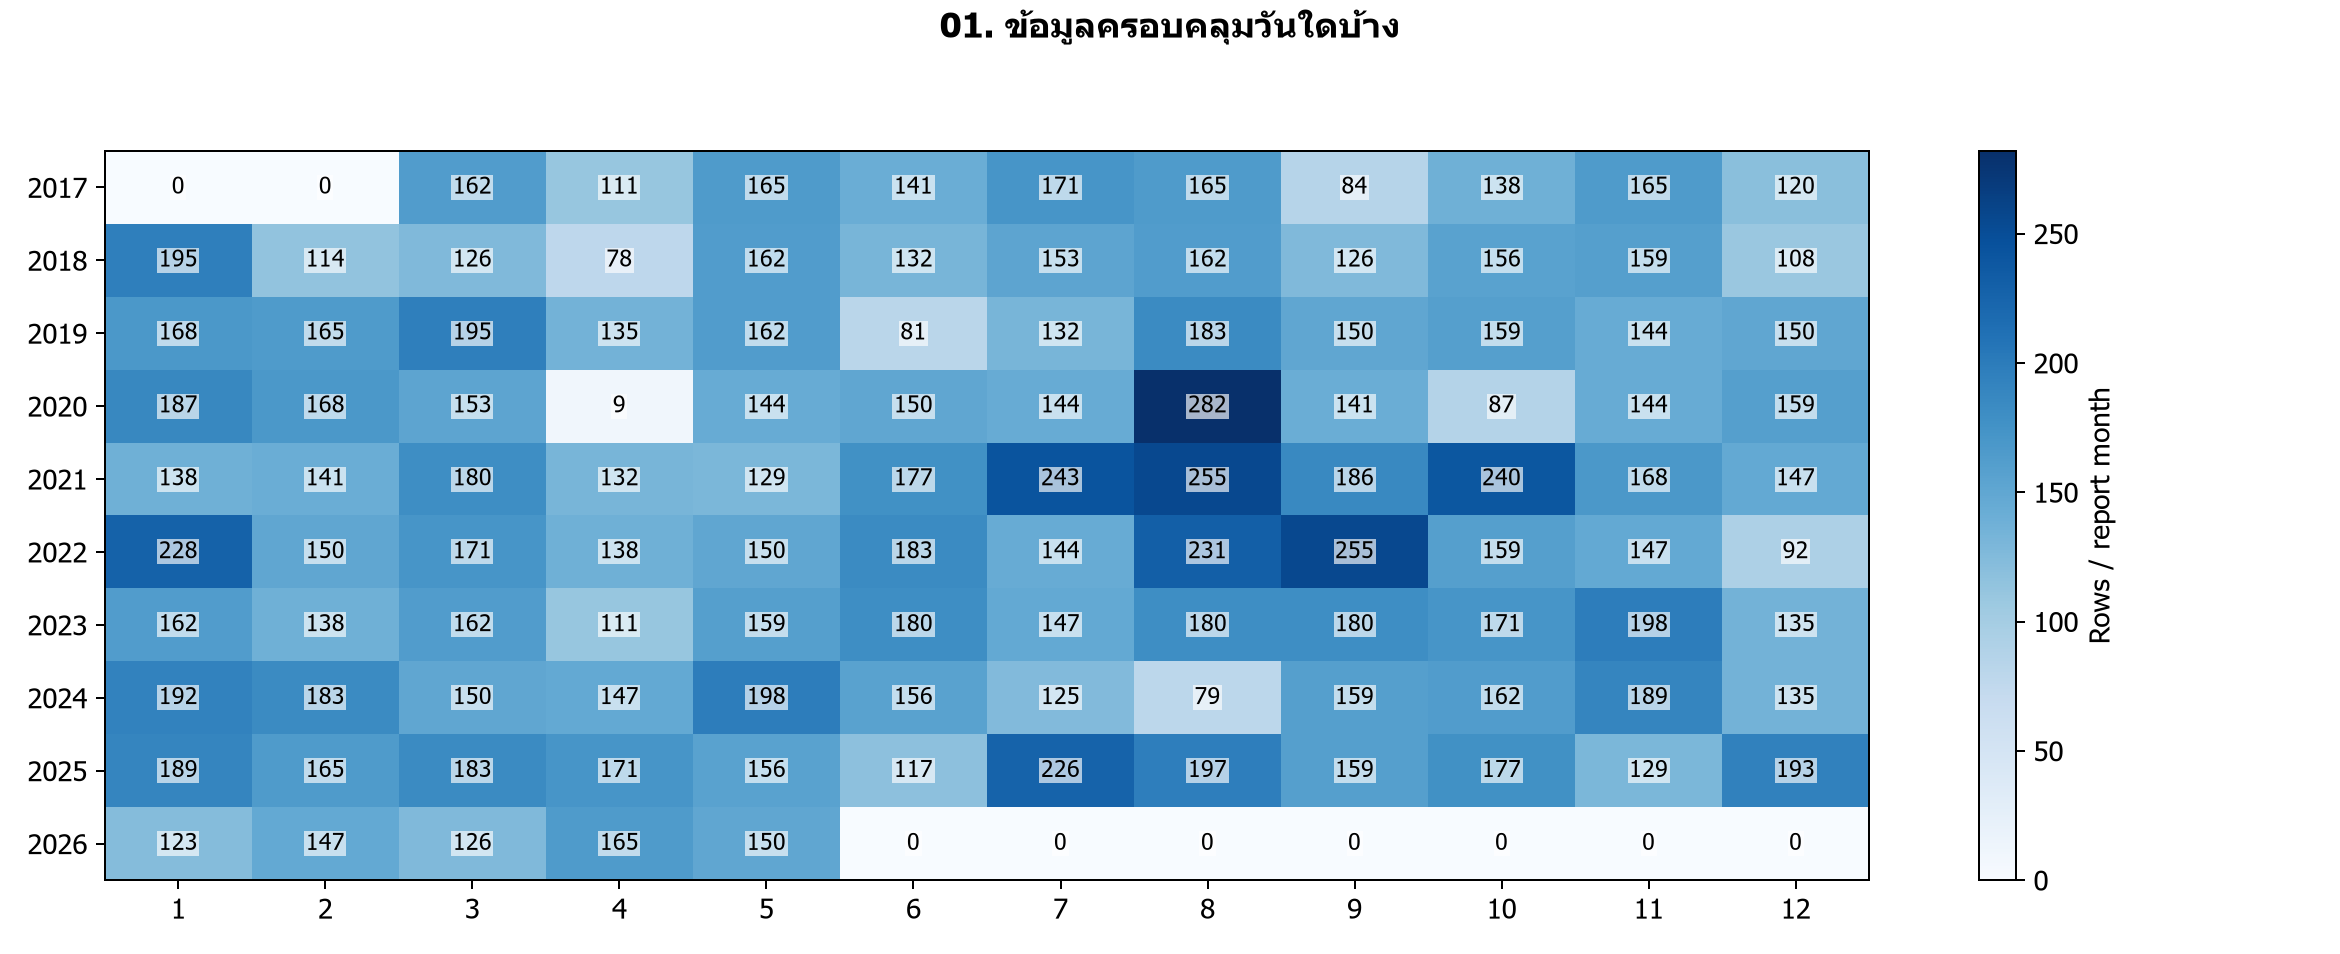

**วิธีอ่าน:** สีและตัวเลขคือจำนวนแถวต่อเดือนรายงาน ไม่ใช่ปริมาณรถ

**หลักฐาน:** วันสำรวจ 2017-03-01 ถึง 2026-05-29 | 17,440 แถว → ผ่านเกณฑ์ 17,250 แถว

**ข้อจำกัด:** ข้อมูลเป็นวันสำรวจบางวัน และปีล่าสุดไม่ครบปี; ช่อง 0 คือไม่มีรายการในไฟล์

**แนวพูด:** เรามีข้อมูลหลายปี แต่ไม่ได้มีทุกแยกทุกวัน จึงรวมยอดรายปีมาเทียบตรง ๆ ไม่ได้

**นำไปใช้:** เปรียบเทียบหน่วยเดิมและเวลาเดิมก่อนตีความ

## 02. ปริมาณรถในหน่วยที่จับคู่ครบสามช่วง

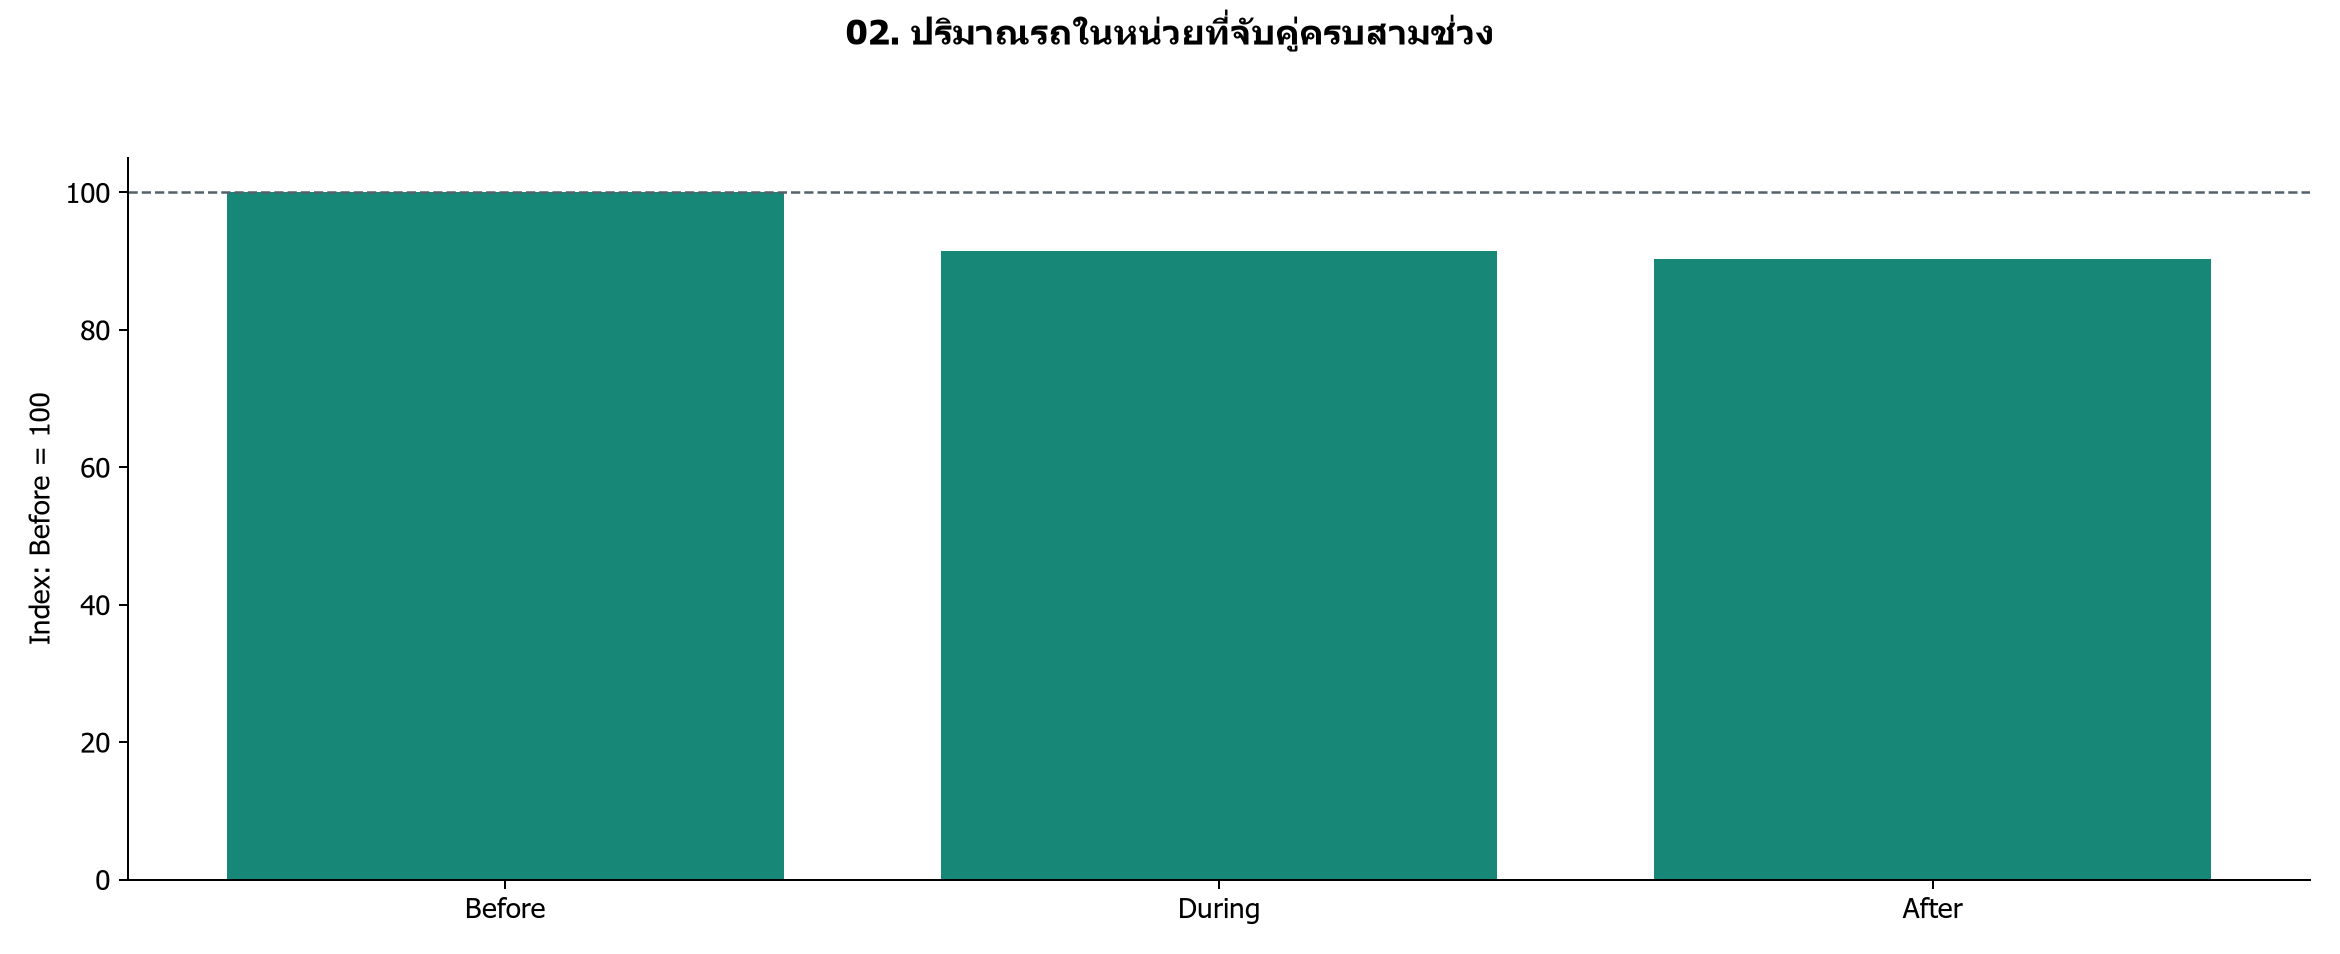

**วิธีอ่าน:** ใช้มัธยฐานคัน/ชั่วโมงของแต่ละหน่วยในแต่ละช่วง หารฐาน Before ของหน่วยนั้น แล้วหามัธยฐานข้ามหน่วย

**หลักฐาน:** Before 100 → During 91.5 → After 90.2 | n=721 หน่วย

**ข้อจำกัด:** เป็นดัชนีของตัวอย่าง ไม่ใช่ยอดรถรวมทั้งเมือง; ไม่พิสูจน์ผลเชิงสาเหตุ

**แนวพูด:** ตั้ง Before ของแต่ละหน่วยเป็น 100 ผลภาพรวมคือ Before 100 → During 91.5 → After 90.2 | n=721 หน่วย จึงพบระดับต่ำกว่าฐานทั้งสองช่วง แต่ยังแยกสาเหตุไม่ได้ ช่วง 95%: During 87.9–94.9; After 86.6–93.0

**นำไปใช้:** เริ่มดูการกระจายและสถานที่ เพราะค่ากลางอาจซ่อนความต่าง

## 03. แต่ละหน่วยอยู่เหนือหรือต่ำกว่าฐาน

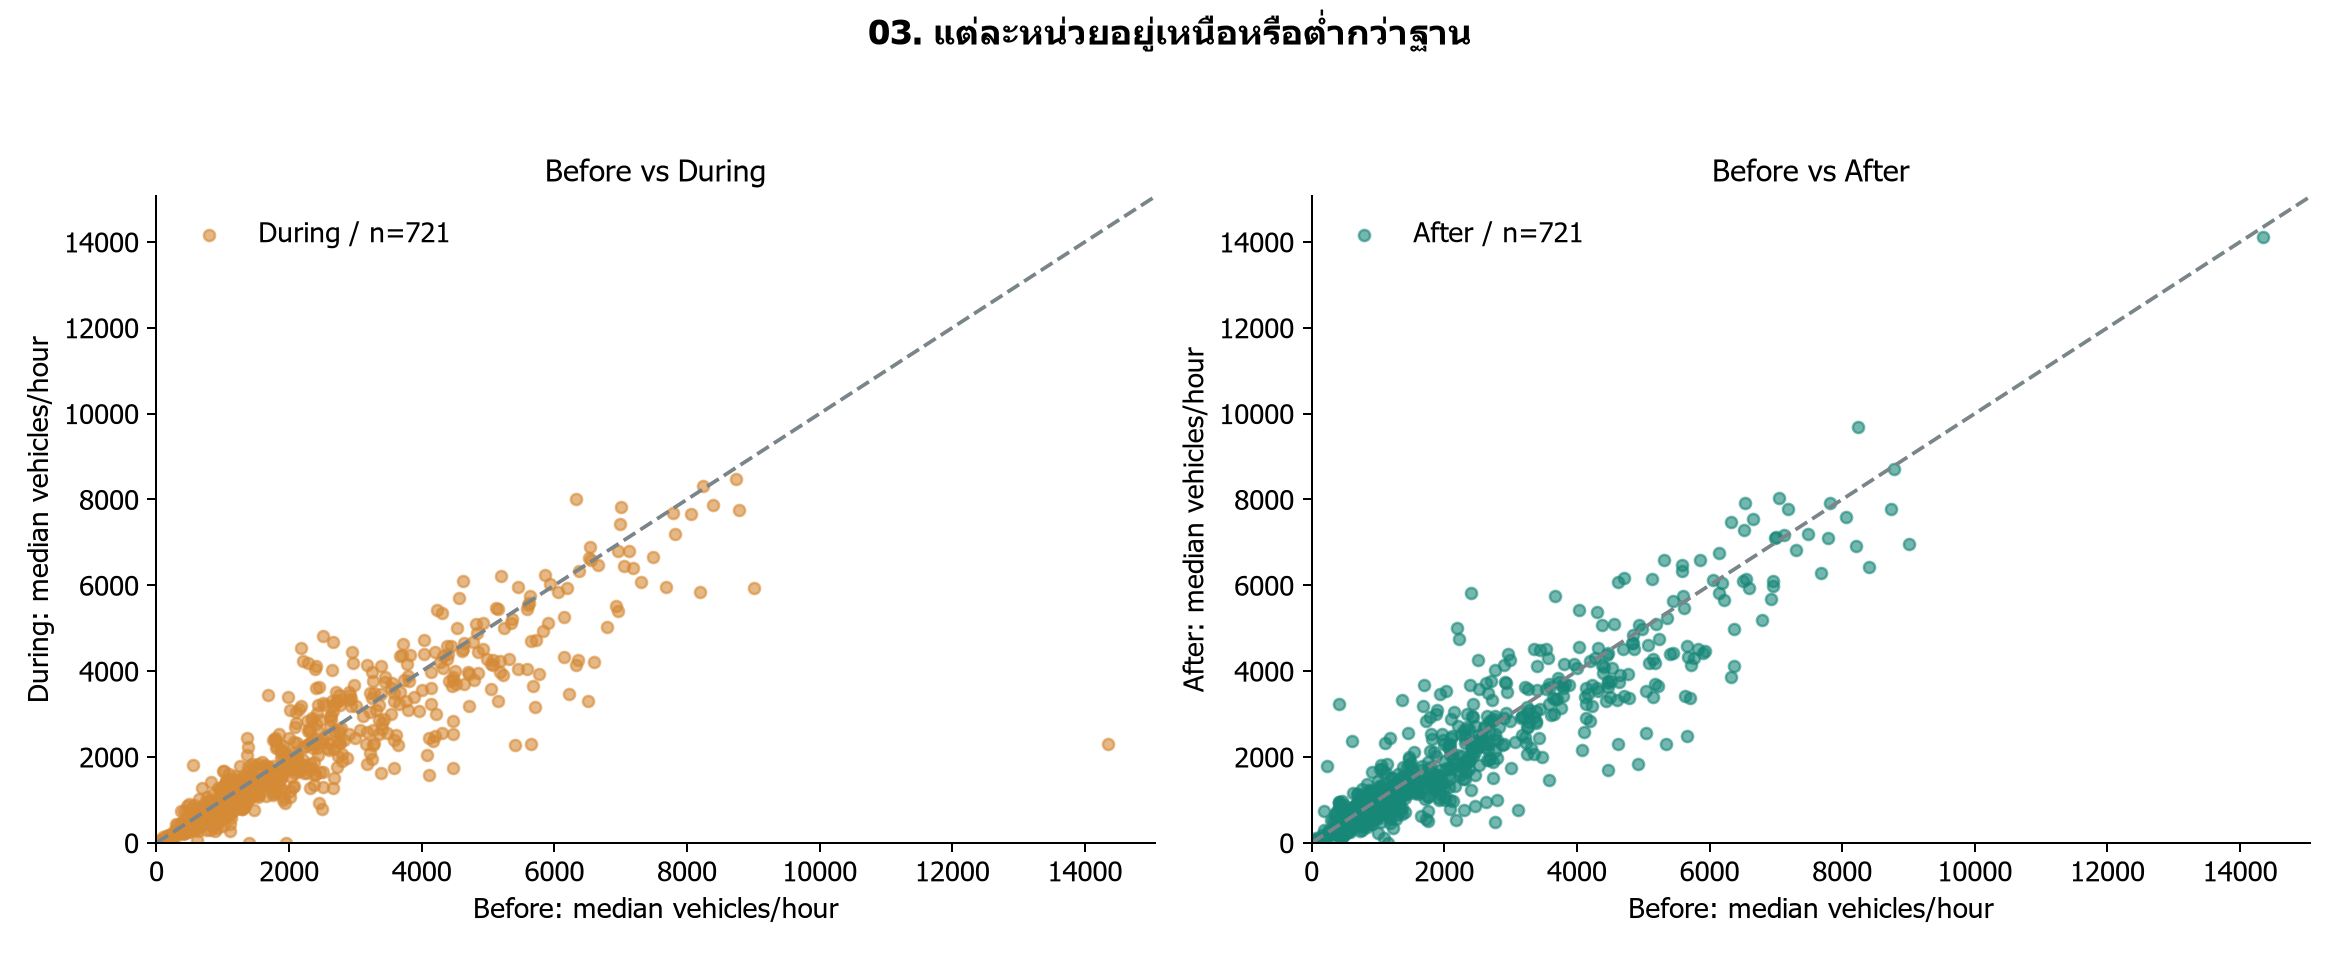

**วิธีอ่าน:** หนึ่งจุดคือทางแยก–ถนน–ช่วงเวลา; จุดใต้เส้นทแยงมีปริมาณต่ำกว่า Before

**หลักฐาน:** ต่ำกว่าฐาน: During 64.5% | After 65.3% ของ 721 หน่วย

**ข้อจำกัด:** จุดสำรวจไม่ได้เป็นตัวอย่างสุ่มทั้งกรุงเทพฯ; จุดบนแกนศูนย์ยังแสดงไว้

**แนวพูด:** เส้นทแยงคือระดับเท่าเดิม เรามีทั้งจุดที่สูงขึ้นและต่ำลง ไม่ใช่ทุกแห่งเปลี่ยนไปในทิศทางเดียวกัน

**นำไปใช้:** ไม่ใช้ค่ากลางแทนการตัดสินทุกทางแยก

## 04. ค่ากลางซ่อนการกระจายมากแค่ไหน

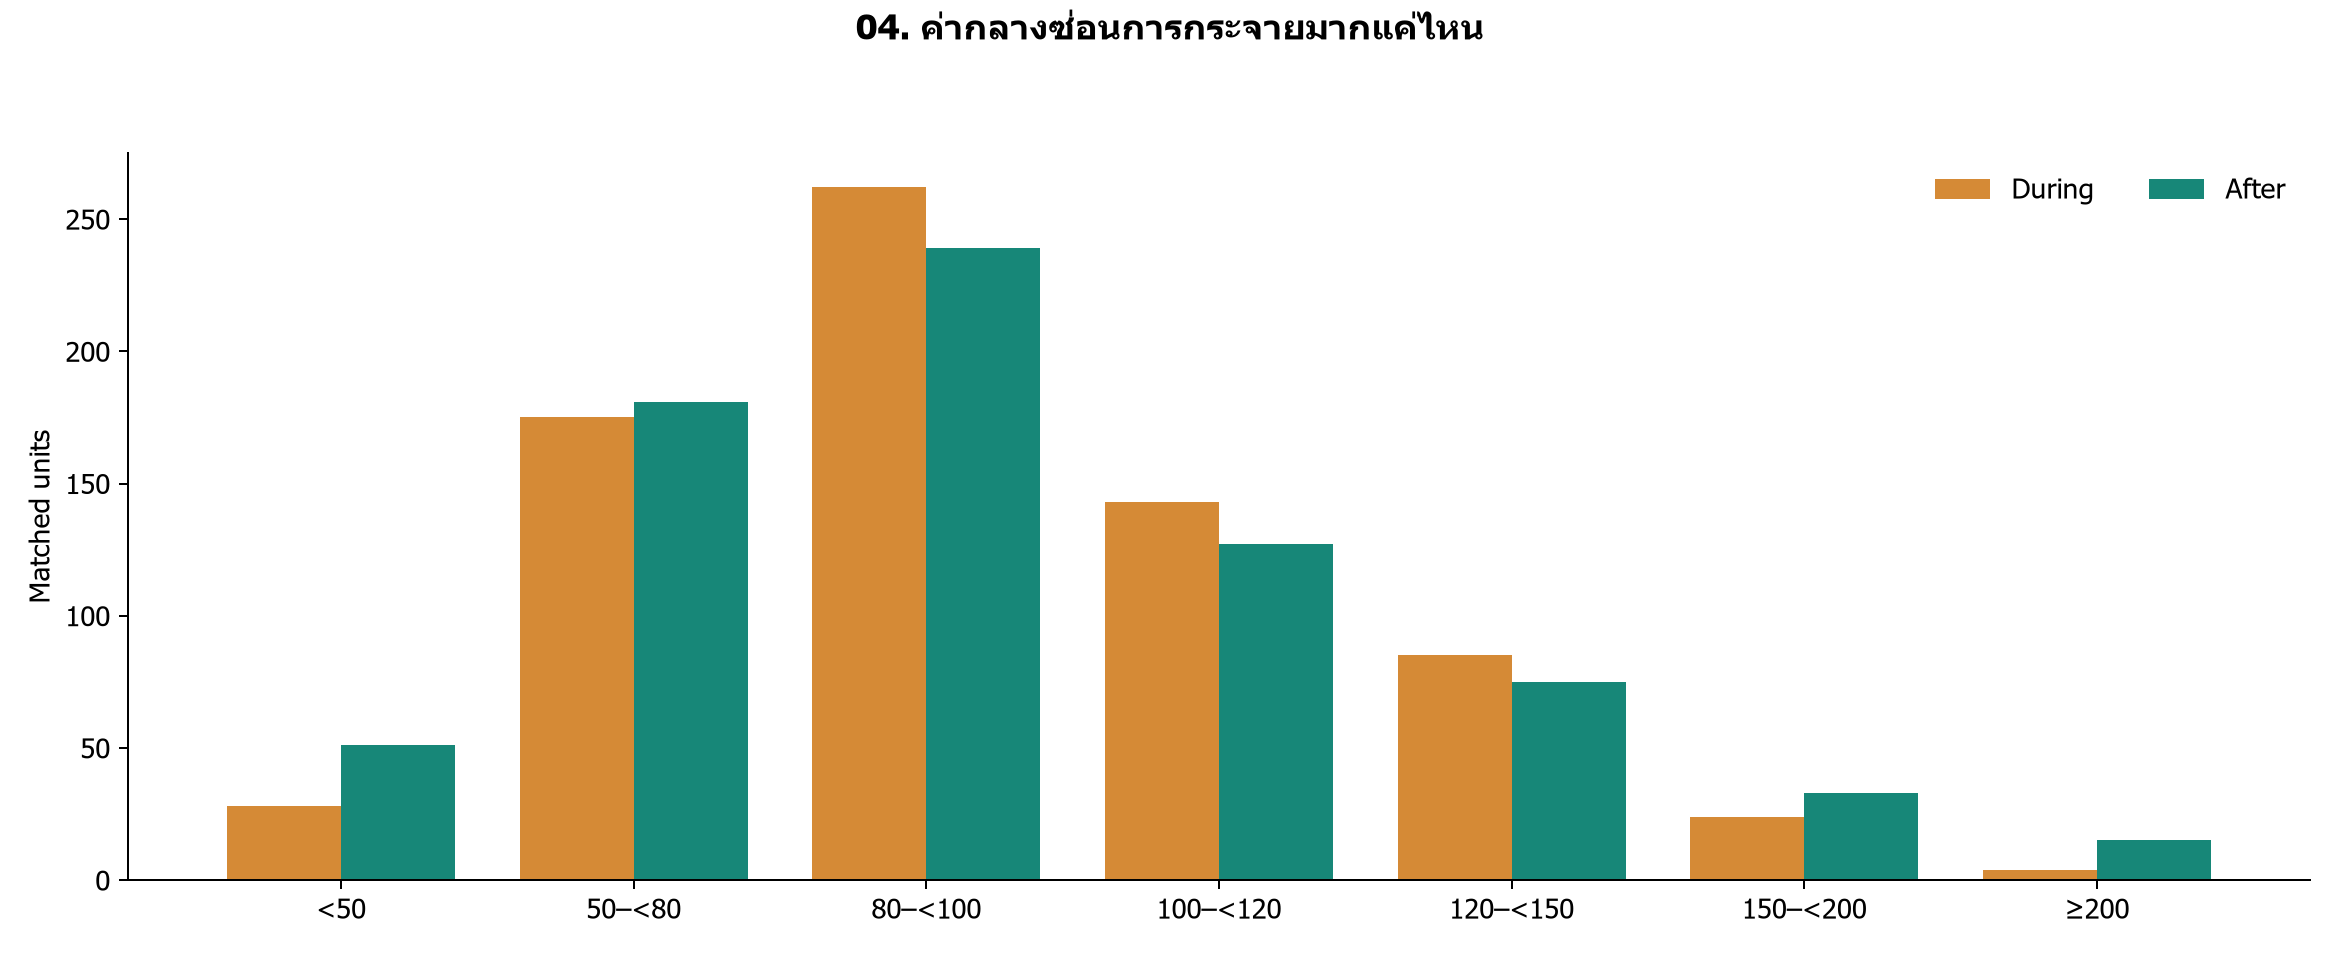

**วิธีอ่าน:** แกนนอนเป็นช่วงดัชนี โดย 100 เท่าฐาน; แกนตั้งคือจำนวนหน่วย ใช้ชุดเดิมครบทั้งสองช่วง

**หลักฐาน:** After มี 250/721 หน่วย (34.7%) ที่ไม่น้อยกว่าฐาน

**ข้อจำกัด:** ช่วงท้ายรวมดัชนีตั้งแต่ 200 ขึ้นไป; ฐานน้อยทำให้เปอร์เซ็นต์เปลี่ยนสูงได้

**แนวพูด:** ค่า After ใกล้ 90 ไม่ได้แปลว่าทุกแยกลด 10 เปอร์เซ็นต์ กราฟนี้แสดงทั้งกลุ่มต่ำกว่าฐานและกลุ่มที่กลับมาไม่น้อยกว่าฐาน

**นำไปใช้:** ใช้ข้อมูลคัน/ชั่วโมงประกอบดัชนีเมื่อเลือกจุดศึกษา

## 05. การเปลี่ยนแปลงมีสี่รูปแบบ

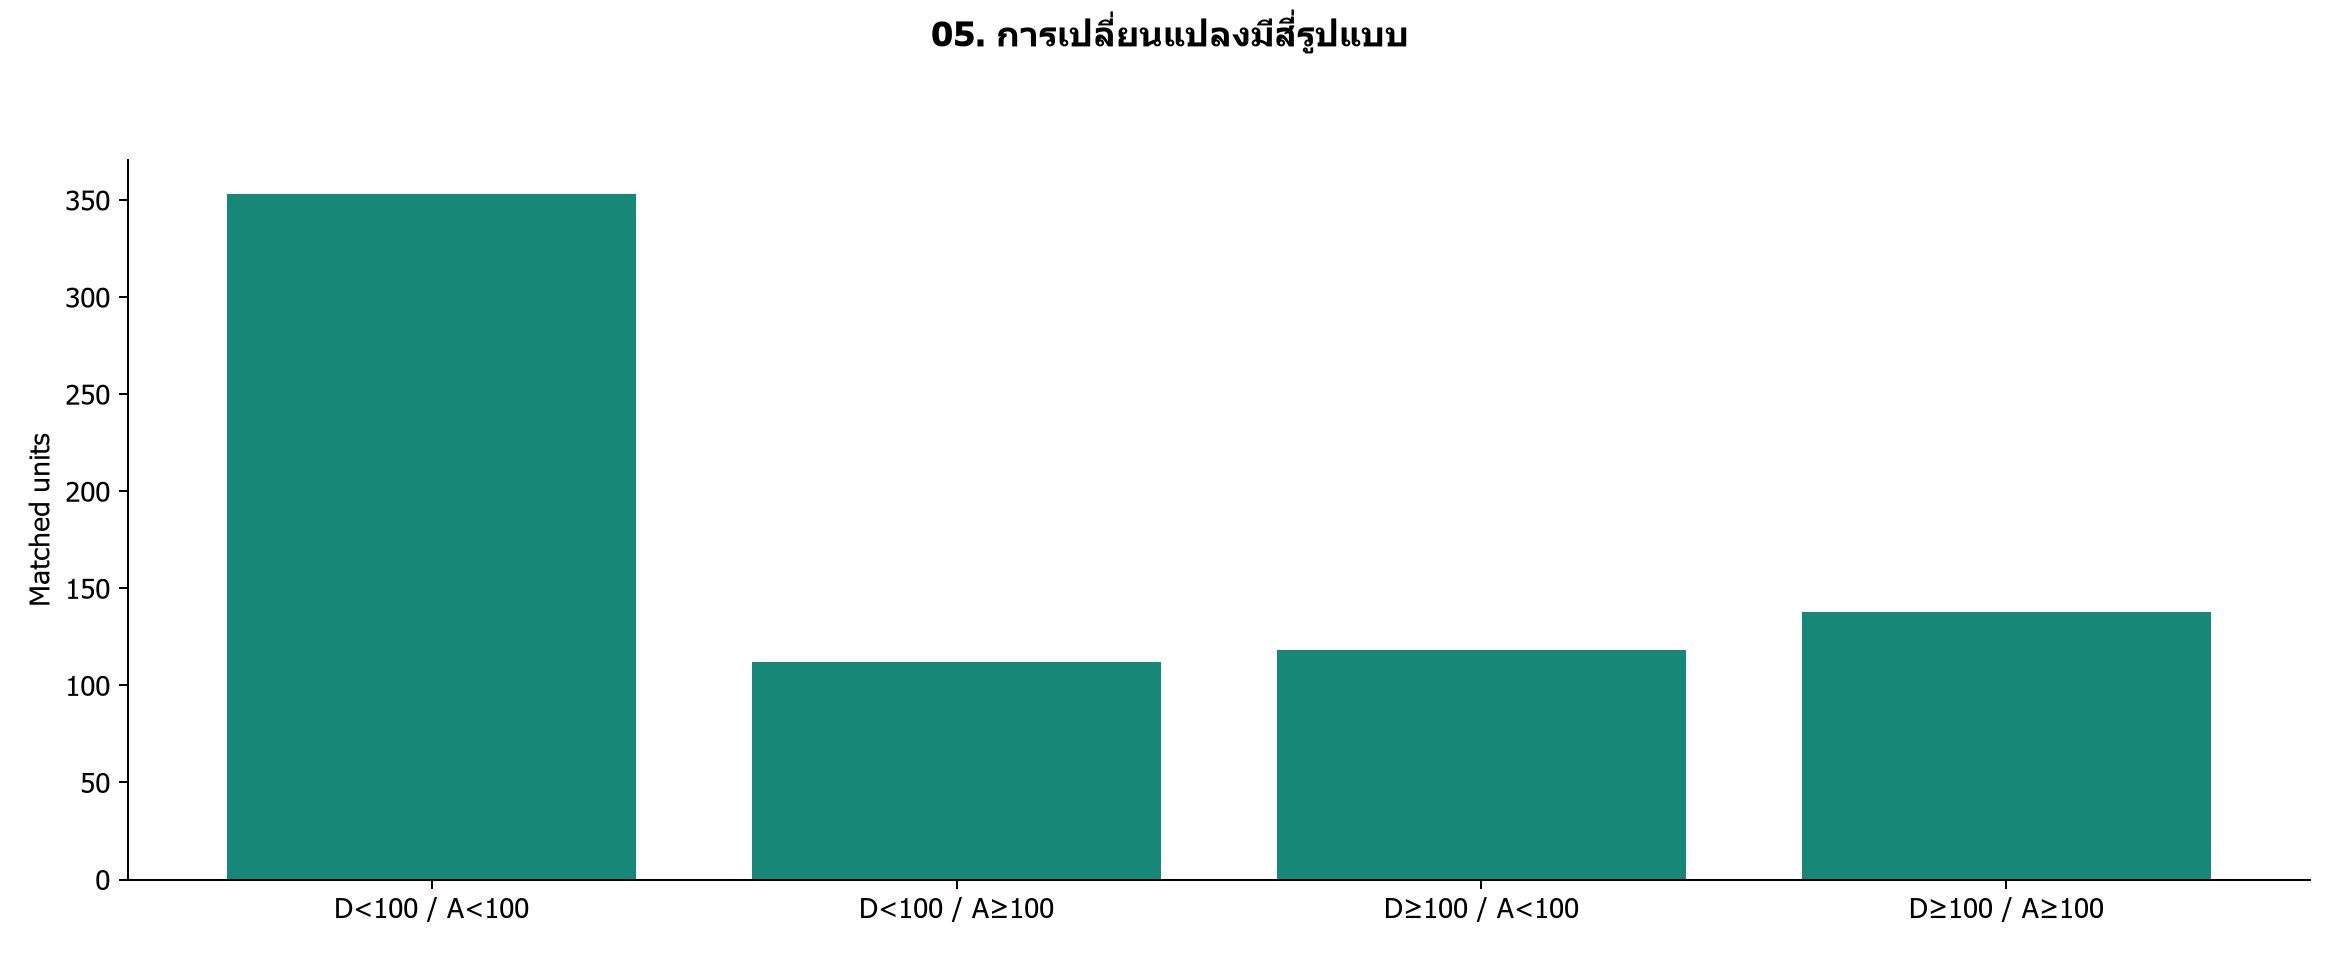

**วิธีอ่าน:** D = During, A = After; แบ่งด้วยดัชนี 100 ของ Before โดยใช้หน่วยเดิมทั้งหมด

**หลักฐาน:** ต่ำกว่าฐานทั้งสองช่วง 353 หน่วย; During ต่ำ แต่ After ≥ ฐาน 112 หน่วย

**ข้อจำกัด:** เป็นการจำแนกระดับ ไม่ใช่เส้นทางรายปีต่อเนื่อง และไม่ใช่การทดสอบนัยสำคัญ

**แนวพูด:** การบอกเพียงว่าฟื้นหรือไม่ฟื้นยังหยาบเกินไป เราแยกได้สี่แบบ บางแห่งต่ำกว่าฐานทั้งสองช่วง บางแห่งกลับมาไม่น้อยกว่าฐานใน After

**นำไปใช้:** ใช้รูปแบบเป็นเกณฑ์เลือกกรณีศึกษาหรือสำรวจซ้ำ

## 06. ช่วงเวลาสำรวจให้ผลเหมือนกันหรือไม่

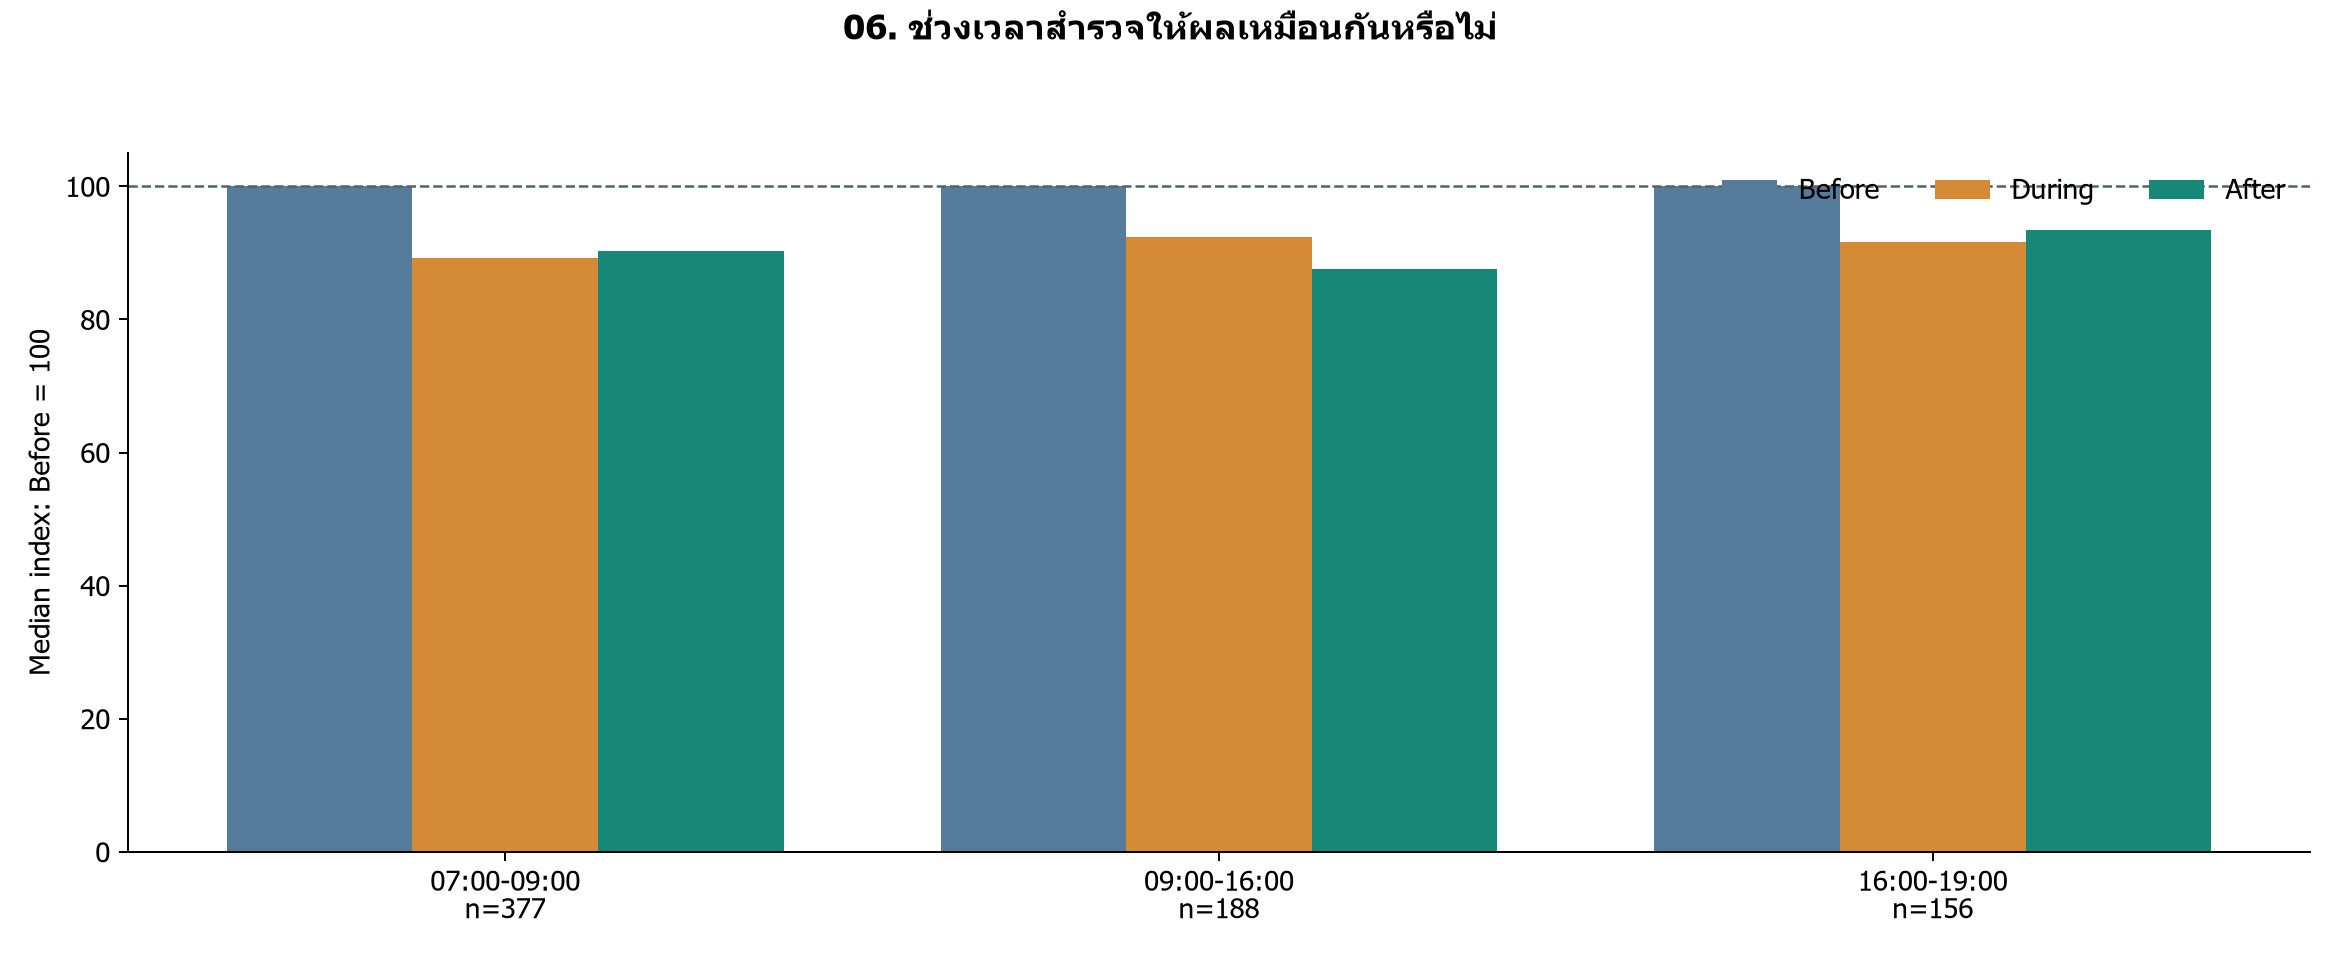

**วิธีอ่าน:** แต่ละกลุ่มเปรียบเทียบสามช่วงภายในเวลาเดียวกัน; ทุกค่าหารด้วยชั่วโมงสำรวจแล้ว

**หลักฐาน:** มี 3 ช่วงเวลาที่จับคู่ได้; จำนวนหน่วยต่อเวลา 156–377 หน่วย

**ข้อจำกัด:** กลุ่มเวลาประกอบด้วยสถานที่ต่างกัน จึงไม่ใช้สรุปว่าคนย้ายเวลาเดินทาง

**แนวพูด:** เวลาเย็น 16–19 กับ 17–19 เป็นคนละหน่วย เราไม่รวมเพราะอาจทำให้ความหมายเปลี่ยน กลุ่มเล็กต้องอ่านด้วยความระมัดระวัง

**นำไปใช้:** ถ้าจะตอบการย้ายเวลา ต้องจับคู่จุดและวันที่เดียวกันข้ามเวลาด้วย

## 07. สถานที่ที่มีความต่างเด่น

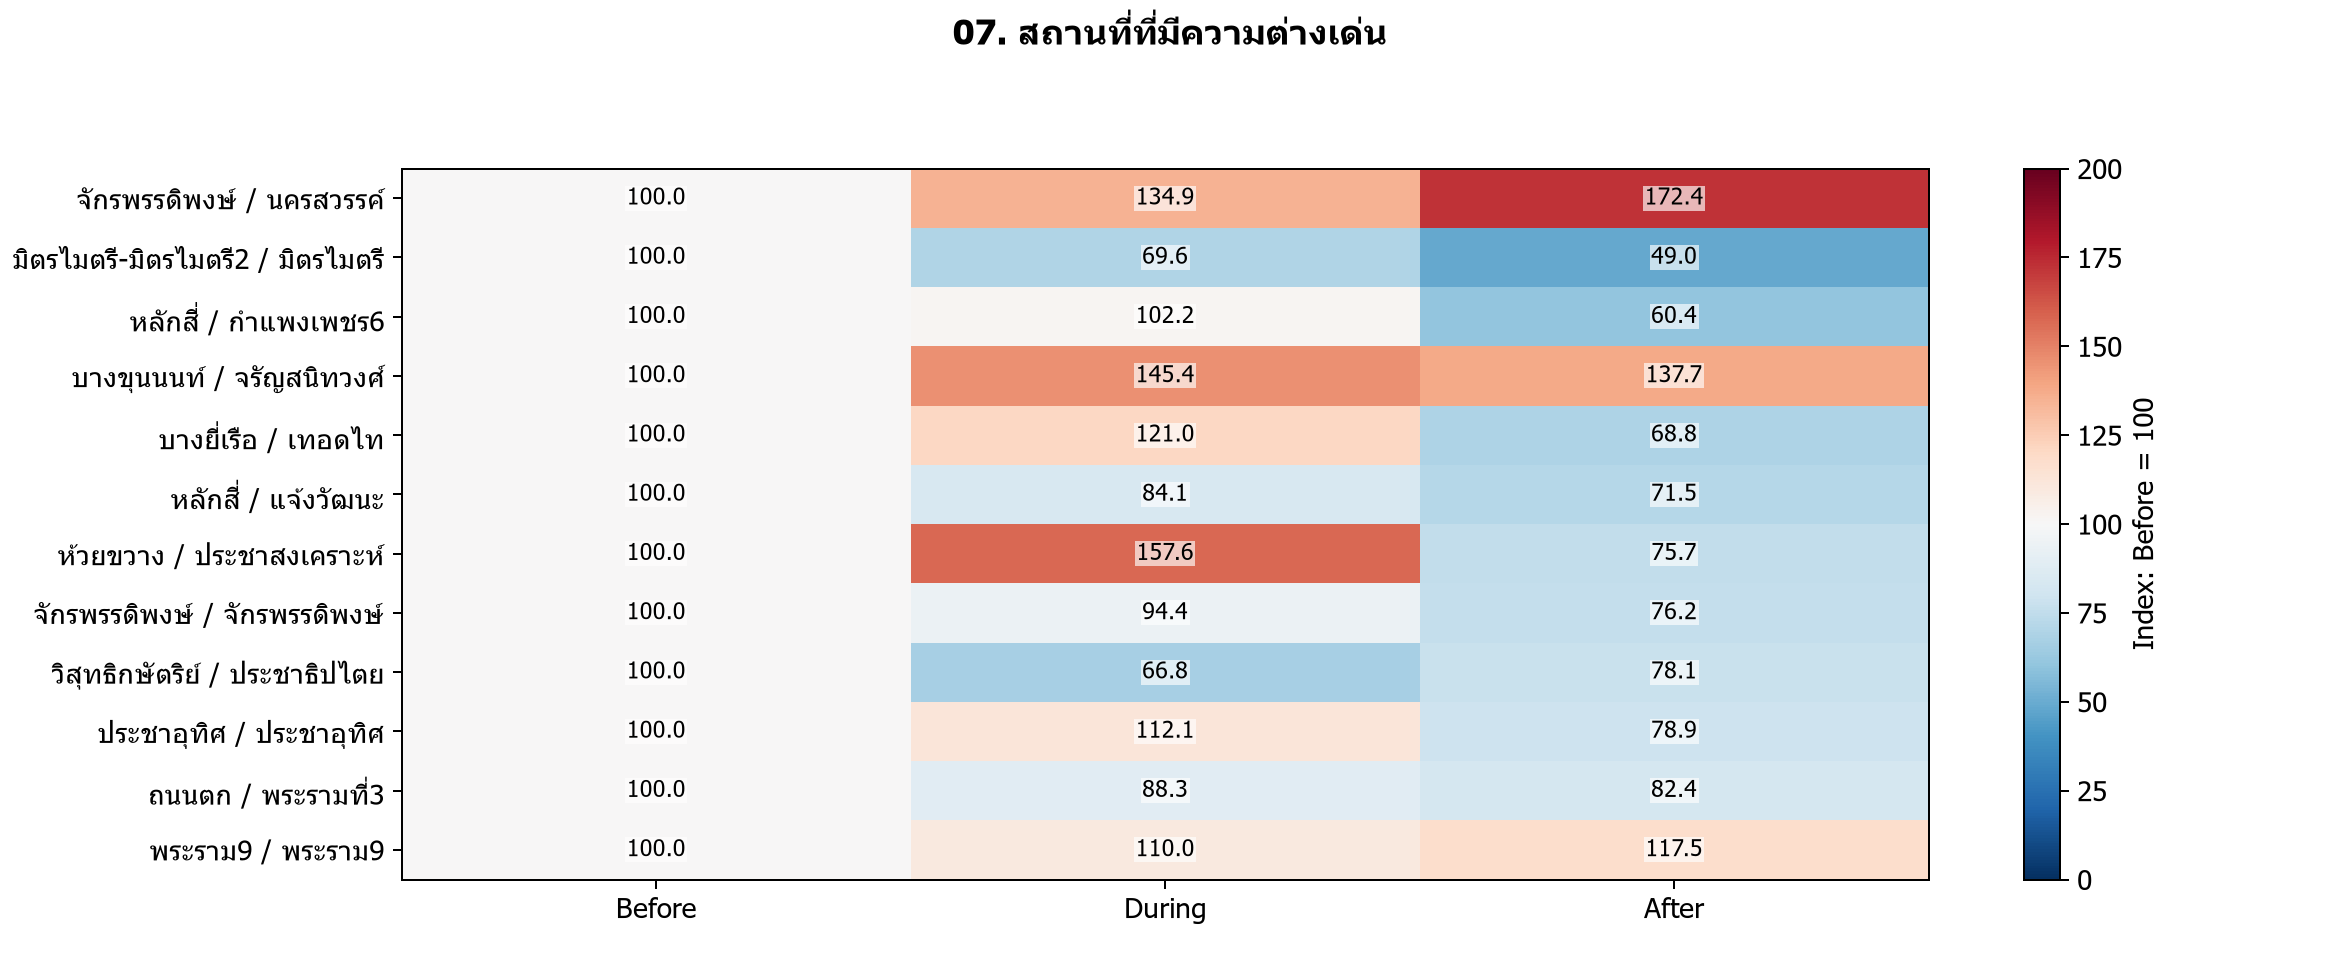

**วิธีอ่าน:** แสดงคู่เช้า 07–09 น. ที่มีอย่างน้อย 2 รายการทุกช่วง เลือก 12 คู่ที่ |After−100| มากที่สุด; สเกลสี 0–200

**หลักฐาน:** แสดง 12 คู่; สีแดงมากกว่า Before สีฟ้าต่ำกว่า Before และมีตัวเลขกำกับ

**ข้อจำกัด:** คัดผลต่างสูงเพื่อศึกษา ไม่เป็นตัวแทนทั้งเมือง; สีตัดที่ 200 แต่ตัวเลขไม่ตัด

**แนวพูด:** หลังเห็นภาพรวม เราซูมไปยังจุดที่ต่างเด่น โดยเปิดเผยเกณฑ์เลือกตั้งแต่ต้น แล้วตรวจวันที่และประเภทรถต่อ

**นำไปใช้:** ทวนรายงานต้นทางก่อนตั้งสมมติฐานเรื่องบริบทพื้นที่

## 08. วันที่สำรวจของกรณีศึกษา

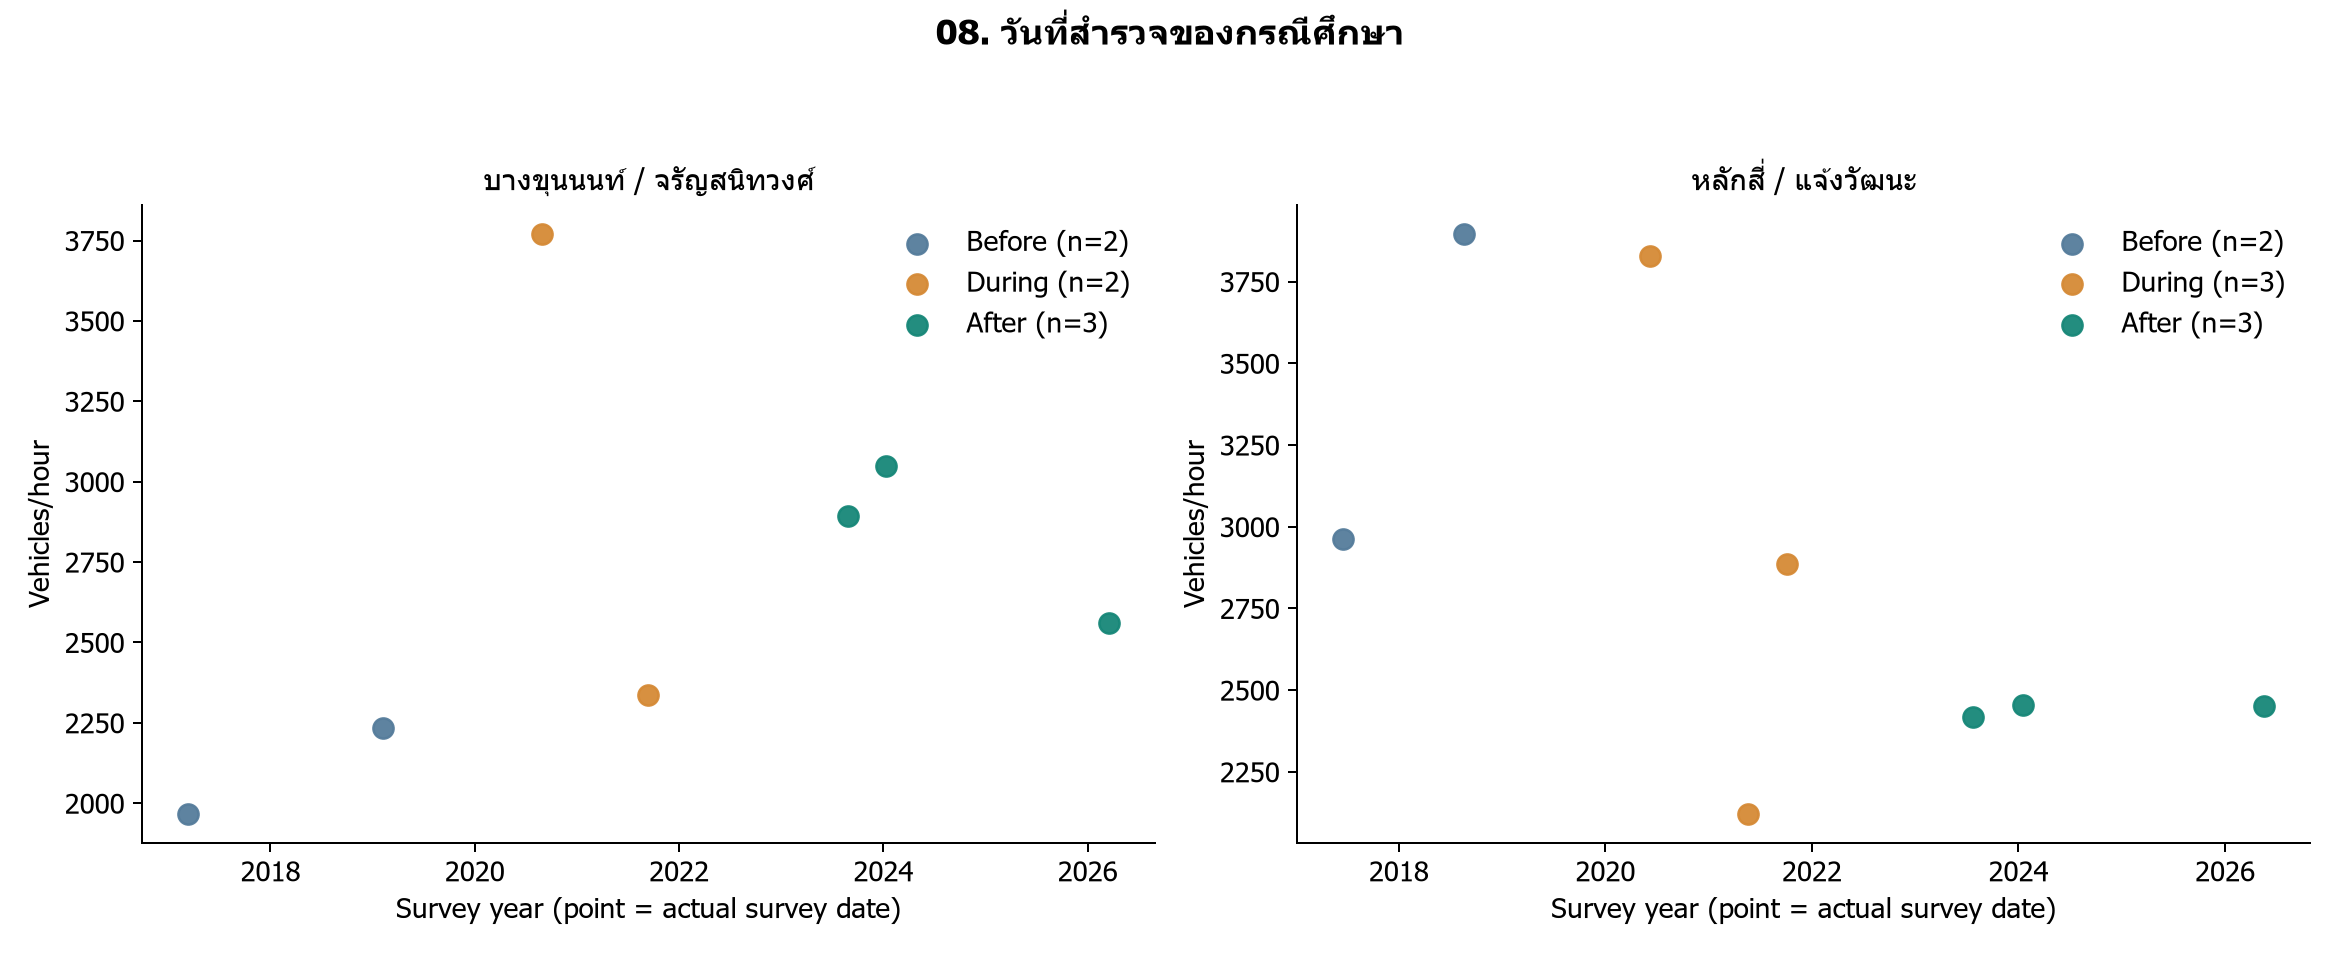

**วิธีอ่าน:** แต่ละจุดคือวันสำรวจจริง ไม่ลากเส้นเชื่อม; วันเต็มและแถว Excel อยู่ในตาราง

**หลักฐาน:** บางขุนนนท์: n=2/2/3; หลักสี่: n=2/3/3

**ข้อจำกัด:** บางขุนนนท์: เดือนร่วม []; หลักสี่: เดือนร่วม []; [] = ไม่มีเดือนร่วมครบสามช่วง ยังไม่มีหลักฐานเทศกาลหรือปลายทาง

**แนวพูด:** จำนวนวันและเดือนของกรณีศึกษาอยู่ในตาราง แม้ค่าจะต่างชัด ก็ยังอธิบายไม่ได้ว่าเกิดจากโควิด เทศกาล งานก่อสร้าง หรือความผันผวนของวันสำรวจ

**นำไปใช้:** ใช้วันนี้ไปตรวจ PDF และประวัติเหตุการณ์ แยกสิ่งยืนยันแล้วออกจากสมมติฐาน

## 09. ประเภทรถที่ประกอบเป็นความต่างของพื้นที่

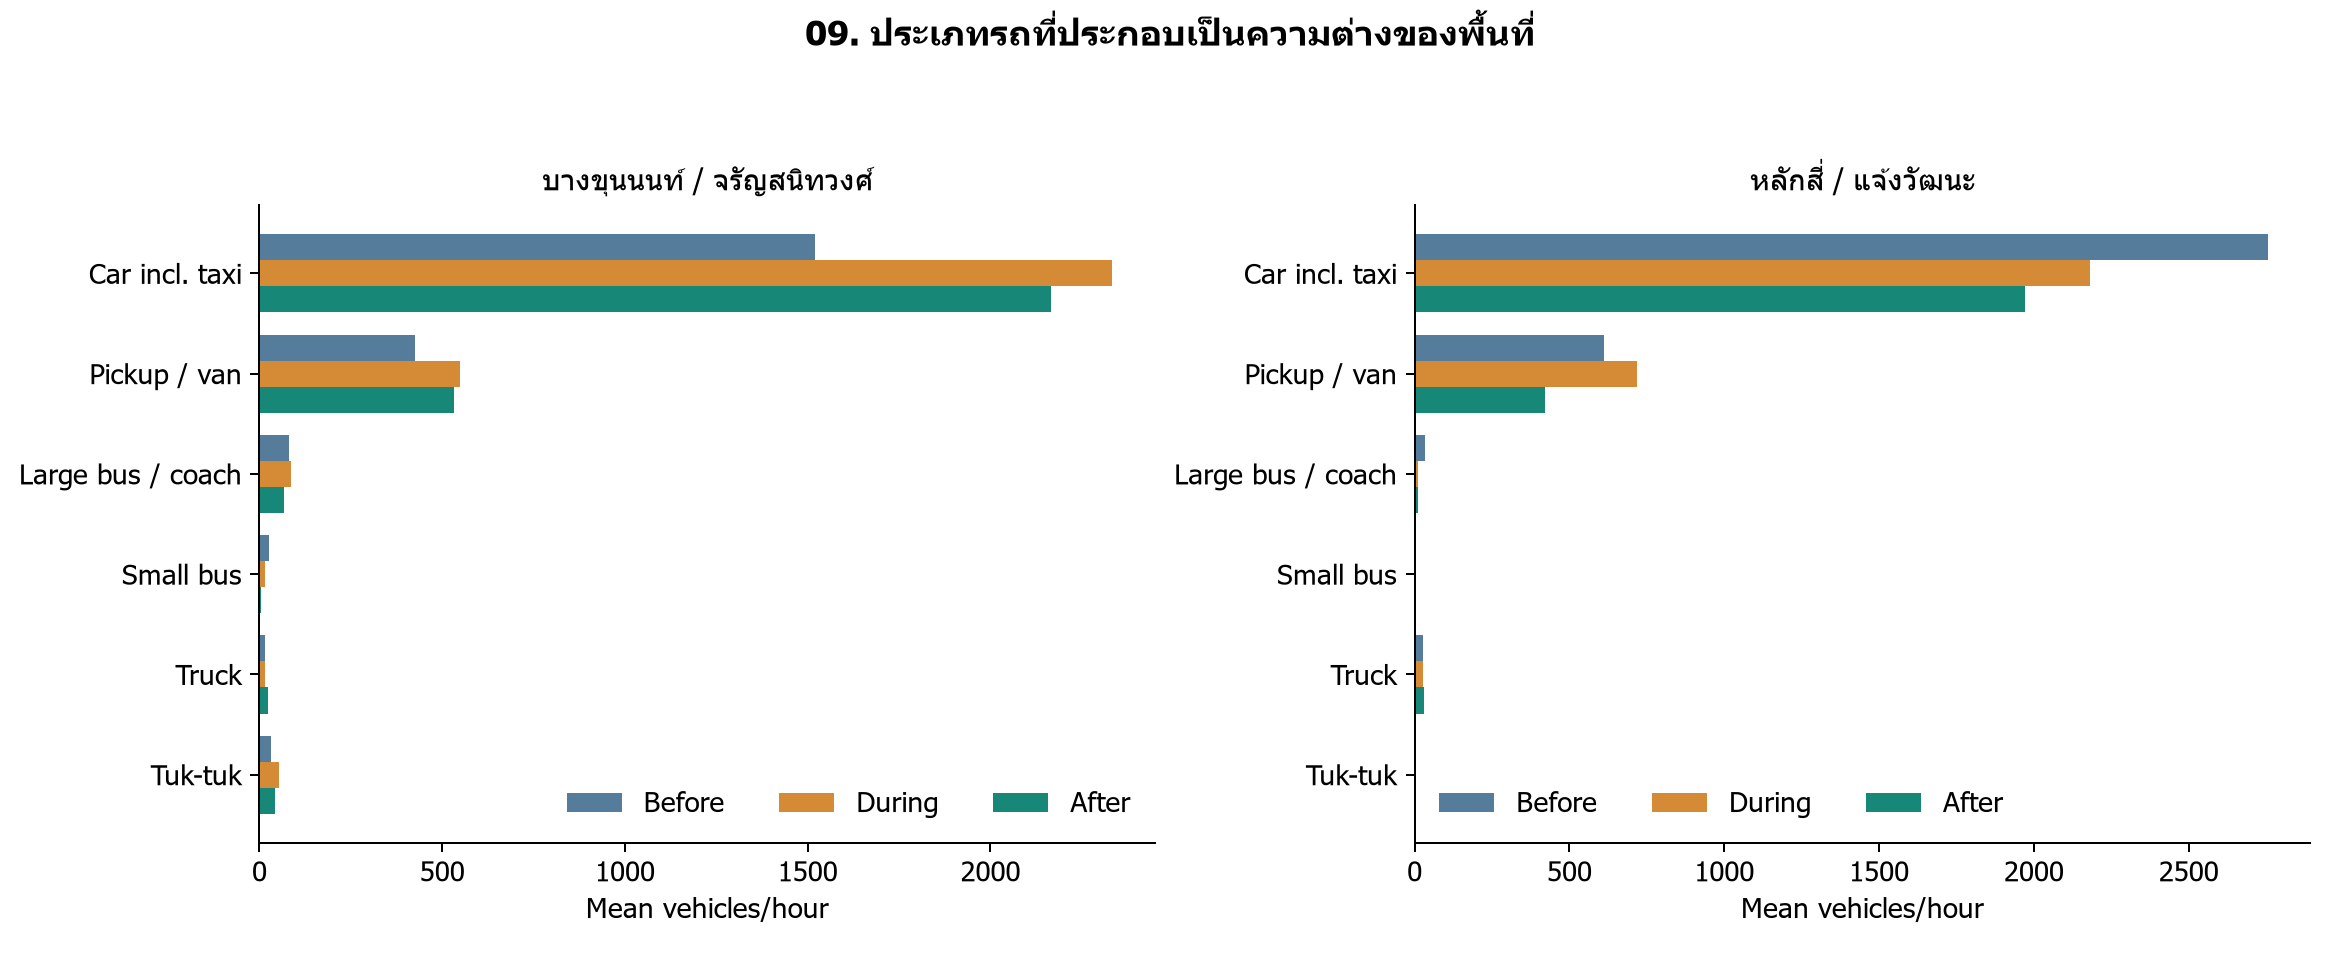

**วิธีอ่าน:** ทุกหมวดมี Before / During / After; ใช้ค่าเฉลี่ยคัน/ชั่วโมงเพื่อแสดงระดับของหมวดรถ

**หลักฐาน:** บางขุนนนท์: ดัชนีรถรวม After เทียบ Before +37.7%; หลักสี่: ดัชนีรถรวม After เทียบ Before -28.5%

**ข้อจำกัด:** เปอร์เซ็นต์รถรวมในข้อความคำนวณจากมัธยฐาน แต่แท่งหมวดรถเป็นค่าเฉลี่ย; ห้ามบวกมัธยฐานรายหมวดแทนรถรวม

**แนวพูด:** ดูว่าหมวดใดมีระดับมากและหมวดใดเปลี่ยน โดยยังไม่ตีความว่าเป็นการเปลี่ยนพาหนะของคนกลุ่มเดิม

**นำไปใช้:** ตรวจหมวดที่เปลี่ยนมากกับตารางนับรถต้นทาง

## 10. องค์ประกอบรถครบสามช่วง

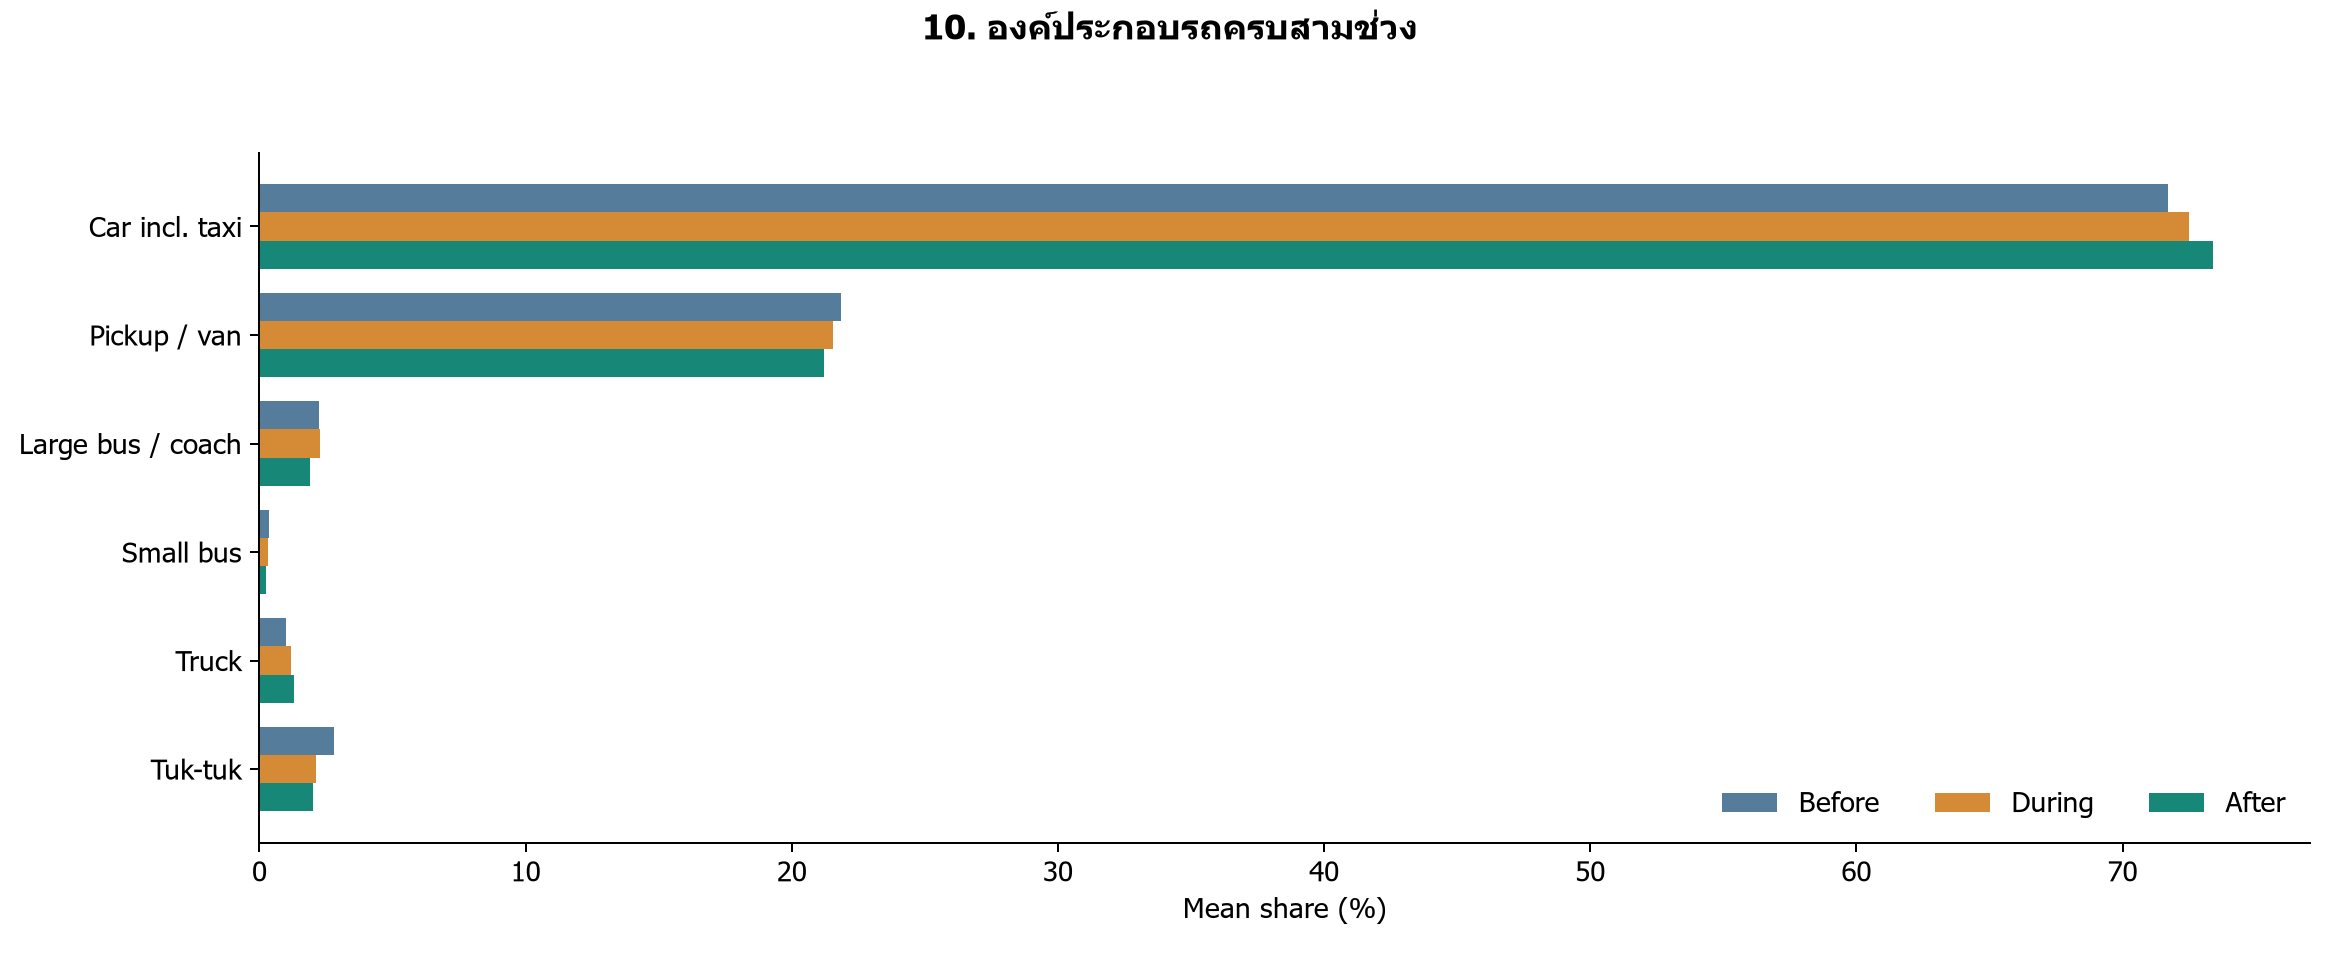

**วิธีอ่าน:** คำนวณสัดส่วนแต่ละรายการ → เฉลี่ยในหน่วย–ช่วง → เฉลี่ยข้ามหน่วยร่วมที่มีรถรวมบวกครบทุกช่วง

**หลักฐาน:** รถยนต์รวมแท็กซี่: 71.72% → 72.51% → 73.39% | n=719

**ข้อจำกัด:** n=719 หน่วย; สัดส่วนไม่ใช่จำนวน และชุดนี้ไม่มีจักรยานยนต์

**แนวพูด:** รถยนต์เป็นหมวดใหญ่ที่สุดในหกหมวดที่เราเก็บได้ แต่ไม่ใช่ส่วนแบ่งทุกยานพาหนะของกรุงเทพฯ และไม่ใช่รถส่วนตัวทั้งหมด

**นำไปใช้:** ใช้ประกอบการวางแผนสำรวจหมวดรถเพิ่มเติม

## 11. สัดส่วนหมวดเล็กเปลี่ยนอย่างไร

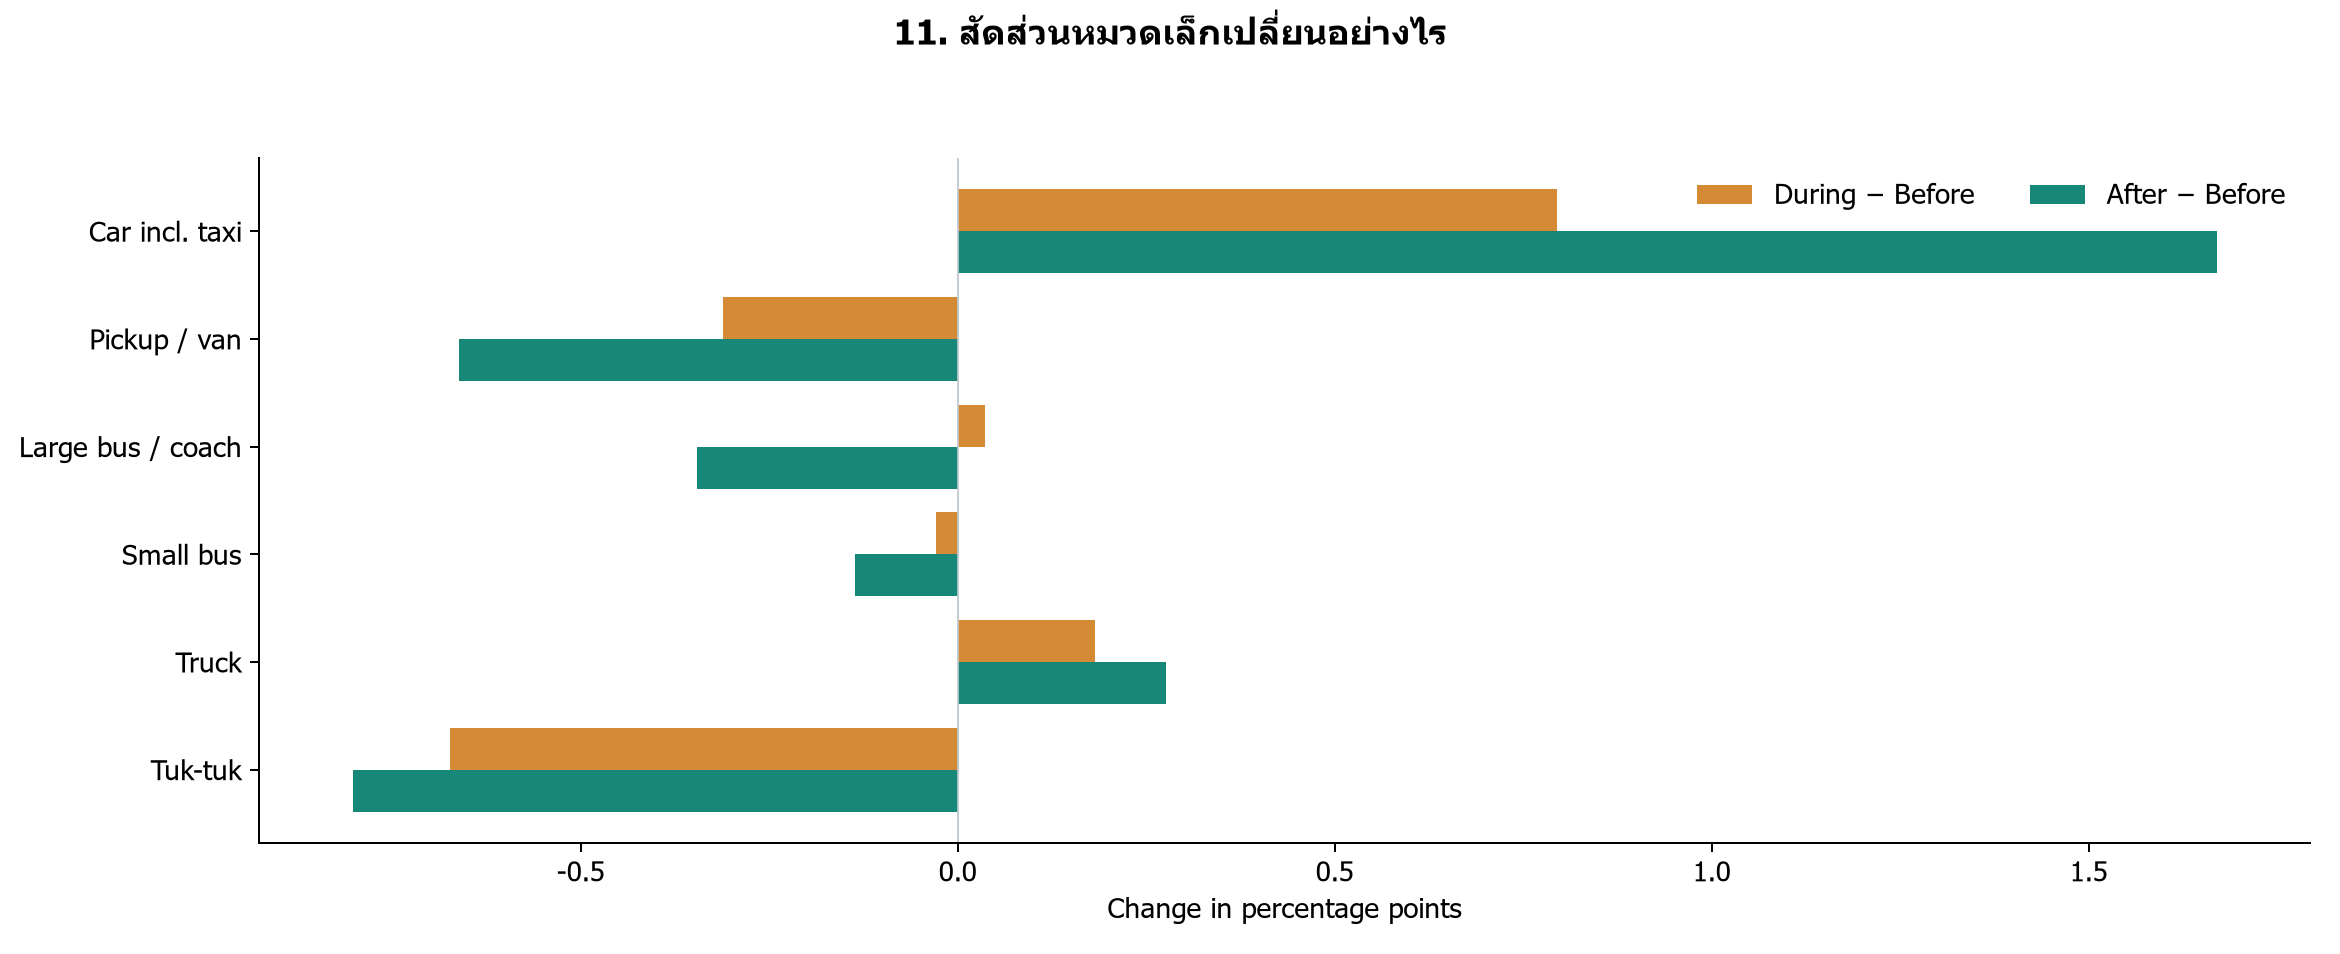

**วิธีอ่าน:** ค่าบวกคือส่วนแบ่งเพิ่ม ค่าลบคือส่วนแบ่งลด หน่วยเป็นจุดเปอร์เซ็นต์ ไม่ใช่เปอร์เซ็นต์การเติบโต

**หลักฐาน:** รถยนต์: During +0.80 จุด; After +1.67 จุด เทียบ Before

**ข้อจำกัด:** หมวดหนึ่งเพิ่ม ส่วนอื่นต้องลดรวมกันตามนิยามสัดส่วน; ไม่สรุปการย้ายจากรถเมล์ไปใช้รถส่วนตัว

**แนวพูด:** กราฟก่อนเห็นโครงสร้างใหญ่ ส่วนกราฟนี้ขยายการเปลี่ยนของแต่ละหมวดโดยใช้แกนศูนย์ร่วมกัน

**นำไปใช้:** ถ้าจะศึกษาการเปลี่ยนวิธีเดินทาง ต้องมีข้อมูลผู้เดินทางหรือผู้โดยสารเพิ่ม

## 12. Lockdown ภายในช่วง During

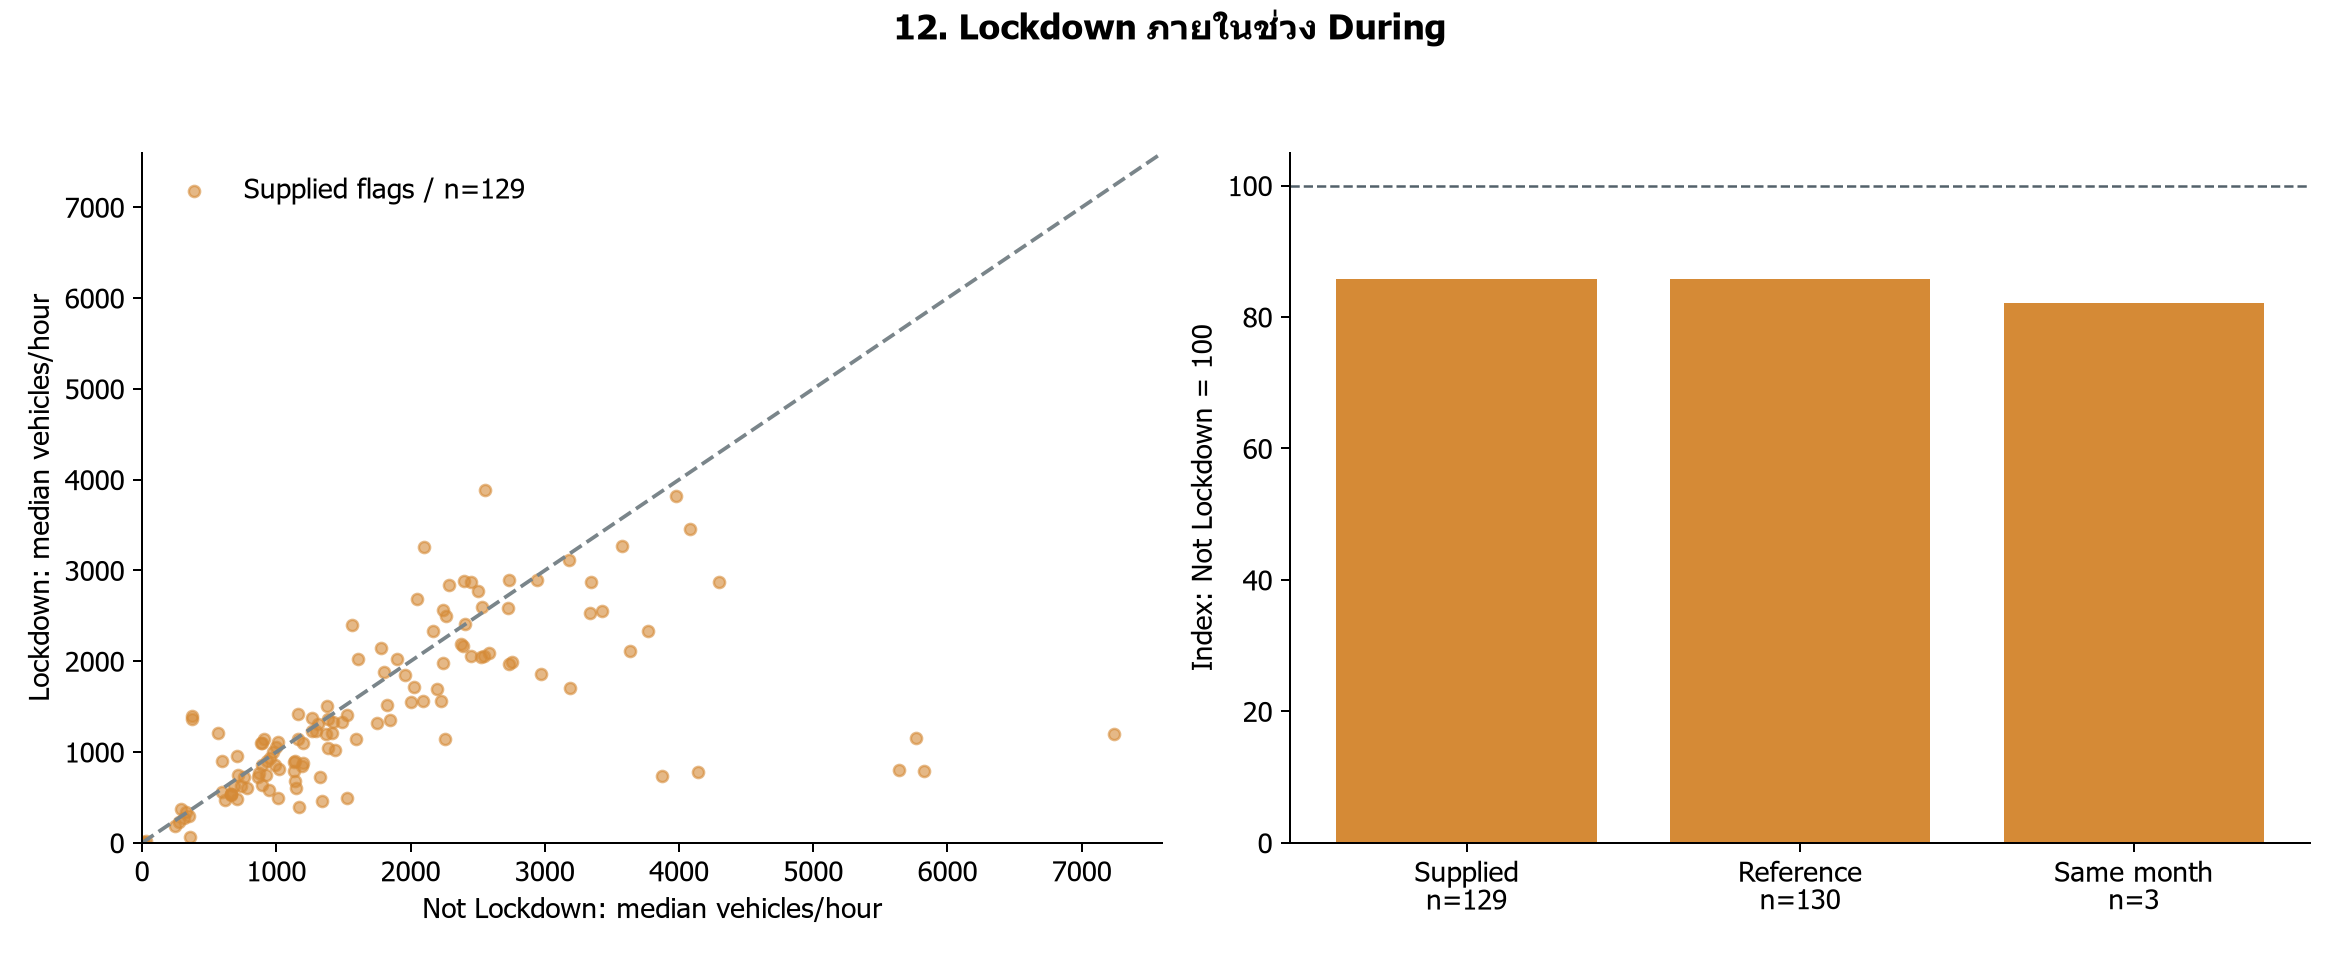

**วิธีอ่าน:** จับคู่ทางแยก–ถนน–เวลา ภายใน During เท่านั้น; กราฟขวาเทียบนิยามและเงื่อนไขเดือน

**หลักฐาน:** ตาม flag ในไฟล์ n=129: ดัชนี 85.7 | เทียบกรอบวันที่ 85.9

**ข้อจำกัด:** flag ต่างจากกรอบวันที่อ้างอิง 168 แถว; คุมเดือนเหลือ 3 หน่วย จึงไม่สรุปเชิงสาเหตุ

**แนวพูด:** ผลตาม flag พบระดับต่ำกว่า Not Lockdown แต่วันสำรวจและนิยามยังมีข้อจำกัด เราคง flag ของผู้ใช้และแสดงผลอีกนิยามประกอบ

**นำไปใช้:** ยืนยันเกณฑ์วันสิ้นสุดและทวนแถว flag ก่อนอ้างเป็นผลของมาตรการ

## 13. ข้อสรุปเปลี่ยนเมื่อจับคู่ละเอียดขึ้นหรือไม่

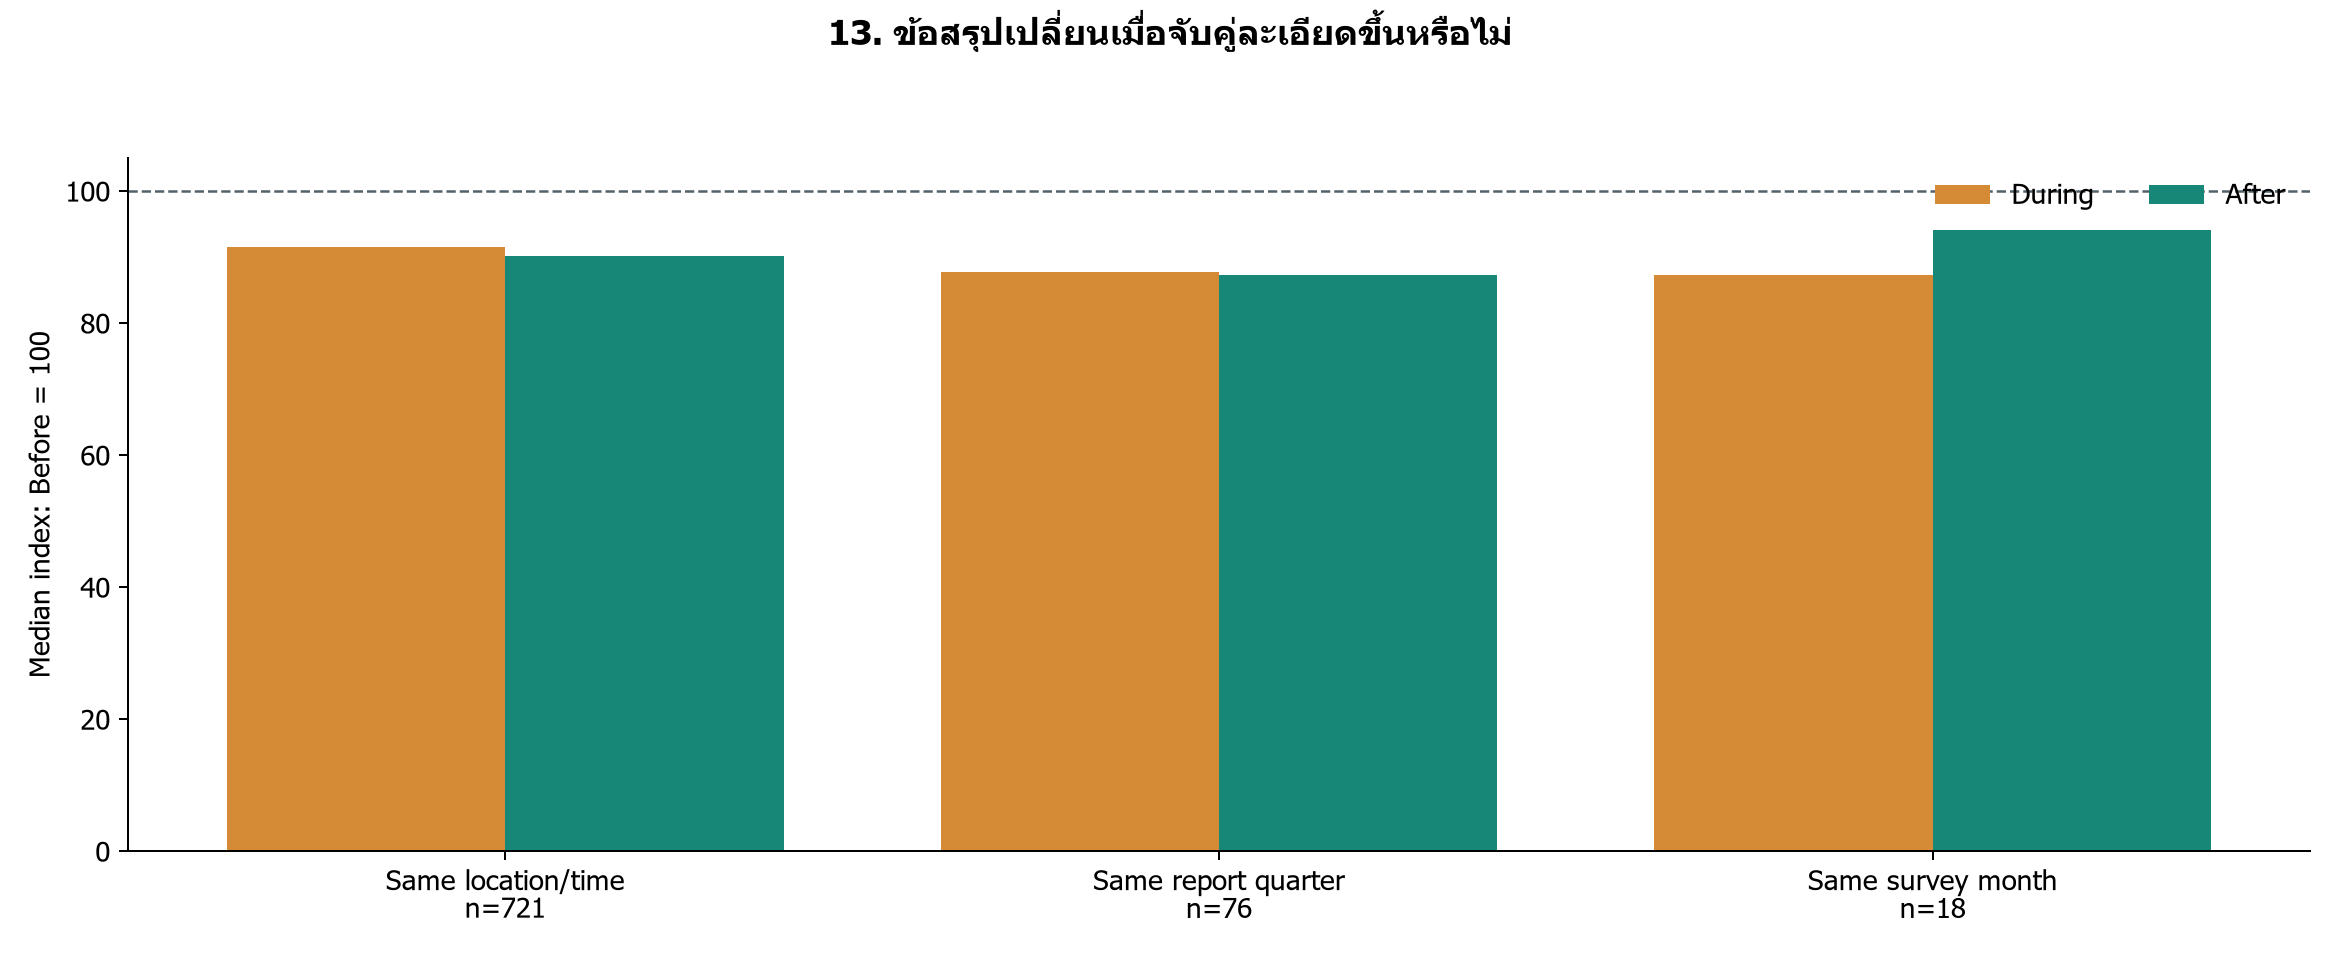

**วิธีอ่าน:** เพิ่มเงื่อนไขไตรมาสรายงานหรือเดือนสำรวจ โดยสร้างกลุ่มจับคู่ใหม่ในแต่ละวิธี

**หลักฐาน:** n=721: During 91.5, After 90.2; n=76: During 87.7, After 87.3; n=18: During 87.3, After 94.1

**ข้อจำกัด:** ขนาดและสมาชิกเปลี่ยน จึงแยกผลของการคุมปฏิทินออกจากการเปลี่ยนตัวอย่างไม่ได้

**แนวพูด:** ทุกวิธีในรอบนี้ต่ำกว่าฐาน Before แต่ After เทียบ During ไม่ได้เรียงเหมือนกันทุกวิธี จึงไม่ควรสรุปเส้นทางการฟื้นจากค่ากลางวิธีเดียว

**นำไปใช้:** รายงานผลหลักพร้อมความไว และวางแผนเก็บจุดเดิมเดือนเดิม

## 14. วันสำรวจของกลุ่มจับคู่เหมือนกันหรือไม่

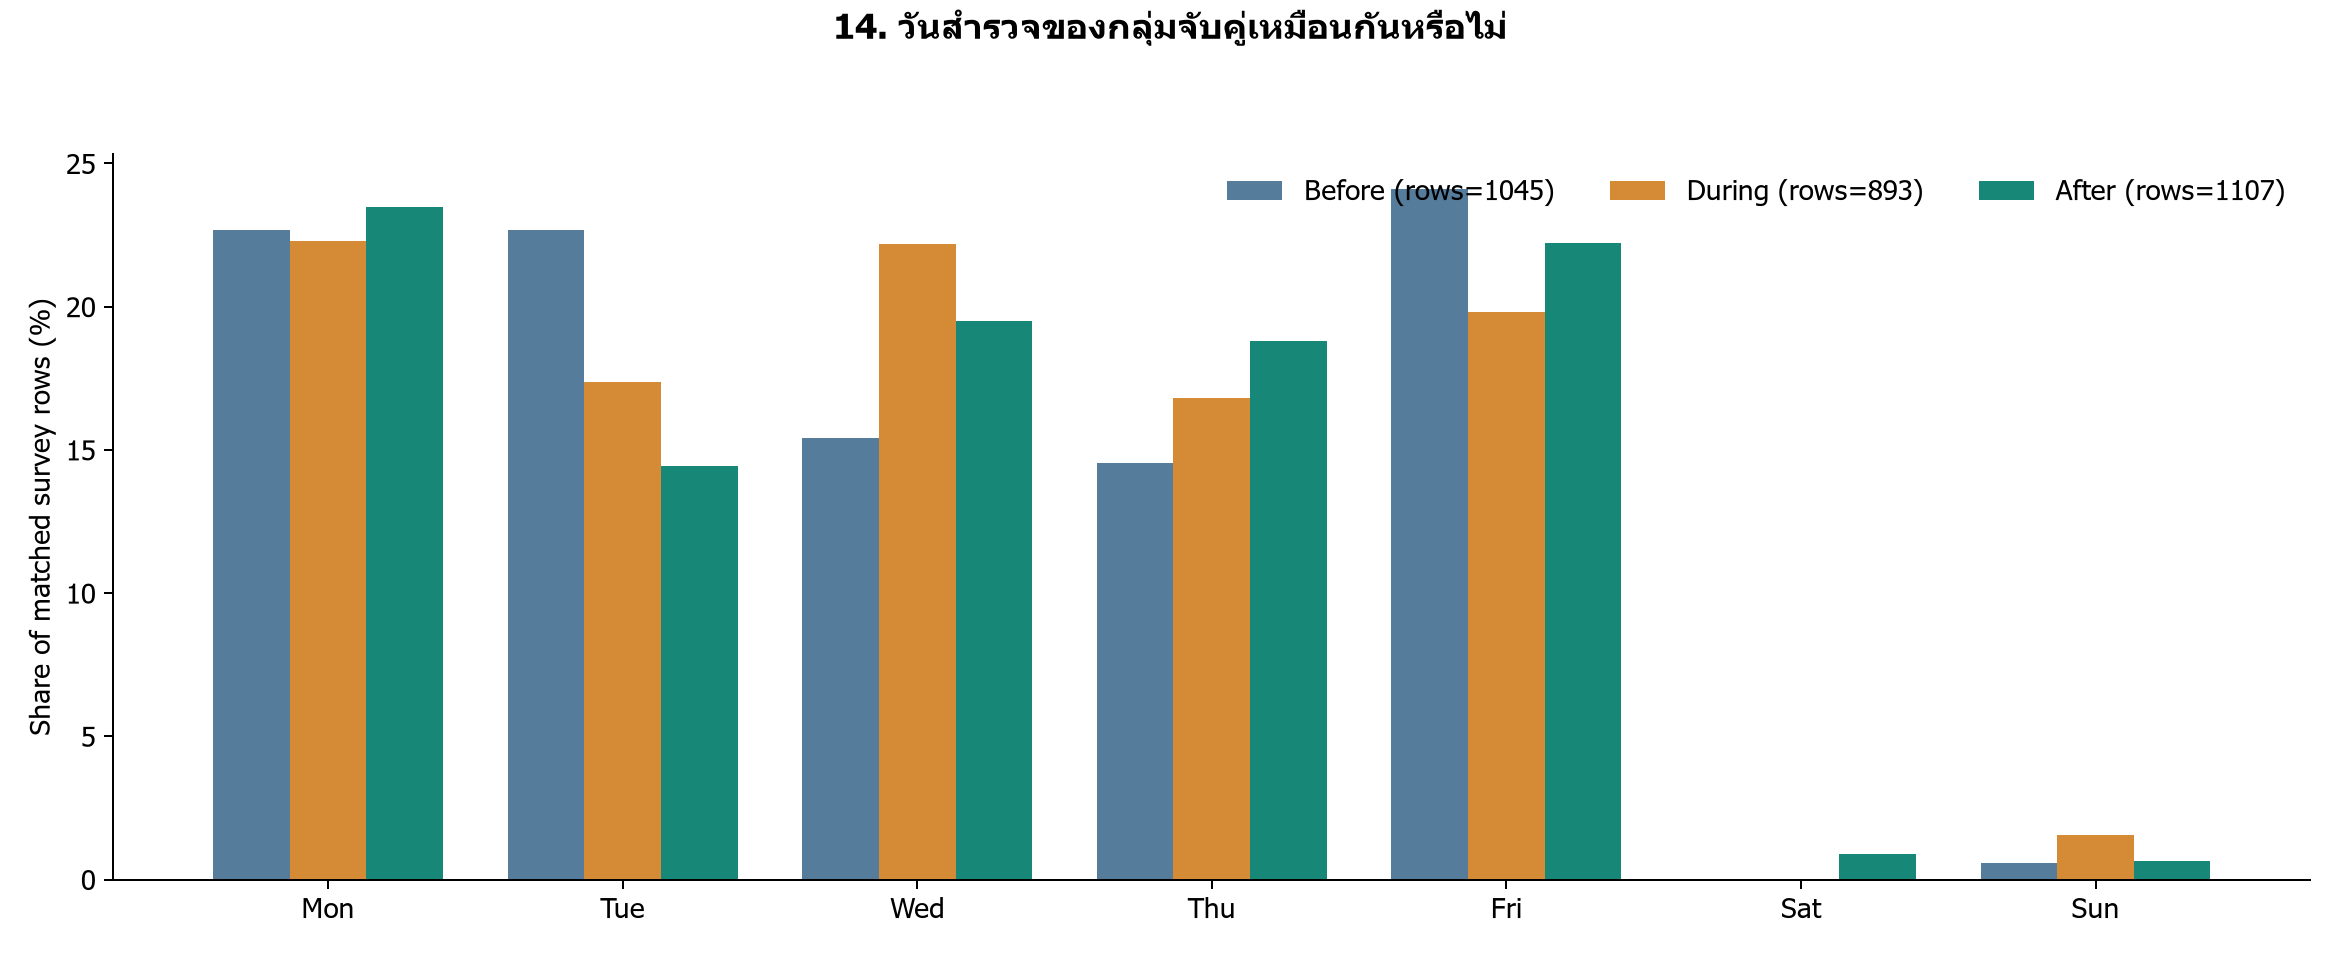

**วิธีอ่าน:** สัดส่วนแถวสำรวจตามวันในสัปดาห์ ไม่ใช่สัดส่วนจำนวนรถ; ชุดหลักเดียวกับกราฟภาพรวม

**หลักฐาน:** ใช้ 3,045 แถวที่อยู่ใน 721 หน่วยจับคู่

**ข้อจำกัด:** หลายแถวอาจเป็นวันเดียวกันหรือแยกเดียวกัน; ไม่ได้ตรวจวันหยุดและเทศกาล

**แนวพูด:** แม้จะจับคู่สถานที่และเวลาแล้ว วันที่เก็บยังต่างกันได้ กราฟนี้ไว้ตอบคำถามเรื่องปฏิทิน ไม่ใช้สรุปว่าวันใดรถมาก

**นำไปใช้:** หากเพิ่มข้อมูลวันหยุด ให้จับคู่ประเภทวันเพิ่มและตรวจจำนวนหน่วยที่เหลือ

In [6]:
for g in report["graphs"]:
    display(Markdown(f"## {g['number']:02d}. {g['title']}"))
    display(Image(filename=str(RESULT / "figures" / g["image"])))
    display(Markdown("**วิธีอ่าน:** " + g["read"] + "\n\n**หลักฐาน:** " + g["finding"] + "\n\n**ข้อจำกัด:** " + g["limit"] + "\n\n**แนวพูด:** " + g["speech"] + "\n\n**นำไปใช้:** " + g["action"]))

## 5. ดาวน์โหลดผล

ZIP ประกอบด้วย HTML สไลด์ บทพูด Read.md กราฟ PNG และตาราง CSV จาก Raw Data รอบนี้ PPTX/PDF ในชุดส่งมอบเป็น snapshot ของไฟล์ (5).xlsx หากเปลี่ยน raw ให้ใช้ HTML/กราฟที่สร้างใหม่ และอัปเดต PPTX/PDF ตามผลรอบใหม่

In [7]:
import shutil
ZIP = Path(shutil.make_archive(str(WORK / "Traffic_ReView_V5_Result"), "zip", RESULT))
print("เปิดนำเสนอ:", RESULT / "Presentation.html")
print("คำอธิบาย:", RESULT / "Read.md")
print("บทพูด:", RESULT / "Speaker_Notes.md")
print("ZIP:", ZIP)
if "google.colab" in sys.modules:
    files.download(str(ZIP))

เปิดนำเสนอ: C:\Users\AphatsaraKhangkhet(C\OneDrive - buzzebees.com\Documents\CAKE\DADS10\5001\dads5001-bangkok-traffic-mini-project\tmp\traffic_v5_build\notebook_test\traffic_v5_20260919T114629_220425Z\runs\20260919T114729_068946Z_9f3bbdb744\Presentation.html
คำอธิบาย: C:\Users\AphatsaraKhangkhet(C\OneDrive - buzzebees.com\Documents\CAKE\DADS10\5001\dads5001-bangkok-traffic-mini-project\tmp\traffic_v5_build\notebook_test\traffic_v5_20260919T114629_220425Z\runs\20260919T114729_068946Z_9f3bbdb744\Read.md
บทพูด: C:\Users\AphatsaraKhangkhet(C\OneDrive - buzzebees.com\Documents\CAKE\DADS10\5001\dads5001-bangkok-traffic-mini-project\tmp\traffic_v5_build\notebook_test\traffic_v5_20260919T114629_220425Z\runs\20260919T114729_068946Z_9f3bbdb744\Speaker_Notes.md
ZIP: C:\Users\AphatsaraKhangkhet(C\OneDrive - buzzebees.com\Documents\CAKE\DADS10\5001\dads5001-bangkok-traffic-mini-project\tmp\traffic_v5_build\notebook_test\traffic_v5_20260919T114629_220425Z\Traffic_ReView_V5_Result.zip
